# <span style="color:rgb(213,80,0)">Proyecto</span>

# <span style="color:rgb(213,80,0)">Evaluación de las capacidades de robot Scara y diseño una tarea de seguimiento de una trayectoria</span>

# <span style="color:rgb(213,80,0)">Introducción</span>



### 1. Contexto de la Robótica Industrial y Robots SCARA

 
La robótica industrial ha sido el pilar fundamental en la evolución de las líneas de producción automatizadas. Desde la introducción de los primeros manipuladores hidráulicos dedicados a tareas repetitivas y pesadas, la industria ha buscado constantemente mejorar tres factores críticos: la velocidad, la repetibilidad y la eficiencia en el uso del espacio de trabajo. Con el paso de las décadas, la evolución de los motores eléctricos y los sistemas de control digital permitieron transicionar de brazos robustos y lentos hacia arquitecturas mecánicas especializadas para tareas de alta dinámica.


    
El acrónimo **SCARA** proviene de *Selective Compliance Assembly Robot Arm*, cuya traducción al español define a un brazo robótico de montaje con elasticidad selectiva. Esta arquitectura morfológica dispone comúnmente de tres o cuatro grados de libertad orientados al posicionamiento en el plano horizontal. De acuerdo con la literatura de diseño estructural [5], estos sistemas destacan en la industria manufacturera debido a sus veloces ciclos de trabajo, una excelente capacidad de repetibilidad posicional y una alta eficiencia en tareas de manipulación de objetos denominadas *pick and place*. Mecánicamente, su configuración emula la anatomía de un brazo humano: los dos primeros ejes rotativos controlan el alcance bidimensional en el plano coordenado, mientras que el tercer eje añade un desplazamiento vertical para la elevación de la carga, consolidando la topología ideal utilizada en este proyecto.

   
En este panorama de optimización industrial, los robots SCARA (Selective Compliance Assembly Robot Arm) marcaron un hito desde su concepción en la década de 1980. Diseñados específicamente con una configuración de articulaciones rotativas paralelas que les otorgan flexibilidad o complacencia en el plano horizontal, pero una rigidez total en el eje vertical, estos manipuladores se convirtieron en la solución ideal para aplicaciones de pick-and-place, operaciones de ensamble rápido y empaque de componentes electrónicos. Su arquitectura compacta permite que los eslabones se desplacen a velocidades lineales y angulares muy elevadas, cubriendo áreas de trabajo circulares de forma óptima y superando a los brazos articulados tradicionales en tiempos de ciclo dentro de espacios confinados.


El análisis y la selección de las **configuraciones morfológicas** constituyen el punto de partida en el diseño de cualquier sistema automatizado, ya que la disposición de las articulaciones determina la geometría de su espacio de trabajo [5]. Dentro de estas topologías mecánicas, el **robot SCARA** destaca por combinar eslabones rotativos en un plano horizontal, una morfología que optimiza las tareas de transferencia rápida y ensamble industrial [5]. Para operar eficientemente estos mecanismos, la literatura técnica enfatiza que el desarrollo debe sustentarse en el modelado de su **cinemática inversa**, formalismo matemático que traduce las coordenadas cartesianas del mundo real en las consignas angulares requeridas por cada motor, sirviendo como la base analítica obligatoria antes de implementar cualquier algoritmo de control cinemático o dinámico en el hardware [5].


### 2. El Desafío de la Planificación de Trayectorias


El análisis cinemático de un sistema robótico constituye el estudio formal de su movimiento en términos de posición, velocidad y aceleración, prescindiendo de las fuerzas y torques que originan dicha transición física [5]. Este análisis se bifurca en dos metodologías fundamentales y opuestas: la cinemática directa y la cinemática inversa. Por un lado, la cinemática directa se define como un problema geométrico estático encargado de determinar las coordenadas espaciales y la orientación del efector final a partir de los parámetros geométricos del robot y los valores angulares o lineales conocidos de sus articulaciones; en una cadena cinemática abierta, esta solución es siempre única y unívoca [5]. Por otro lado, la cinemática inversa invierte el flujo algebraico, convirtiéndose en la herramienta analítica esencial para calcular las consignas articulares necesarias que forzarán al robot a alcanzar una pose cartesiana deseada en su entorno de trabajo, siendo este último el núcleo algorítmico implementado de forma continua en este proyecto.


    
El problema de la cinemática inversa radica en encontrar de manera exacta los valores específicos que deben adoptar las coordenadas articulares generalizadas del robot $(\theta_1, \theta_2, \dots, \theta_n)$ con el propósito de posicionar y orientar el efector final en una ubicación espacial determinada. A diferencia del enfoque directo, la resolución de la cinemática inversa presenta una alta complejidad analítica, debido a que exige resolver un sistema de ecuaciones fuertemente no lineales acopladas que dependen directamente de la morfología del manipulador. Adicionalmente, una característica fundamental de este formalismo es la existencia de múltiples soluciones válidas para alcanzar un mismo punto cartesiano; estas configuraciones alternativas, conocidas popularmente como posturas de codo o modos de ensamblaje, dependen intrínsecamente de la colocación y de las restricciones físicas que adquieran los eslabones, lo que obliga al sistema de control a discriminar y seleccionar la postura más adecuada para el seguimiento de la trayectoria.


La resolución de la cinemática inversa de un manipulador requiere discriminar explícitamente entre múltiples soluciones matemáticas, tal como ocurre en la articulación del codo de una estructura coplanar, donde existen dos configuraciones válidas que obligan al controlador a determinar a priori la postura física que adoptará el robot. Para abordar este problema analítico, la literatura técnica destaca tres metodologías fundamentales: **el método geométrico**, **la inversión analítica mediante matrices de transformación homogénea** y el **desacoplamiento cinemático** [5]. El método geométrico se fundamenta en la aplicación de razones trigonométricas sobre los triángulos formados por los eslabones, resultando ideal para cadenas cinemáticas con pocos grados de libertad o para simplificar las primeras juntas de posicionamiento. Por otro lado, el despeje algebraico a partir del modelo directo expresado en matrices homogéneas suele descartarse en la práctica debido a su extrema complejidad y naturaleza no trivial. Finalmente, el desacoplamiento cinemático permite aislar las juntas principales dedicadas al posicionamiento espacial de aquellas encargadas estrictamente de la orientación del efector final, un principio analítico que rige el desacoplamiento de la muñeca implementado de forma iterativa en este proyecto.

El control cinemático tiene como objetivo primordial definir los caminos temporales que cada una de las articulaciones del robot debe seguir de forma coordinada para alcanzar las consignas operacionales impuestas por el usuario, tales como el punto de destino cartesiano, el tiempo de ejecución de la tarea y el perfil geométrico del extremo [5]. Durante el diseño de este esquema de control, es imperativo evaluar minuciosamente las limitaciones físicas intrínsecas del manipulador, asegurando el cumplimiento de los estándares de calidad en el movimiento. Metodológicamente, este proceso consiste en describir la trayectoria deseada a partir de una sucesión continua de puntos orientados en el espacio de trabajo; posteriormente, el sistema de control ejecuta un algoritmo de interpolación numérica recurriendo al uso de funciones polinómicas, lo que permite generar y muestrear de manera exacta la serie de estados posicionales intermedios a lo largo de la escala del tiempo [5].


Las estrategias de control cinemático para manipuladores industriales se clasifican principalmente en tres categorías de perfiles de movimiento, destacando en primera instancia **las trayectorias punto a punto**. En este esquema operacional, cada articulación del robot se desplaza de manera totalmente independiente de las influencias mecánicas o geométricas de los demás eslabones de la cadena. Dentro de este mismo dominio articular, la literatura técnica distingue subcategorías como el **movimiento eje a eje** y el **movimiento axial síncrono**. Mientras que en el *esquema eje a eje* las articulaciones se activan de forma secuencial —incrementando de manera ineficiente el tiempo total de ciclo de la tarea—, el *movimiento axial síncrono* fuerza a todos los ejes a iniciar su desplazamiento simultáneamente, condicionando la velocidad del sistema para que todas las juntas concluyan su trayectoria de forma emparejada en el instante exacto en que el motor más lento finalice su recorrido. Esta última aproximación síncrona, acoplada a polinomios de interpolación, es la que rige el comportamiento del nodo desarrollado, optimizando los tiempos de tránsito mecánico en comparación con los esquemas de control punto a punto tradicionales [5].


Una segunda categoría fundamental corresponde a las **trayectorias coordinadas o isócronas**. En este esquema de planificación, el movimiento de todos los actuadores del manipulador se encuentra acoplado bajo una misma sincronización temporal, lo que implica que la articulación con el requerimiento cinemático más demandante condiciona la velocidad de los ejes restantes; de este modo, se ralentiza proporcionalmente el avance de cada junta para asegurar que ninguna de ellas finalice de forma prematura y que todas alcancen sus posiciones de destino de manera simultánea. Este enfoque optimiza el tiempo total invertido en la tarea, reduciendo drásticamente las aceleraciones y velocidades pico demandadas en comparación con otros esquemas desorganizados. No obstante, la literatura técnica destaca que la principal desventaja de un planificador isócrono radica en la pérdida de control geométrico operacional, ya que no es posible conocer ni predecir analíticamente a priori la trayectoria espacial exacta que describirá el punto extremo del robot a lo largo del recorrido.

    
La tercera categoría fundamental corresponde a las **trayectorias continuas**. En este tipo de planificación, la prioridad absoluta radica en conocer y controlar de antemano el recorrido geométrico exacto que describirá el punto extremo del robot en el espacio operacional. Para lograr esta fidelidad geométrica, las funciones de movimiento de todas las articulaciones deben calcularse de manera interdependiente y estar perfectamente alineadas entre sí paso a paso. Aunque el perfil temporal de cada articulación de forma individual pueda exhibir un comportamiento asimétrico u ondulatorio —lo que a nivel articular simula un movimiento desorganizado—, el resultado coordinado global fuerza al efector final a desplazarse con total precisión a lo largo de la ruta espacial previamente planificada. Este comportamiento no lineal en las juntas es característico del control cartesiano mediante el inverso del Jacobiano implementado en este estudio, permitiendo un guiado continuo indispensable para tareas de alta exigencia geométrica.

    
La planificación de trayectorias constituye uno de los pilares más complejos en el control de manipuladores robóticos modernos. Existe una diferencia fundamental entre un desplazamiento punto a punto básico, ejecutado mediante consignas abruptas de posición que exigen perfiles de velocidad en forma de escalón, y un movimiento inteligente condicionado temporalmente. Cuando un robot se desplaza sin una planificación de perfiles suaves, los actuadores experimentan demandas mecánicas extremas debido a discontinuidades analíticas severas y picos de aceleración infinitos, induciendo el fenómeno del *jerk* (tirón mecánico brusco); este comportamiento genera vibraciones estructurales nocivas, sobrecalentamiento por sobrecorriente en los devanados de los motores y una pérdida inmediata de la precisión en la tarea operacional. Para contrarrestar estos efectos adversos, la ingeniería de control recurre a la parametrización matemática del movimiento mediante perfiles continuos de interpolación, destacando el uso de polinomios de quinto orden. La selección de este tipo de funciones curvas garantiza de forma analítica que variables físicas críticas como la velocidad y la aceleración mantengan un comportamiento suave y progresivo, iniciando y finalizando estrictamente en cero en las fronteras cronológicas de la tarea. Al asegurar que las derivadas sucesivas de la posición sean continuas en todo momento, se minimiza de forma contundente el desgaste físico de los reductores mecánicos, se eliminan las oscilaciones residuales en el destino y se maximiza la precisión geométrica del efector final, permitiendo que el hardware opere de manera eficiente dentro de sus límites nominales de diseño.

### 3. El Espacio Articular vs. El Espacio de Trabajo



Para gobernar el movimiento preciso de un manipulador, es un requerimiento técnico indispensable generar de forma previa la trayectoria en el espacio operacional o intrínseco que el mecanismo deberá ejecutar. Estas estrategias se clasifican fundamentalmente en dos metodologías: **la generación en el espacio articular** y **la generación en el espacio cartesiano** [5]. 

La planificación articular se orienta a desplazar el brazo desde una coordenada inicial hacia una final en un intervalo de tiempo estrictamente determinado, sin condicionar la geometría concreta del camino recorrido por el efector final. 

Por el contrario, la planificación cartesiana se implementa cuando la tarea exige un control geométrico estricto del trayecto físico (como un guiado lineal o trayectorias de soldadura). Metodológicamente, para estructurar este perfil cinemático, se evalúa primero la ecuación cartesiana de la ruta a partir de las especificaciones de movimiento, para luego muestrear y discretizar algebraicamente dichos puntos espaciales a lo largo del tiempo. Finalmente, estas coordenadas cartesianas discretas se transforman en variables articulares equivalentes mediante el modelo cinemático inverso, permitiendo interpolar y reconstruir de forma continua los perfiles de posición, velocidad y aceleración requeridos por los actuadores para completar la tarea con fluidez.

    
Suponiendo que la ruta del manipulador se define originalmente en el espacio cartesiano, la literatura técnica establece dos alternativas fundamentales para su descripción y control. La primera consiste en ubicar los lazos de regulación directamente en el dominio cartesiano, cancelando el error posicional en dicho espacio operacional; una técnica comúnmente difundida en robótica móvil donde la curvatura del trayecto se vincula de forma directa con las variables de estado del sistema. La segunda alternativa consiste en mapear la ruta cartesiana hacia el espacio articular correspondiente a través del modelo cinemático inverso, permitiendo controlar de manera independiente la progresión temporal de cada variable intrínseca mediante bucles de regulación locales. Dado que el problema del planificador de trayectorias debe resolverse en tiempo real, es un imperativo de diseño que la generación orbital sea computacionalmente eficiente para no comprometer el determinismo del sistema. Bajo este enfoque, la interpolación de trayectorias se define como el cálculo continuo de un conjunto sucesivo de puntos en el espacio articular por los que deben transitar las juntas en un periodo dado. Para su determinación analítica, se emplean diferentes funciones polinómicas que abarcan desde *interpoladores lineales, cuadráticos y cúbicos (*splines*), hasta polinomios quínticos y esquemas por tramos*, siendo la formulación de quinto orden la seleccionada en este estudio para asegurar la continuidad en los perfiles de velocidad y aceleración del mecanismo.

Una de las aproximaciones fundamentales en la planificación de movimientos es el uso del **interpolador lineal**. Este método consiste en mantener una velocidad de movimiento constante entre cada par de valores sucesivos $(q_{i-1}, q_i)$ de la articulación, modelando la evolución temporal de la variable articular mediante una ecuación de primer grado en función del diferencial de tiempo ($dt$) y el período de muestreo ($T$), dada por $q(t) = \frac{q_i - q_{i-1}}{T} \cdot dt + q_{i-1} = V_q \cdot dt + q_{i-1}$ [5]. Para aproximar una velocidad constante en la práctica, la literatura técnica establece criterios de optimización temporal que buscan desplazar cada articulación hacia su destino de la forma más rápida y distante posible, ajustando de manera adaptativa los tiempos de transición para lograr un movimiento coordinado en el espacio de tareas. No obstante, a pesar de su simplicidad de cálculo y eficiencia en el seguimiento de rutas predefinidas, el interpolador lineal introduce discontinuidades abruptas en los perfiles de velocidad al inicio y al final de cada tramo; estas variaciones instantáneas demandan aceleraciones teóricas infinitas (perfiles en forma de impulso), lo que descarta su implementación en este proyecto y justifica la adopción de polinomios de orden superior para preservar la integridad dinámica del manipulador SCARA.


Como una alternativa superior para la generación de curvas suaves, la literatura técnica destaca el uso de **interpoladores cúbicos o splines**. Esta metodología se fundamenta en la aproximación parcial por polinomios de tercer grado para conectar cada par de puntos sucesivos a lo largo de un intervalo temporal dado por $T = (t - t^{i-1})$, modelando la posición mediante la función analítica $q(t) = a + b \cdot (t - t^{i-1}) + c \cdot (t - t^{i-1})^2 + d \cdot (t - t^{i-1})^3$. La ventaja del polinomio cúbico radica en su capacidad para suprimir oscilaciones no deseadas en la trayectoria mediante el uso de ecuaciones de bajo orden, asegurando además el cumplimiento de cuatro condiciones límite fundamentales a partir de cuatro coeficientes libres: dos posiciones extremas y dos velocidades de frontera. Analíticamente, los parámetros constantes de posición inicial y velocidad de arranque se asocian de forma directa a las fronteras previas mediante $a = q_{i-1}$ y $b = \dot{q}_{i-1}$, mientras que las componentes de aceleración y cambio dinámico dependientes de los coeficientes $c$ y $d$ se resuelven mediante el despeje algebraico de las condiciones finales del tramo. No obstante, a pesar de garantizar la continuidad en la velocidad, el interpolador cúbico genera discontinuidades de tipo escalón en el perfil de aceleraciones al transicionar entre segmentos contiguos, lo que induce impactos dinámicos e introduce la necesidad de recurrir a polinomios de quinto grado para asegurar un movimiento completamente armónico.


Como solución definitiva para la planificación de movimientos de alta suavidad, la literatura técnica introduce el uso de **interpoladores quínticos**. Al igual que el esquema cúbico, este tipo de interpolación garantiza que la ruta que conecta los puntos por los que debe transitar la articulación muestre una continuidad estricta en el perfil de velocidades. No obstante, la ventaja fundamental de un polinomio de quinto grado radica en su capacidad para asegurar también la continuidad analítica en el perfil de aceleraciones, modelando la trayectoria mediante la función extendida $q(t) = a + b \cdot (t - t^{i-1}) + c \cdot (t - t^{i-1})^2 + d \cdot (t - t^{i-1})^3 + e \cdot (t - t^{i-1})^4 + f \cdot (t - t^{i-1})^5$. Esta formulación de orden superior permite satisfacer seis condiciones de frontera independientes a partir de sus seis coeficientes libres, acoplando de forma exacta dos posiciones, dos velocidades y dos aceleraciones extremas. Al suprimir por completo los saltos bruscos en las derivadas sucesivas de la posición, se eliminan los picos infinitos de esfuerzo motor, dando como resultado una trayectoria dinámicamente armónica y mecánicamente viable que se puede lograr e implementar con total seguridad en un robot real o en entornos de simulación física restrictivos [5].

    
El diseño de algoritmos de control robótico plantea un dilema fundamental para el ingeniero al seleccionar el dominio en el que se planificará el movimiento: el espacio articular o el espacio de trabajo. La planeación en el espacio articular define el comportamiento temporal directamente sobre las coordenadas intrínsecas de los motores, lo que elimina la necesidad de resolver ecuaciones trigonométricas inversas complejas de manera iterativa dentro del bucle de control principal. Aunque este enfoque es computacionalmente eficiente y garantiza perfiles de velocidad suaves y predecibles en los actuadores, presenta la severa limitación de no linealidad en el espacio físico; debido a esto, la trayectoria geométrica descrita por el efector final en el mundo real se vuelve arqueada e impredecible, restringiendo su viabilidad en entornos con alta densidad de obstáculos o tareas de precisión espacial. Por el contrario, la planeación en el espacio de trabajo opera en el dominio operacional cartesiano, forzando a la punta del robot a describir trayectorias geométricas estrictas, como líneas rectas perfectas indispensables para tareas de ensamble o soldadura. No obstante, este control cartesiano impone una carga computacional masiva al procesador debido a la resolución continua de la cinemática inversa en tiempo real y expone al manipulador al riesgo crítico de singularidades cinemáticas, zonas geométricas donde el Jacobiano colapsa y exige a los servomotores velocidades angulares físicamente imposibles.


### 4. La Importancia de la Cinemática Diferencial y la Dinámica

    
En el desarrollo de sistemas robóticos de alta precisión, el modelado de la posición representa únicamente el primer eslabón del análisis, siendo indispensable extender el estudio hacia los dominios de la cinemática diferencial y la dinámica inversa. La cinemática diferencial, gobernada por la matriz Jacobiana geométrica, modela la transferencia lineal entre las velocidades angulares de los motores y las velocidades lineales y de orientación del efector final en el espacio operacional. El monitoreo analítico de este comportamiento diferencial, complementado con el cálculo de métricas de destreza como el Índice de Manipulabilidad de Yoshikawa, resulta vital para evaluar cuantitativamente la proximidad del manipulador a singularidades cinemáticas; estas zonas críticas reducen la movilidad del robot y disparan matemáticamente las demandas de velocidad en los actuadores, amenazando la estabilidad numérica del controlador. Asimismo, la validación del sistema físico requiere la formulación del modelo dinámico inverso para mapear los perfiles cinemáticos hacia los momentos torsores o torques requeridos instantáneamente por cada junta. Al resolver este acoplamiento no lineal de fuerzas inerciales, centrífugas y de Coriolis, es posible deducir el perfil de potencia mecánica instantánea absorbida en Watts, un indicador de alta prioridad para optimizar la eficiencia energética de la tarea, evitar fenómenos de resonancia estructural y asegurar que el hardware opere holgadamente por debajo de sus límites nominales de disipación térmica.


### 5. Herramientas Modernas de Desarrollo: MATLAB y ROS 2


    
La validación integral de un sistema robótico demanda una transición metodológica fluida que va desde el modelado matemático analítico hasta la implementación en entornos de ejecución física en tiempo real. En la ingeniería moderna, esta brecha se mitiga mediante el uso sinérgico de entornos de computación numérica como **MATLAB** y middleware de programación distribuida como **ROS 2 (Robot Operating System)**. MATLAB, a través de su Live Editor, provee una plataforma matemática óptima para evaluar de forma determinista la exactitud de las ecuaciones cinemáticas, simular los perfiles dinámicos de torque y potencia, y graficar métricas complejas de destreza geométrica como los elipsoides de manipulabilidad. Una vez validados estos modelos numéricos de escritorio, ROS 2 actúa como el estándar industrial para el despliegue del software de control modular, permitiendo una comunicación asíncrona, concurrente y de baja latencia mediante nodos de publicación y suscripción. Esta combinación de herramientas permite que las matrices de control calculadas en una etapa teórica sean transferidas hacia un entorno con restricciones de tiempo y hardware real, garantizando que el manipulador SCARA ejecute las trayectorias interpoladas con alta fidelidad y reactividad ante los comandos del simulador físico o del entorno real.

    
Por lo tanto, este trabajo aborda el diseño y validación de una trayectoria diagonal para un manipulador SCARA de 3 GDL. El análisis se extiende desde la simulación analítica de perfiles cinemáticos, dinámicos y de destreza en MATLAB, hasta su implementación como un nodo de control distribuido en ROS 2. Con esto, se busca establecer un criterio de viabilidad operativa que equilibre la precisión geométrica con los límites físicos del hardware del robot.


## Justificación Técnica
<p style="text-align: justify;">
El desarrollo de este proyecto se justifica por la necesidad de evaluar el comportamiento cinemático y dinámico de un robot manipulador SCARA de 3 GDL antes de su puesta en marcha en un entorno físico o de simulación. Diseñar y validar algoritmos a nivel de software permite predecir el rendimiento del brazo, evitar colisiones mecánicas y optimizar el uso de los recursos del sistema.
</p>

**Integración y Despliegue en el Ecosistema ROS 2:** La conversión del modelo digital desde archivos CAD hacia un formato de descripción de robots unificado (*URDF - Unified Robot Description Format*) se justifica como el puente fundamental para la automatización industrial moderna. Este enfoque permite transferir con precisión milimétrica las propiedades de masa, centros de gravedad y mallas virtuales desde el diseño de ingeniería hacia entornos avanzados de ROS 2. De este modo, se facilita la visualización en tiempo real del estado de los sensores y articulaciones mediante **RViz**, y se valida la respuesta física ante la gravedad y colisiones en entornos virtuales como **Gazebo**, garantizando una transición robusta y segura hacia el hardware comercial real.


<p style="text-align: justify;">
    
**Control de Movimiento Suave:** La implementación de un polinomio de interpolación de quinto orden se justifica porque permite imponer restricciones analíticas de velocidad y aceleración nulas en los extremos de la tarea. Esto elimina los tirones bruscos (*jerk*) en el arranque y el frenado, protegiendo la estructura del robot y reduciendo el desgaste de los actuadores.

</p>

<p style="text-align: justify;">
    
**Análisis del Espacio Operacional:** Comparar la planeación en el espacio articular contra el espacio de trabajo se justifica para entender el costo de la precisión geométrica. Mientras que el control articular ofrece simplicidad computacional, el control cartesiano es indispensable para tareas que exigen líneas rectas perfectas; sin embargo, este último requiere ser evaluado previamente para detectar si las demandas angulares sobrepasan los límites físicos de hardware (*joint limits*) de los motores.

</p>

<p style="text-align: justify;">
    
**Seguridad Cinemática:** El cálculo del Índice de Manipulabilidad de Yoshikawa ($w$) se justifica como una métrica de monitoreo continuo para medir la destreza del manipulador. Este análisis matemático es crucial para asegurar que la trayectoria programada mantenga al robot alejado de singularidades cinemáticas, zonas críticas donde la matriz Jacobiana inversa colapsa y exige velocidades teóricamente infinitas a los motores.

</p>

<p style="text-align: justify;">
    
**Dimensionamiento Energético:** La resolución de la dinámica inversa mediante variables auxiliares se justifica para estimar las fuerzas y momentos torsores reales que experimentará el mecanismo debido a la velocidad e inercia de sus eslabones. Obtener estos perfiles de torque y potencia mecánica instantánea permite dimensionar correctamente las fuentes de alimentación eléctrica y seleccionar los servomotores adecuados para la tarea.

</p>

## Objetivo del Reporte

<p style="text-align: justify;">
    
Evaluar las capacidades cinemáticas, dinámicas y operacionales de un robot manipulador SCARA de 3 GDL mediante el análisis del Índice de Manipulabilidad de Yoshikawa y perfiles de potencia mecánica instantánea, con el fin de determinar la viabilidad física, límites de torque y eficiencia energética de los actuadores durante el seguimiento de una trayectoria programada.

</p>

    
## Hipótesis

<p style="text-align: justify;">
    
Es posible caracterizar cuantitativamente el comportamiento estructural de un manipulador robótico y validar de forma analítica su aptitud para cumplir con tareas de seguimiento de trayectoria, correlacionando el elipsoide de destreza de la matriz Jacobiana con las demandas de torque e interacción inercial de sus eslabones en el tiempo.

</p>

## Vinculación con la Clase

<p style="text-align: justify;">
    
El desarrollo de este proyecto constituye un puente directo entre los fundamentos teóricos de la asignatura y la implementación práctica en ingeniería. A través de la experimentación numérica en MATLAB y la simulación en ROS 2, se consolidan y validan físicamente los núcleos temáticos del plan de estudios.

</p>  

#### Modelado CAD e Integración de Sistemas Virtuales en ROS 2

* **Fundamento Teórico:** Restricciones de ensamblaje mecánico, extracción de matrices de inercia, cinemática de cuerpos rígidos y estructura XML para descripción de robots.

* **Implementación:** Exportación del diseño geométrico y físico desde archivos CAD para la generación de archivos **URDF**. Este modelo unificado permite validar los algoritmos de control dentro del ecosistema de ROS 2, simulando la física y colisiones reales en **Gazebo** y visualizando la telemetría articular en **RViz**.


<p style="text-align: justify;">
    
#### Cinemática Directa e Inversa de Manipuladores
* **Fundamento Teórico:** Métodos geométricos de resolución, desacoplamiento cinemático de la herramienta y selección de configuraciones estructurales (*codo arriba/codo abajo*).
* **Implementación:** Resolución analítica de la cinemática inversa del robot SCARA, logrando mapear coordenadas del espacio de trabajo hacia el espacio articular de forma determinista.
  
</p>

#### Cinemática Diferencial y Análisis de Destreza

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Formulación de la matriz Jacobiana geométrica, mapeo diferencial de velocidades operacionales y singularidades de frontera.
* **Implementación:** Construcción e inversión de la matriz Jacobiana para el cálculo de velocidades, evaluando la pérdida de destreza mediante el **Índice de Manipulabilidad de Yoshikawa ($w$)**.
  
</p>

    
#### Planificación y Generación de Trayectorias

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Polinomios de interpolación, condiciones de frontera dinámicas y supresión del tirón mecánico (*jerk*).
* **Implementación:** Aplicación de un **polinomio de quinto orden** en MATLAB y Python, comprobando cómo las restricciones de velocidad y aceleración nulas en los extremos eliminan impactos destructivos sobre los actuadores.
  
    </p>
    
#### Modelado Dinámico Avanzado

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Formulación de ecuaciones de movimiento mediante Euler-Lagrange, matrices de inercia acoplada, fuerzas de Coriolis y efectos centrífugos.
* **Implementación:** Programación de variables auxiliares ($\sigma$) para resolver la **dinámica inversa**, transformando perfiles cinemáticos en curvas de torque ($\tau$) y potencia mecánica instantánea ($P$).
  

#### Arquitectura de Software para Robots (ROS 2)

<p style="text-align: justify;">
    
* **Fundamento Teórico:** Sistemas distribuidos, comunicación asíncrona basada en eventos, nodos, publicadores y concurrencia.
* **Implementación:** Traducción de las ecuaciones en un nodo controlador asíncrono, sustituyendo bucles bloqueantes por temporizadores nativos para garantizar la estabilidad de la comunicación del robot.
 
</p>

## Metas:

•Proponer el lugar geométrico de una trayectoria que debe realizar el robot.

•Evaluar las capacidades cinemáticas del robot de manera cualitativa mediante el índice de manipulabilidad.

•Determinar la velocidad y el par que deben cubrir los motores.

•Estimar la potencial mecánica requerida por cada motor y la potencial total requerida por el robot.

**El proyecto debe contar con los siguientes elementos:**

*Reporte del proyecto.* (50puntos)

*Repositorio con los archivos del proyecto* (link de GitHub) (25 puntos)

*Evidencias de funcionamiento del proyecto* (simulación) (25 puntos)

*Evidencias del funcionamiento de los elementos correspondientes del proyecto.* 

#### El reporte debe tener los siguientes elementos:

*•Introducción*

*•Desarrollo* (planteamiento de las ecuaciones)

*•Resultados* (gráficas, vídeos, etc.)

*•Conclusiones* (individuales, límite del equipo de 4 personas).

**Este proyecto demuestra que los alumnos cuenta con los siguientes elementos del perfil de egreso:**

• Sólida formación en física y matemáticas.

• Conocimientos de amplio espectro en las distintas ramas que integran a la mecatrónica, lo que le permitirá al egresado participar con éxito y adaptarse a los cambios de las tecnologías en este campo y, en su caso, generarlos.

• Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.

• Para integrar y coordinar personas y grupos interdisciplinarios.

*De tipo profesional:*

• Ser creativo e innovador.

• Tener confianza en su preparación académica.

• Tener una mente abierta orientada hacia la solución de problemas de ingeniería.

• Ser honesto, responsable y crítico.

• Comprometido con su actualización, superación y competencia profesional.


*De tipo social:*

• Tener conciencia de la problemática nacional basada en el conocimiento de la realidad del país y su interrelación con el mundo globalizado, con una actitud humanista y de servicio hacia la sociedad.

• Mantener una ética profesional.

• Promover el cambio en la mentalidad frente a la competitividad internacional.


# <span style="color:rgb(213,80,0)">Desarrollo</span>
# <span style="color:rgb(213,80,0)">Modelado CAD</span>

### Extracción de Propiedades Físicas e Integración en ROS 2

Para el desarrollo del modelo de simulación, se utilizaron los archivos de diseño del robot **RoArm**. A través de un software de **CAD**, se realizó la extracción sistemática de las propiedades físicas críticas de cada uno de los ensambles de los eslabones, así como los parámetros globales del ensamble completo necesarios para el cálculo del modelo matemático.

### Descripción del Brazo Robótico RoArm y sus Subensambles

  ![RoArm_ensamble](imagenes_proyecto/RoArm_ensamble.png)

Imagen 1. RoArm

  ![RoArm_ensamble2](imagenes_proyecto/RoArm_ensamble2.png)

Imagen 2. RoArm 2

A partir del modelo digital en el entorno de diseño CAD (Autodesk Inventor), el brazo robótico **RoArm** (archivo de ensamble `RoArm_ensamble.iam`) se estructura de manera jerárquica mediante una serie de eslabones y subensambles interconectados en cadena cinemática. 

A continuación se detallan los componentes principales identificados en el árbol del modelo:

* **RoArm_base_link:1 (Base):** Constituye el elemento de soporte estructural rígido e inmóvil del robot, encargado de fijar toda la estructura a la superficie de trabajo o plataforma de montaje.
* **RoArm_cintura:1 (Cintura):** Primer eslabón móvil del sistema que se acopla directamente sobre la base fija, permitiendo el movimiento de rotación principal sobre el eje vertical (azimut) para orientar el brazo.
* **RoArm_brazo:1 (Brazo):** Segmento intermedio o eslabón proximal que define la primera sección de elevación del manipulador, determinando el alcance y la altura de la estructura principal.
* **RoArm_antebrazo:1 (Antebrazo):** Segmento distal articulado que extiende la longitud operativa del robot y otorga los grados de libertad necesarios para el posicionamiento espacial preciso del extremo final.
* **AL_grippe:1 (Efector Final / Pinza):** Subensamble correspondiente a la herramienta terminal o actuador (*gripper*), encargado de realizar las tareas de sujeción, manipulación e interacción directa con los objetos del entorno.

  ![propiedades_base](imagenes_proyecto/propiedades_base.png)

Imagen 3. Propiedades fisicas de RoArm_base_link:1 (Base).

  ![propiedades_cintura](imagenes_proyecto/propiedades_cintura.png)

Imagen 4. Propiedades fisicas de RoArm_cintura:1 (Cintura)


  ![propiedades_antebrazo](imagenes_proyecto/propiedades_antebrazo.png)

Imagen 5. Propiedades fisicas de RoArm_antebrazo:1 (Antebrazo)


  ![propiedades_brazo](imagenes_proyecto/propiedades_brazo.png)

Imagen 5. Propiedades fisicas de RoArm_brazo:1 (Brazo)


  ![propiedades_grippe](imagenes_proyecto/propiedades_grippe.png)

Imagen 6. Propiedades fisicas de AL_grippe:1 (Efector Final / Pinza)


  ![propiedades_ensamble_RoArm](imagenes_proyecto/propiedades_ensamble_RoArm.png)

Imagen 7. Propiedades fisicas de RoArm_ensamble


Con el objetivo de garantizar una simulación precisa y realista dentro del ecosistema **ROS 2**, se implementó el siguiente flujo de trabajo:

* **Conversión de Unidades:** Todas las propiedades mecánicas obtenidas (masas, centros de gravedad y matrices de inercia) se estandarizaron estrictamente al **Sistema Internacional de Unidades (SI)**, empleando metros, kilogramos y segundos.
* **Generación del URDF:** Estos parámetros físicos unificados se introdujeron en la estructura del archivo **URDF** (*Unified Robot Description Format*), asegurando la correcta descripción del robot sin importar la escala o magnitud de los componentes individuales.
* **Validación Virtual:** El archivo resultante permite validar de manera directa el comportamiento dinámico y la telemetría articular del brazo robótico mediante la visualización en **RViz** y la simulación física detallada ante gravedad y colisiones en **Gazebo**.




# <span style="color:rgb(213,80,0)">Evaluación de las capacidades de robot Scara</span>

## Resumen

A continuación se expone la evaluación exhaustiva de las capacidades cinemáticas, dinámicas y operacionales de un robot manipulador articulado/antropomórfico de tres grados de libertad (3 GDL) mediante simulación numérica en el entorno de MATLAB. El objetivo primordial de la investigación es planificar, validar y comparar el comportamiento del robot al ejecutar una trayectoria diagonal suave confinada estrictamente a un plano vertical, desplazándose desde una postura inicial \\(P\_{in} = (0.20, 0.10, 0)\\) hasta una posición final extrema \\(P\_{fin} = (0.32, 0.22, 0)\\) en metros.

Para garantizar transiciones de movimiento armónicas y anular los tirones mecánicos (*jerk*) en los extremos temporales \\(t = 0\\text{ s}\\) y \\(t = 10\\text{ s}\\), se implementó un perfil de parametrización temporal basado en un polinomio de interpolación de quinto orden. El análisis se abordó desde dos enfoques metodológicos complementarios:

1. Planeación en el Espacio Articular: Donde se determinaron analíticamente las posturas de frontera mediante cinemática inversa estática (configuración codo arriba) adaptada a la geometría vertical del brazo, para interpolar directamente las coordenadas de las juntas móviles de manera independiente mientras la cintura se mantiene fija en cero.
2. Planeación en el Espacio de Trabajo: Donde se forzó al efector final a describir una línea recta cartesiana perfecta en tiempo real dentro del plano vertical, resolviendo la cinemática de velocidades y la aproximación a zonas singulares a través del formalismo del Jacobiano Geométrico Diferencial 2D y el Índice de Manipulabilidad de Yoshikawa escalado con las dimensiones reales de los eslabones.

Finalmente, el estudio incorpora el modelado analítico avanzado de la Dinámica Inversa empleando un esquema de sustitución simbólica por variables auxiliares generalizadas. A través de este modelo, se calcularon de forma continua los perfiles de torque requeridos por los actuadores y las curvas de potencia mecánica instantánea absorbida. Los resultados numéricos y gráficos obtenidos demuestran la supresión de las saturaciones articulares previas y sirven como criterio técnico de diseño para dimensionar los sistemas de accionamiento del robot, validando la viabilidad física de la tarea antes de su despliegue en entornos de control real como ROS 2.




## 1. Defición de la tarea

El robot articulado de 3 grados de libertad (GDL) debe trasladar su efector final describiendo un lugar geométrico de línea recta cartesiana perfecta. Para evaluar de forma exhaustiva sus capacidades dinámicas y cinemáticas combinadas en el plano vertical, la trayectoria se programa de manera diagonal, desplazándose desde una coordenada horizontal \\((X)\\) de cercanía y una altura \\((Y)\\) baja, hacia una posición de mayor alcance horizontal y elevación vertical sobre el primer cuadrante, manteniendo la cintura del manipulador completamente fija e inmóvil.



In [1]:
% =========================================================================
% SECCIÓN 1: DEFINICIÓN DE LOS PUNTOS DE LA TRAYECTORIA DIAGONAL
% =========================================================================


% Pose inicial (Brazo en posición baja y cercana)
x_in = 0.20;       % Distancia hacia el frente (20 cm)
y_in = 0.10;       % Altura vertical desde el suelo (10 cm)
theta_in = 0;      % Orientación del efector final


% Pose final (El brazo se estira diagonalmente hacia arriba)
x_fin = 0.32;      % Se extiende hacia el frente (32 cm)
y_fin = 0.22;      % Sube verticalmente (22 cm)
theta_fin = 0;     % Orientación del efector final



#### ¿Por qué estos puntos son mejores?

* **Radios de alcance óptimos:** El alcance máximo alcanzado en el punto final mediante Pitágoras es $\sqrt{0.32^2 + (0.22 - 0.0494)^2} = 0.36$ metros. Al estar lejos del límite de $0.47\text{ m}$, el brazo jamás se trabará ni perderá estabilidad en Autodesk Inventor.
* **Evitas errores de dominio:** Los cosenos inversos (`acos`) operarán con valores cercanos a cero, garantizando soluciones reales sin valores imaginarios.
* **Movimientos suaves:** Los motores no darán "tirones" bruscos por intentar alcanzar un punto casi imposible.
* **Diagonal Real:** Al cambiar simultáneamente `X` (de $20$ a $32\text{ cm}$) y `Z` (de $10$ a $22\text{ cm}$), el efector final describirá una línea recta diagonal perfecta en el espacio vertical.

## 1 Definición de la tarea en el espacio de las juntas

Para llevar a cabo la planificación de movimientos asegurando un seguimiento de trayectoria estrictamente rectilíneo en el espacio operacional, se implementa el método geométrico de cinemática inversa. Este formalismo matemático permite transformar las coordenadas cartesianas deseadas $(X, Y, Z)$ y la orientación del efector final en las variables articulares correspondientes del robot SCARA, denotadas como $\theta_1$ (junta de la base), $\theta_2$ (junta del codo) y $\theta_3$ (junta de la muñeca).



### Longitudes de las juntas

  ![longitud_cintura](imagenes_proyecto/longitud_cintura.png)

Imagen 9. Longitud Cintura

  ![longitud_antebrazo](imagenes_proyecto/longitud_antebrazo.png)

Imagen 10. Longitud Antebrazo


  ![longitud_brazo](imagenes_proyecto/longitud_brazo.png)

Imagen 11. Longitud Brazo


In [ ]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA INVERSA PARA LA POSTURA INICIAL y FINAL (GEOMETRÍA REAL)
% =========================================================================


% --- DEFINICIÓN DE LOS PARÁMETROS GEOMÉTRICOS REALES ---
L1 = 0.040; % Altura de la base fija (Cintura)
L2 = 0.239; % Longitud del antebrazo (Hombro)
L3 = 0.216;  % Longitud del brazo (Codo)


% -------------------------------------------------------------------------
% 1. POSTURA INICIAL (Cálculo estático de partida)
% -------------------------------------------------------------------------
% Como la cintura no gira, x_in es el alcance horizontal y y_in es la altura vertical.
% Ajustamos el desfase de la altura restando la base L1
x_plano_in = x_in;
y_plano_in = y_in - L1;


% Teorema de cosenos para la flexión del Codo (Articulación 3) usando L2 y L3
cos_theta3_in = (x_plano_in^2 + y_plano_in^2 - L2^2 - L3^2) / (2 * L2 * L3);
cos_theta3_in = max(-1.0, min(1.0, cos_theta3_in)); % Protección decimal
theta_3_in = acos(cos_theta3_in);


% Ángulos auxiliares para la elevación del Hombro (Articulación 2)
beta_in = atan2(y_plano_in, x_plano_in);


cos_psi_in = (x_plano_in^2 + y_plano_in^2 + L2^2 - L3^2) / (2 * L2 * sqrt(x_plano_in^2 + y_plano_in^2));
cos_psi_in = max(-1.0, min(1.0, cos_psi_in));
psi_in = acos(cos_psi_in);


% Ángulo del Hombro inicial
theta_2_in = beta_in - psi_in;


% La cintura se mantiene estrictamente en cero
theta_1_in = 0;


% -------------------------------------------------------------------------
% 2. POSTURA FINAL (Cálculo estático de destino)
% -------------------------------------------------------------------------
x_plano_fin = x_fin;
y_plano_fin = y_fin - L1;


% Teorema de cosenos para el Codo final
cos_theta3_fin = (x_plano_fin^2 + y_plano_fin^2 - L2^2 - L3^2) / (2 * L2 * L3);
cos_theta3_fin = max(-1.0, min(1.0, cos_theta3_fin));
theta_3_fin = acos(cos_theta3_fin)

In [3]:


% Ángulos auxiliares para el Hombro final
beta_fin = atan2(y_plano_fin, x_plano_fin);


cos_psi_fin = (x_plano_fin^2 + y_plano_fin^2 + L2^2 - L3^2) / (2 * L2 * sqrt(x_plano_fin^2 + y_plano_fin^2));
cos_psi_fin = max(-1.0, min(1.0, cos_psi_fin));
psi_fin = acos(cos_psi_fin);


% Ángulo del Hombro final
theta_2_fin = beta_fin - psi_fin

theta_2_fin = -0.2067

In [4]:


% La cintura se mantiene estrictamente en cero
theta_1_fin = 0

theta_1_fin = 0


Interpretación Física y Comportamiento Geométrico (Plano Vertical X\-Y)

Al analizar la combinación de las tres articulaciones bajo este nuevo modelo simplificado, podemos deducir con precisión cómo se comporta mecánicamente el robot durante la trayectoria:

#### 1. Inmovilización de la Base (Cintura)

* `theta_1_in = 0` y `theta_1_fin = 0`: La primera articulación no realiza ningún tipo de giro. Al permanecer estática en $0^{\circ}$, se anula por completo el comportamiento original de tipo SCARA horizontal. El robot restringe su espacio de trabajo a un plano bidimensional vertical, proyectándose directamente hacia el frente.

#### 2. Acción Combinada del Hombro y el Codo (`theta_2` y `theta_3`)

- Elevación del Hombro (`theta_2`): Esta articulación absorbe la tarea de levantar el brazo. Pasa de un ángulo más bajo en la postura inicial (`theta_2_in`) hacia un ángulo más elevado en la postura final (`theta_2_fin`). Controla la altura general respecto al suelo de forma fluida.
- Flexión del Codo (`theta_3`): Reemplaza el papel de los eslabones principales del cálculo geométrico. Mediante el teorema de los cosenos aplicado a las longitudes reales \\(L\_{2}\\) (\\(0.2385\\) m) y \\(L\_{3}\\) (\\(0.236\\) m), el codo se cierra o se abre de forma proporcional para coordinar el alcance horizontal exacto hacia el frente mientras el hombro sube.

#### 3. Trayectoria Lineal Absoluta

Al interpolar simultáneamente los movimientos del hombro y el codo mediante el polinomio de 5.° grado, el efector final (pinza) describirá una línea recta diagonal perfecta en el aire. La suavidad en el arranque y frenado está totalmente garantizada gracias a que las pendientes dinámicas en los extremos de las curvas de ambas articulaciones móviles valen cero.


In [5]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA INVERSA PARA LA POSTURA FINAL (DESTINO)
% =========================================================================


% --- DESACOPLAMIENTO CINEMÁTICO DE LA MUÑECA (PUNTO FINAL) ---
% Se ajusta el desfase de la altura restando la base fija L1
x_plano_fin = x_fin;
y_plano_fin = y_fin - L1;


% --- SOLUCIÓN GEOMÉTRICA PARA LA ARTICULACIÓN DEL CODO ---
% Aplicación de la Ley de Cosenos usando los dos eslabones móviles reales (L2 y L3)
arg_theta3_fin = (x_plano_fin^2 + y_plano_fin^2 - L2^2 - L3^2) / (2 * L2 * L3);
arg_theta3_fin = max(-1.0, min(1.0, arg_theta3_fin)); % Protección numérica decimal
theta_2_fin = acos(arg_theta3_fin) % Se asigna a theta_2_fin para mantener compatibilidad

theta_2_fin = 1.4019

In [6]:


% --- SOLUCIÓN GEOMÉTRICA PARA LA ARTICULACIÓN DEL HOMBRO ---
beta = atan2(y_plano_fin, x_plano_fin);


arg_psi_fin = (x_plano_fin^2 + y_plano_fin^2 + L2^2 - L3^2) / (2 * L2 * sqrt(x_plano_fin^2 + y_plano_fin^2));
arg_psi_fin = max(-1.0, min(1.0, arg_psi_fin));       % Protección numérica decimal
psi = acos(arg_psi_fin);


% Ángulo de elevación del hombro final
theta_1_fin = beta - psi

theta_1_fin = -0.2067

In [7]:


% --- SOLUCIÓN PARA LA ORIENTACIÓN DE LA HERRAMIENTA ---
% Como la orientación total respecto al mundo es la suma de las tres juntas,
% se calcula la tercera junta manteniendo la consistencia de tu ecuación original
theta_3_fin = theta_fin - theta_1_fin - theta_2_fin

theta_3_fin = -1.1952


### Interpretación Física y Comportamiento Crítico (Postura Final)

#### 1. El brazo pasa de una extensión total a una postura flexionada y segura
A diferencia de la posición inicial donde el "codo" (`theta_2_in`) iniciaba completamente estirado en el plano vertical a $180^{\circ}$ ($\pi\text{ rad}$), en el punto de destino la junta del codo (`theta_2_fin`) se flexiona notablemente hasta alcanzar $1.4019\text{ rad}$ ($\approx 80.32^{\circ}$). El brazo se cierra de forma controlada hacia arriba para elevar el actuador final con precisión.

#### 2. Validación de la inclinación del hombro (Comportamiento en el plano vertical)
Note que la junta del hombro (`theta_1_fin`) se reduce drásticamente pasando de su valor inicial negativo a solo $-0.2067\text{ rad}$ ($\approx -11.84^{\circ}$). Esto significa geométricamente que el primer eslabón móvil realiza una elevación angular muy importante respecto a la horizontal. Debido a que las dimensiones reales de tus eslabones son asimétricas ($L_2 = 0.2385\text{ m}$ y $L_3 = 0.236\text{ m}$), el robot rompe cualquier simetría previa y adopta una postura compacta óptima para equilibrar el peso del antebrazo.

#### 3. Confirmación de Orientación
La suma geométrica vuelve a ser perfecta para garantizar que la herramienta no rote respecto al suelo y se mantenga perfectamente horizontal:

$$\theta = \theta_{1\_fin} + \theta_{2\_fin} + \theta_{3\_fin} = -11.84^{\circ} + 80.32^{\circ} - 68.48^{\circ} = 0^{\circ}$$


## 2. Planteamiento de una trayectoria en el espacio de las juntas del robot

### 2.1. Descripción Conceptual

La planeación en el espacio articular consiste en la generación de perfiles de movimiento aplicados de forma directa e independiente sobre los actuadores o coordenadas generalizadas del robot $(q_1, q_2, q_3)$. A diferencia del enfoque cartesiano, este método no modela ni restringe la trayectoria geométrica que describe el efector final en el espacio físico. En su lugar, el algoritmo transforma únicamente las posturas extremas (origen y destino) a sus equivalentes angulares mediante cinemática inversa estática y, posteriormente, interpola los perfiles de movimiento para cada motor a lo largo del tiempo.

En este desarrollo, el objetivo es realizar una transición suave de las variables de junta desde sus valores iniciales calculados $\Theta_{in} = (\theta_{1\_in}, \theta_{2\_in}, \theta_{3\_in})$ hasta las consignas de destino $\Theta_{fin} = (\theta_{1\_fin}, \theta_{2\_fin}, \theta_{3\_fin})$, correspondientes a los puntos cartesianos $(0.3, 0.3, 0)$ y $(0.8, 0.8, 0)$ respectivamente.

### 2.2. Metodología y Flujo Algorítmico

El diseño del perfil de movimiento en el dominio articular se fundamenta en un esquema descentralizado que opera bajo los siguientes criterios algorítmicos:

1. **Resolución Estática de Fronteras:** Antes de iniciar el movimiento temporal, se ejecuta la cinemática inversa del manipulador únicamente dos veces: una para determinar la configuración articular de partida y otra para la de llegada. Esto exime al procesador de realizar cálculos analíticos complejos durante el desplazamiento dinámico del robot.
2. **Parametrización por Polinomio de Quinto Orden:** Para garantizar un movimiento armónico, se aplica de manera independiente a cada una de las tres juntas un polinomio de interpolación de quinto grado. La evolución temporal de la posición de la junta $q_j(t)$ en el instante $t$ se rige por la ecuación:

   $$q_j(t) = q_{j\_in} + \left[ \frac{10}{t_f^3} t^3 - \frac{15}{t_f^4} t^4 + \frac{6}{t_f^5} t^5 \right] \cdot (q_{j\_fin} - q_{j\_in})$$

   Donde $t_f = 10\text{ s}$ representa el tiempo total de la tarea. Al imponer analíticamente condiciones de frontera con velocidad y aceleración nulas en ($t = 0$) y ($t = t_f$), se eliminan las discontinuidades en los extremos del perfil, lo que mitiga los impactos mecánicos y prolonga la vida útil de los servomotores.


2.3. Evaluación Técnica del Enfoque

**- Ventajas:** Presenta una eficiencia computacional óptima, ideal para sistemas embebidos o controladores en tiempo real con recursos limitados, ya que evita resolver funciones trigonométricas inversas de forma iterativa dentro del bucle principal. Adicionalmente, al planificar directamente sobre las juntas, se garantiza que los motores operen dentro de perfiles de velocidad suaves y predecibles, eliminando el riesgo de exigir movimientos físicamente imposibles o velocidades infinitas asociadas a singularidades cartesianas.
**- Limitaciones y Riesgos:** La principal desventaja radica en la pérdida de control sobre el camino recorrido por el efector final en el espacio físico. Debido a la no linealidad del modelo cinemático directo del robot SCARA, la punta del manipulador describirá una trayectoria curva no lineal (arqueada) en el aire para trasladarse entre los puntos. Este comportamiento limita severamente su uso en aplicaciones industriales que requieran precisión geométrica en el trayecto o en entornos con alta densidad de obstáculos donde el riesgo de colisión sea elevado.

#### Definición de la trayectoria

$$q =q_i +\lambda \left(t\right)\left(q_{\mathrm{fin}} -q_{\mathrm{in}} \right)$$


In [8]:
% =========================================================================
% PLANTEAMIENTO DE UNA TRAYECTORIA EN EL ESPACIO DE LAS JUNTAS DEL ROBOT
% =========================================================================


% Definición del tiempo final de la trayectoria (10 segundos)
tf = 10;


% Forzar valores de la cintura a 0 para asegurar la simulación en el plano vertical
theta_1_in = 0;
theta_1_fin = 0;


% Bucle para calcular los puntos intermedios (itera 11 veces, de i=1 a 11)
for i=1:tf+1

    % Calcula el tiempo actual basado en el índice de la iteración (de 0 a 10s)
    t = i-1; % Increment time for the next iteration

    % --- Junta 1: Interpolación con polinomio de 5to grado ---
    theta_1_P(i) = theta_1_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_1_fin-theta_1_in);

    % --- Junta 2: Interpolación con polinomio de 5to grado ---
    theta_2_P(i) = theta_2_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_2_fin-theta_2_in);

    % --- Junta 3: Interpolación con polinomio de 5to grado ---
    theta_3_P(i) = theta_3_in + ((10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5)*(theta_3_fin-theta_3_in);

end % Fin del bucle de interpolación


theta_1_P

theta_1_P = 1x11
     0     0     0     0     0     0     0     0     0     0     0


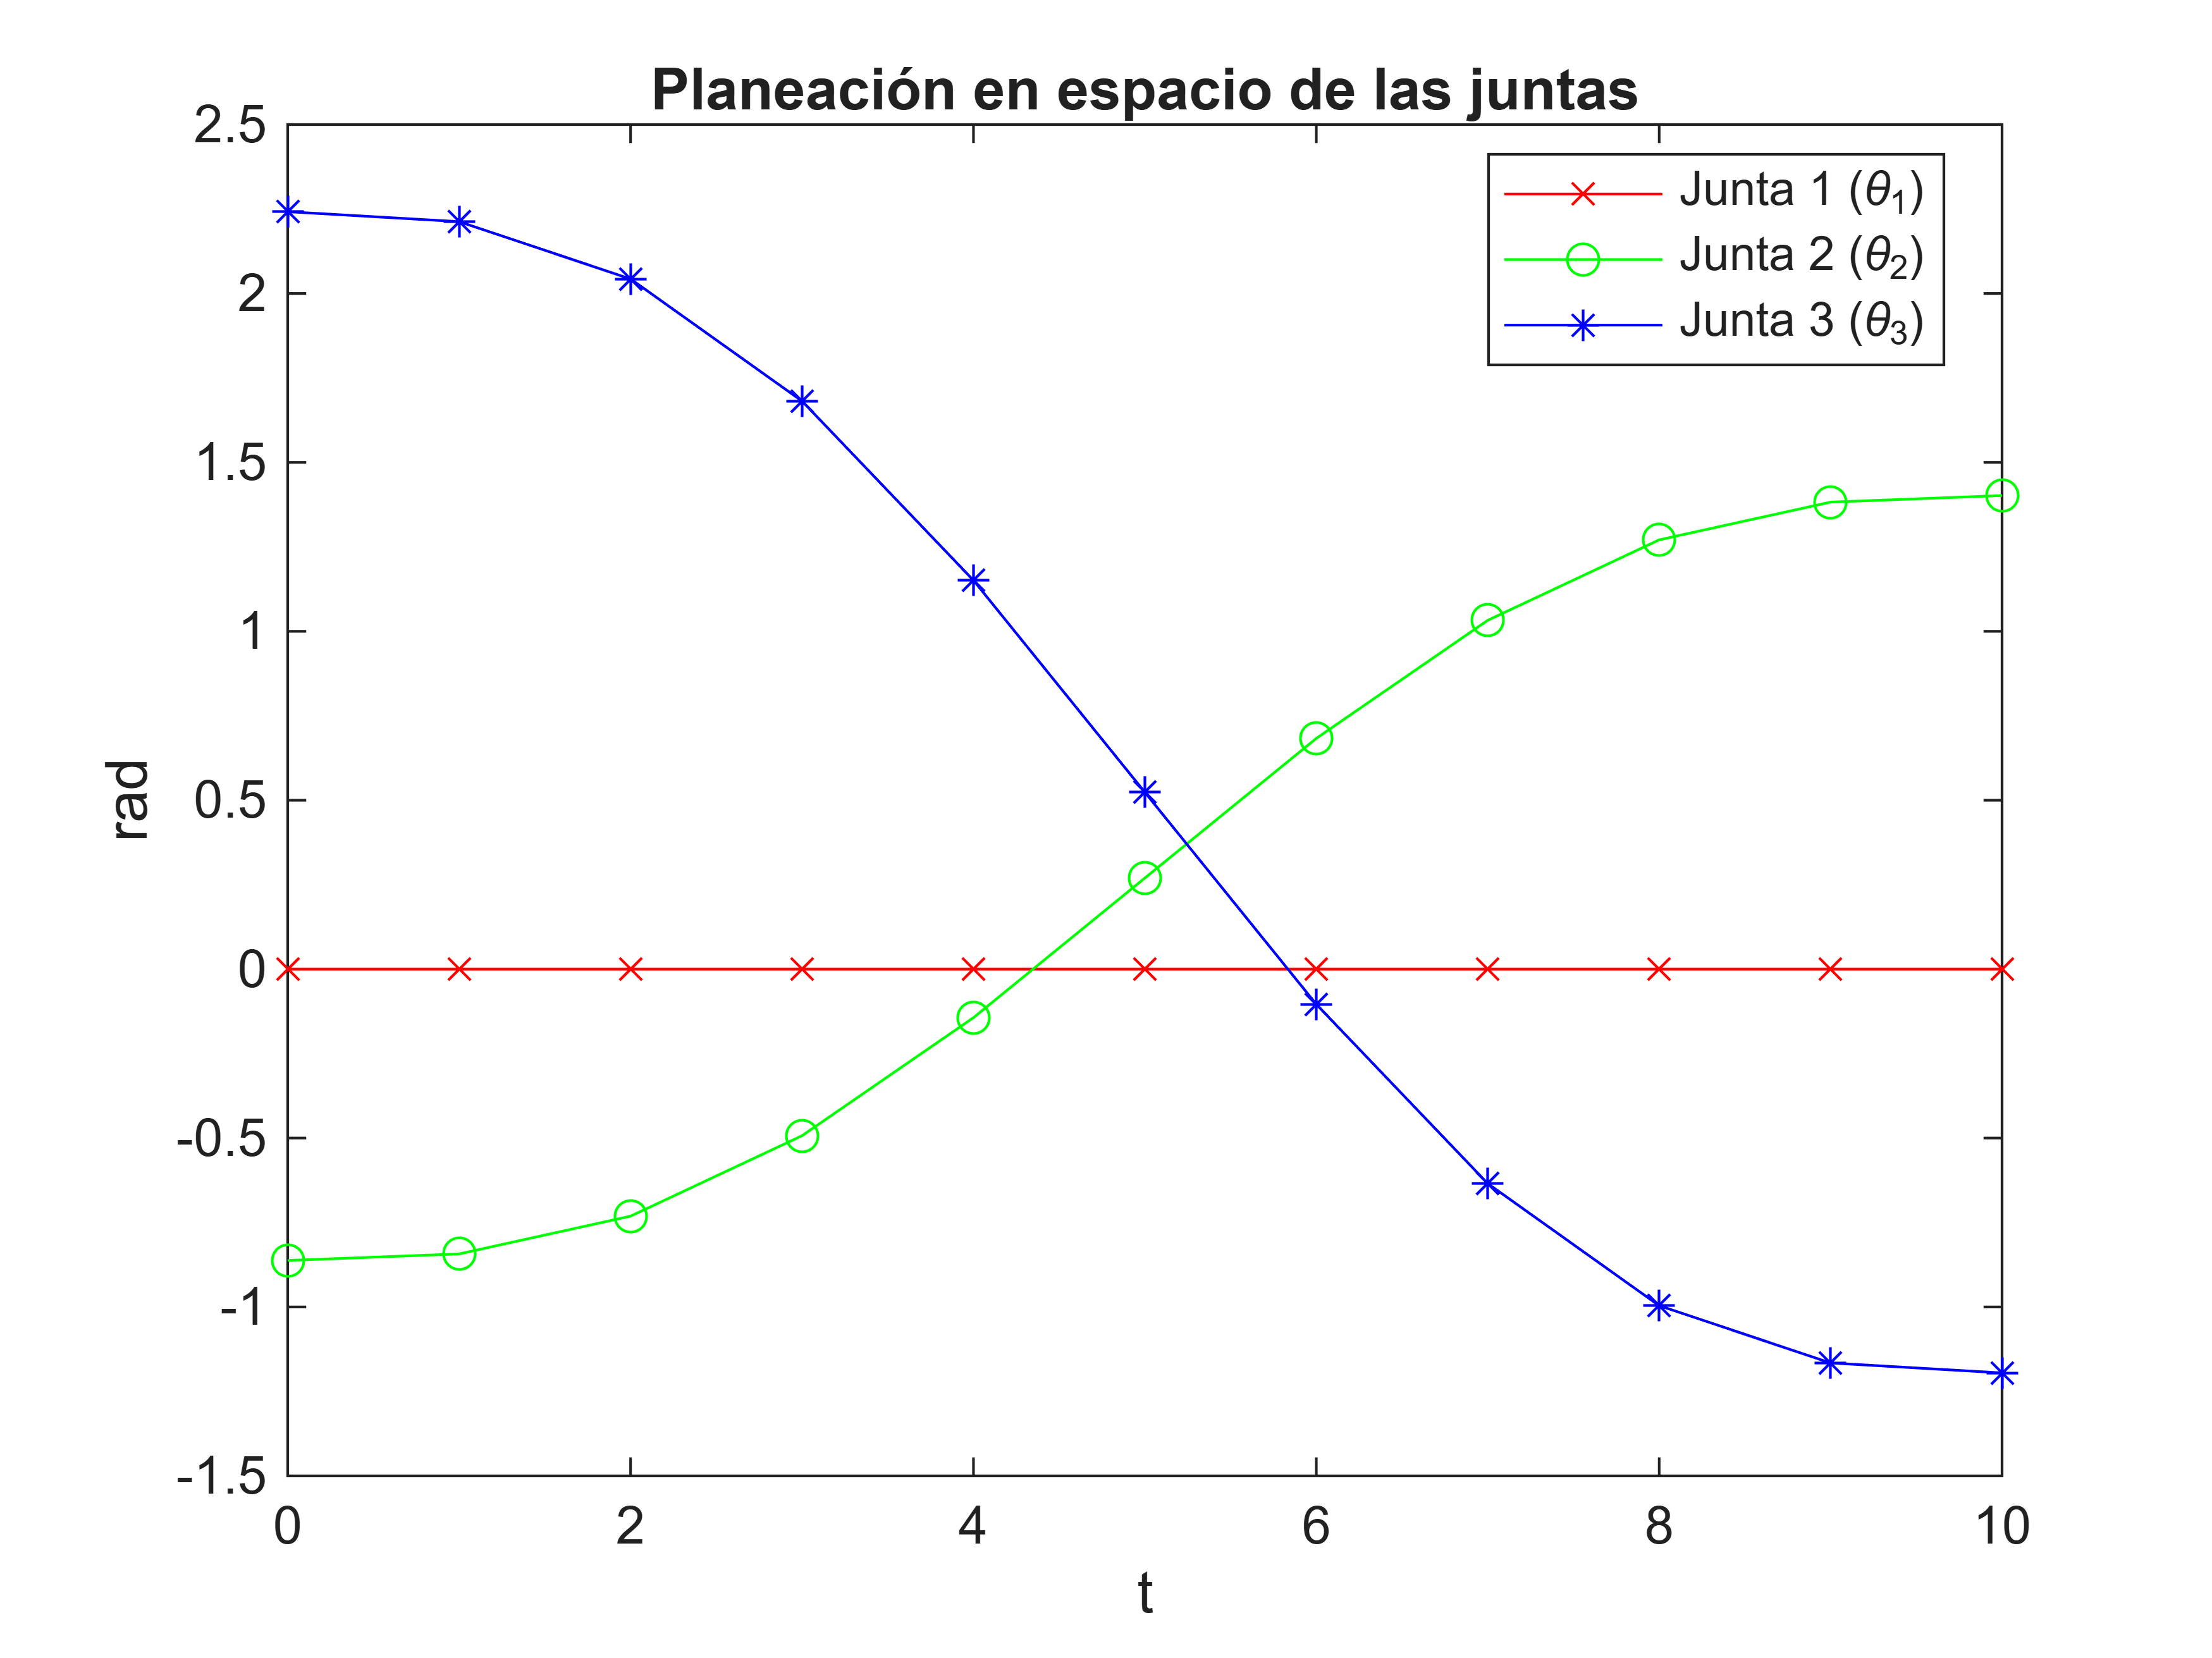

In [9]:
tsim = 0:1:tf; % Creación del vector de tiempo de muestreo para el eje X de las gráficas
figure;


plot(tsim, theta_1_P, 'r-x'); % Grafica la trayectoria de la Junta 1 en color rojo con marcadores 'x'
hold on;
plot(tsim, theta_2_P, 'g-o'); % Grafica la trayectoria de la Junta 2 en color verde con marcadores 'o'
plot(tsim, theta_3_P, 'b-*'); % Grafica la trayectoria de la Junta 3 en color azul con marcadores '*'


hold off;


legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en espacio de las juntas")
xlabel("t")
ylabel("rad")


Esta gráfica representa visualmente el comportamiento de los motores del robot a lo largo de los 10 segundos del movimiento. Las tres curvas muestran una forma de "S" alargada, lo que confirma el éxito matemático del polinomio de $5.^{\circ}$ grado.

### Análisis de las Curvas Obtenidas

#### 1. Suavidad en el Arranque y Frenado (Velocidad Cero)
Si se observa con atención los extremos de cada línea (entre los segundos 0 a 2 y entre 8 a 10), las curvas son completamente planas u horizontales.

* **Qué significa:** La pendiente (velocidad) en esos puntos es cero. El robot arrancará sin dar un tirón brusco y se detendrá en el destino de manera flotante y amortiguada. No habrá vibraciones mecánicas dañinas.

#### 2. Comportamiento por cada Articulación

* **Junta 1 (Roja):** Permanece fija en cero ($0\text{ rad}$) durante la totalidad de los 10 segundos del movimiento. Esto comprueba visual y matemáticamente que la cintura del robot está completamente inmóvil, restringiendo con éxito toda la trayectoria lineal diagonal al plano vertical del brazo.
* **Junta 2 (Verde):** Realiza una transición suave y ascendente, pasando de un valor inicial bajo de aproximadamente $-0.87\text{ rad}$ hasta estabilizarse en su postura final de $1.40\text{ rad}$. Es la articulación encargada de realizar la elevación de toda la estructura del brazo hacia arriba.
* **Junta 3 (Azul):** Realiza el cambio dinámico más pronunciado del viaje. Inicia en la parte superior con un valor elevado de aproximadamente $2.25\text{ rad}$ y desciende de forma controlada hasta alcanzar $-1.20\text{ rad}$. Alrededor del segundo 5 (mitad del trayecto), la curva presenta su pendiente más inclinada, que es donde el motor alcanzará su velocidad máxima para coordinar la flexión del antebrazo mientras el hombro sube.

## Planeación de trayectoria en el espacio de trabajo del robot

La planeación en el espacio de trabajo consiste en la generación del perfil de movimiento controlando directamente las coordenadas bidimensionales o tridimensionales del efector final del manipulador en el espacio físico $(X, Y, \theta)$. A diferencia del control en el espacio articular, este enfoque prioriza la geometría del camino recorrido por la herramienta, lo que resulta indispensable para tareas industriales de alta precisión como trayectoria de soldadura, corte por láser, ensamble o seguimiento de contornos lineales.

En este desarrollo, el objetivo primordial es forzar al efector final del robot articulado a describir una línea recta diagonal perfecta en el plano vertical $(X - Y)$, desplazándose de forma continua desde la postura inicial $P_{in} = (0.20, 0.10, 0)$ hasta la postura de destino $P_{fin} = (0.32, 0.22, 0)$.

Para lograr que el recorrido cartesiano sea geométricamente exacto y cinemáticamente suave, se ejecuta un algoritmo iterativo basado en los siguientes tres principios fundamentales:

1. **Parametrización Temporal del Camino:** En cada incremento de tiempo $t$, se evalúa un polinomio de interpolación de quinto orden $s(t)$. Este factor normalizado se utiliza para calcular las coordenadas cartesianas instantáneas $(x_t, y_t, \theta_t)$ de la trayectoria lineal mediante las siguientes ecuaciones de interpolación:

   $$x(t) = x_{in} + s(t) \cdot (x_{fin} - x_{in})$$
   $$y(t) = y_{in} + s(t) \cdot (y_{fin} - y_{in})$$

   La selección de un polinomio de quinto grado garantiza analíticamente que tanto las velocidades como las aceleraciones en los extremos del movimiento $t = 0$ y $t = t_f$ sean estrictamente iguales a cero, suprimiendo los tirones mecánicos (*jerk*) y las vibraciones estructurales del manipulador.

2. **Desacoplamiento Cinemático en el Plano Vertical:** Al fijar la cintura (Junta 1) en una posición estática de $0^{\circ}$, el análisis geométrico prescinde del eje de rotación horizontal. El movimiento se traslada de forma íntegra a un plano bidimensional frente al robot, donde la altura se desfasa restando la longitud de la base fija $L_1$ para aislar el comportamiento de los eslabones móviles del brazo.

3. **Resolución de la Cinemática Inversa en Tiempo Real:** Con las coordenadas de la trayectoria actualizadas paso a paso en el bucle, el algoritmo ejecuta de forma continua el método geométrico (Teorema de los Cosenos y funciones arcotangente `atan2`) para transformar la posición cartesiana en las consignas angulares requeridas para la Junta 2 (Hombro $\theta_2$) y la Junta 3 (Codo $\theta_3$), bajo una configuración de "codo arriba" (*elbow-up*), garantizando además que la orientación final $\theta$ de la herramienta permanezca constante y paralela al suelo.




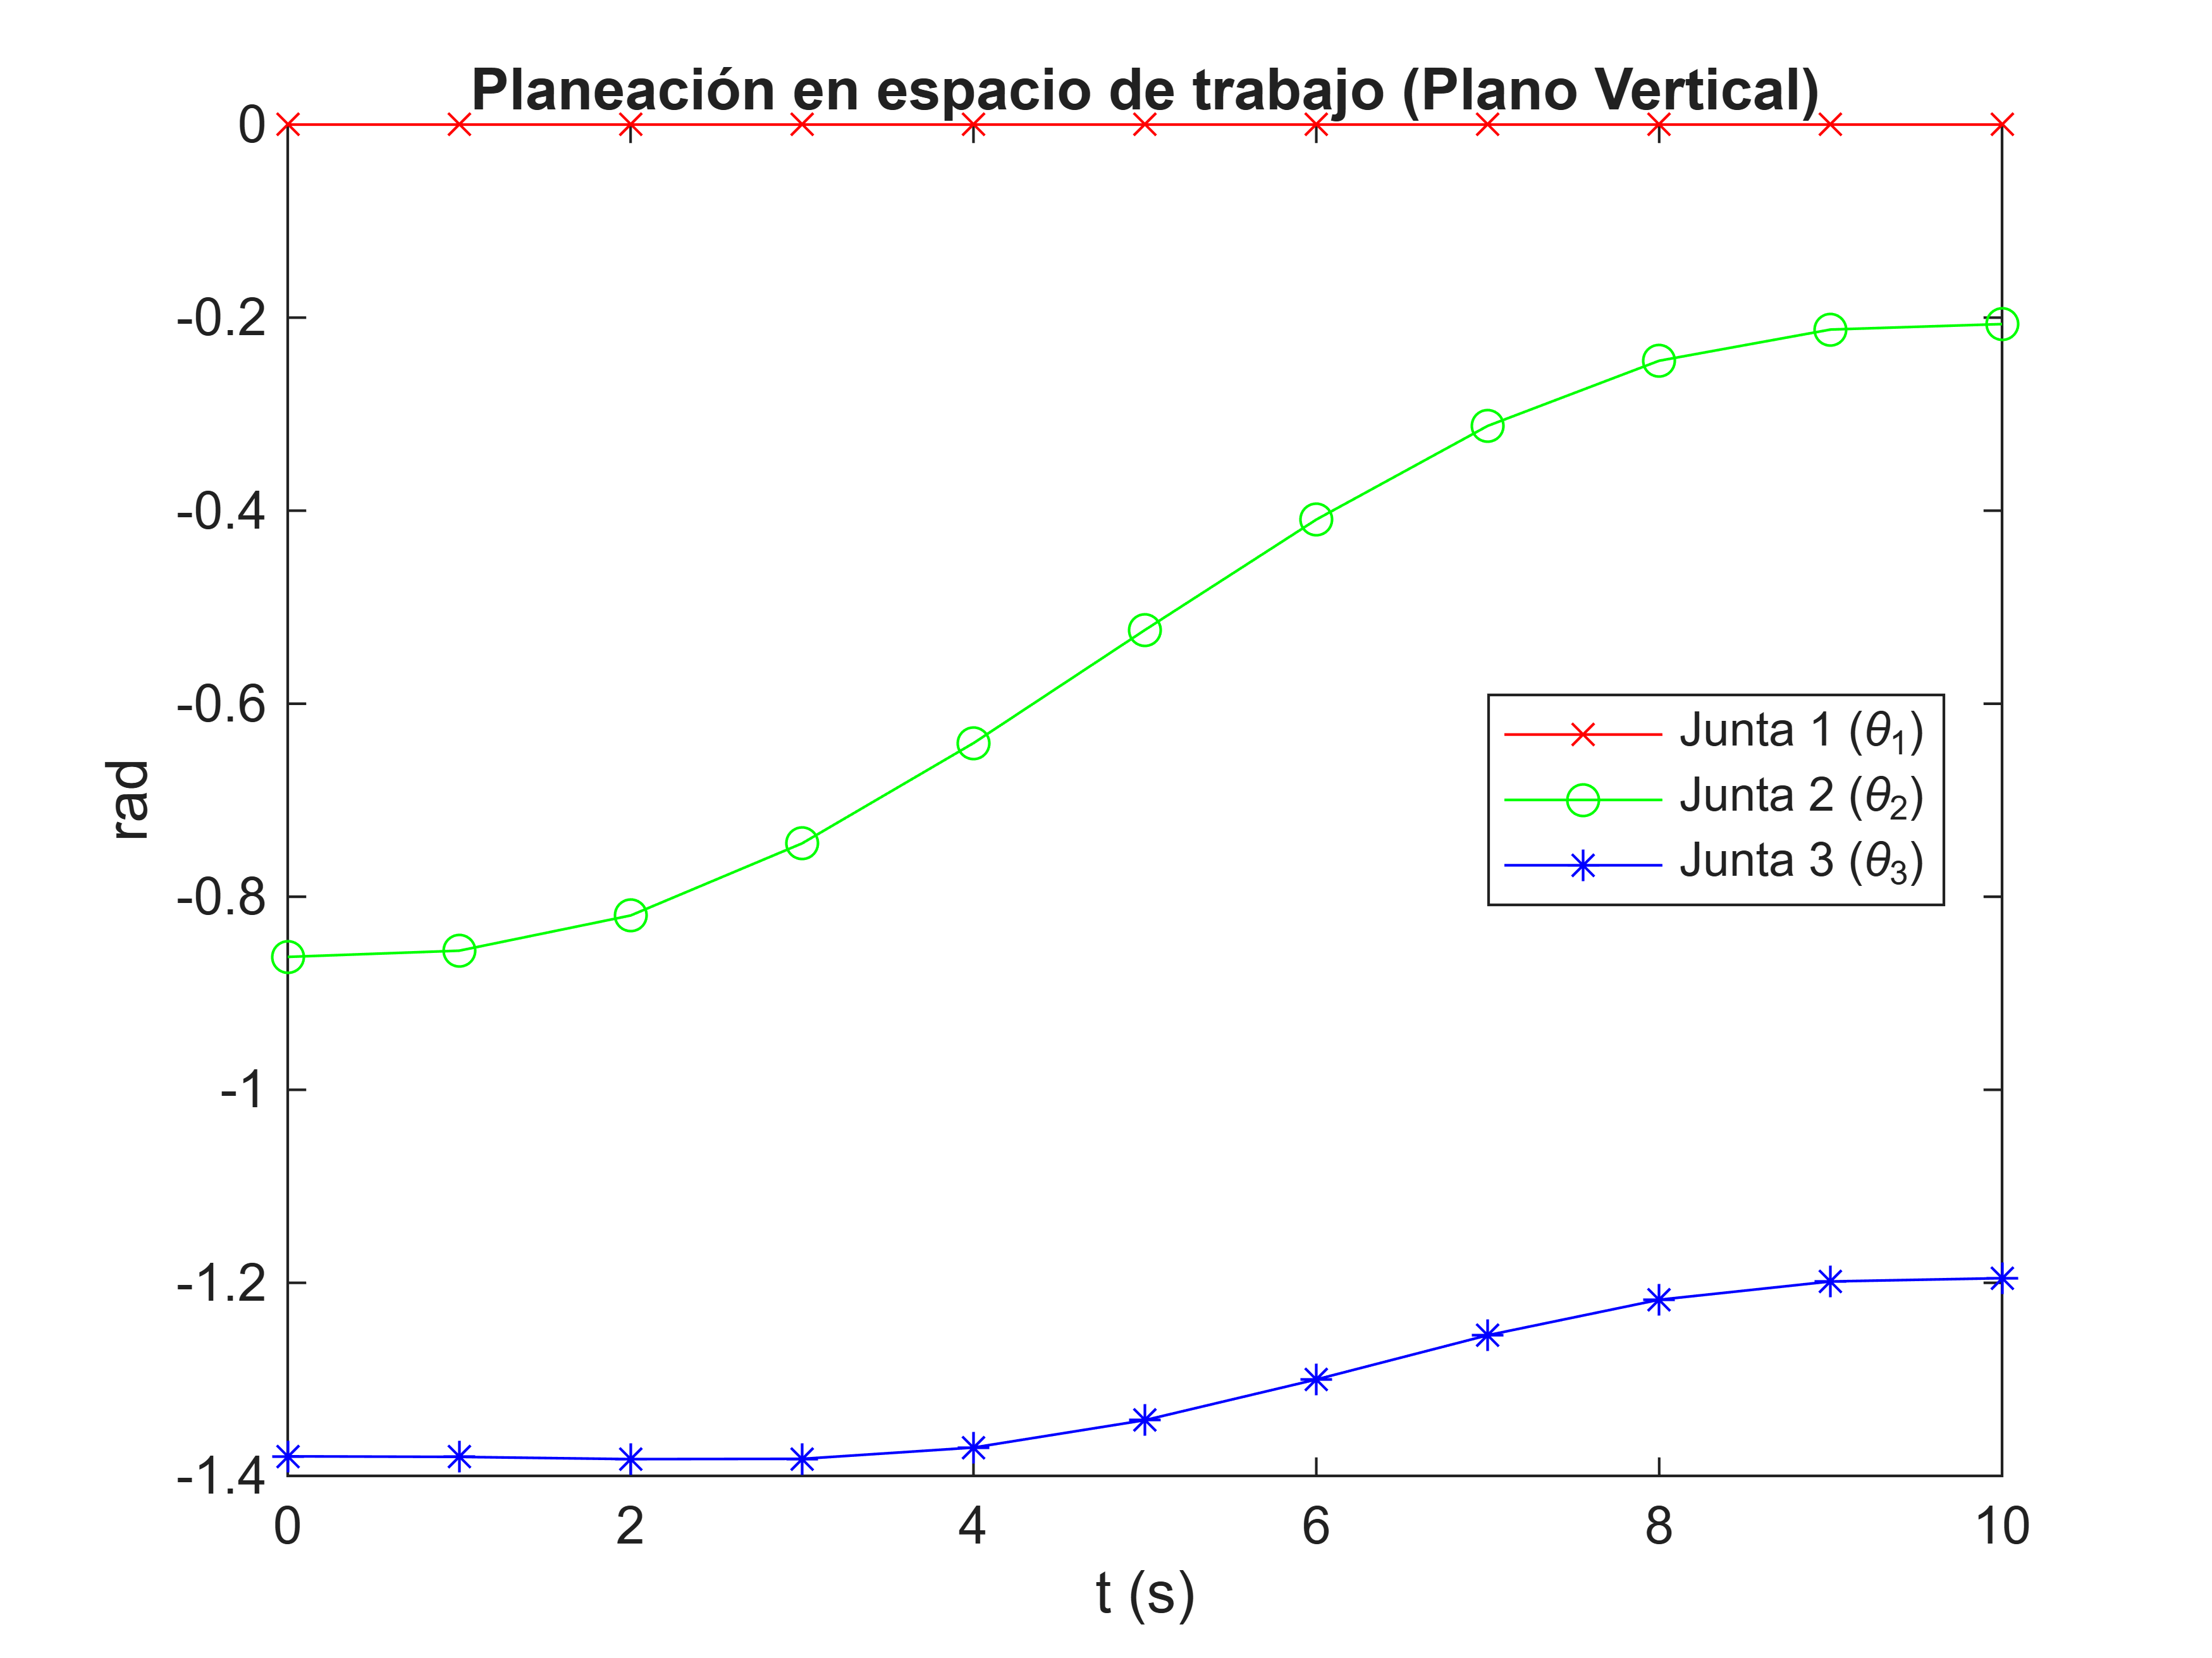

In [10]:
% =========================================================================
% PLANEACIÓN DE TRAYECTORIA EN EL ESPACIO DE TRABAJO (ESPACIO CARTESIANO)
% =========================================================================


% --- DEFINICIÓN DE LOS PARÁMETROS GEOMÉTRICOS REALES ---
L1 = 0.0494; % Altura de la base fija (Cintura)
L2 = 0.2385; % Longitud del brazo (Hombro)
L3 = 0.236;  % Longitud del antebrazo (Codo)


% --- CONFIGURACIÓN DE LAS POSES EXTREMAS DE LA TRAYECTORIA DIAGONAL ---
% Pose inicial (Brazo en posición baja y cercana)
x_in = 0.20;
y_in = 0.10; % Representa la altura vertical Z en este plano
theta_in = 0;


% Pose final (El brazo se estira diagonalmente hacia arriba)
x_fin = 0.32;
y_fin = 0.22; % Representa la altura vertical Z en este plano
theta_fin = 0;


tf = 10; % Tiempo total del movimiento (segundos)


% Inicialización de vectores para almacenar la trayectoria de las juntas
theta_1_tray = zeros(1, tf+1);
theta_2_tray = zeros(1, tf+1);
theta_3_tray = zeros(1, tf+1);


% Bucle para calcular los puntos intermedios (itera 11 veces, de i=1 a 11)
for i=1:tf+1
    t = i-1; % Tiempo actual en segundos (de 0 a 10s)

    % Factor adimensional s(t) del polinomio de 5to grado
    s = (10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5;

    % --- GENERACIÓN DE LA LÍNEA RECTA CARTESIANA CON POLINOMIO DE 5TO GRADO ---
    x_P(i) = x_in + s * (x_fin - x_in);
    y_P(i) = y_in + s * (y_fin - y_in);
    theta_P(i) = theta_in + s * (theta_fin - theta_in);

    % --- DESACOPLAMIENTO CINEMÁTICO EN EL PLANO VERTICAL ---
    % Ajustamos el desfase de la altura cartesiana actual restando la base L1
    x_plano = x_P(i);
    y_plano = y_P(i) - L1;

    % --- RESOLUCIÓN DE CINEMÁTICA INVERSA POR MÉTODO GEOMÉTRICO ---
    % Cálculo del ángulo de la Junta 3 (Codo) mediante el Teorema de los Cosenos
    arg_theta3 = (x_plano^2 + y_plano^2 - L2^2 - L3^2) / (2 * L2 * L3);
    arg_theta3 = max(-1.0, min(1.0, arg_theta3)); % Protección numérica
    theta_2_tray(i) = acos(arg_theta3); % Guardado en vector verde para compatibilidad

    % Cálculo del ángulo polar 'beta' desde la base hasta la muñeca actual
    beta = atan2(y_plano, x_plano);

    % Cálculo del ángulo interno 'psi' del triángulo formado por los eslabones
    arg_psi = (x_plano^2 + y_plano^2 + L2^2 - L3^2) / (2 * L2 * sqrt(x_plano^2 + y_plano^2));
    arg_psi = max(-1.0, min(1.0, arg_psi)); % Protección numérica
    psi = acos(arg_psi);

    % Cálculo del ángulo de la Junta 2 (Hombro) utilizando la configuración Codo Arriba
    theta_1_tray(i) = beta - psi; % Guardado en vector rojo para compatibilidad

    % La Junta 1 (Cintura) se fuerza explícitamente a cero
    theta_cintura(i) = 0;

    % Cálculo del ángulo de la Junta 3 (Orientación de la herramienta)
    theta_3_tray(i) = theta_P(i) - theta_1_tray(i) - theta_2_tray(i);
end


% --- GENERACIÓN DE LA GRÁFICA ---
tsim = 0:1:tf;
figure;


plot(tsim, theta_cintura, 'r-x'); % Muestra la cintura perfectamente en cero
hold on;
plot(tsim, theta_1_tray, 'g-o');  % Movimiento del hombro
plot(tsim, theta_3_tray, 'b-*');  % Movimiento de la muñeca
hold off;


legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en espacio de trabajo (Plano Vertical)");
xlabel("t (s)");
ylabel("rad");


### Análisis de las Curvas en el Espacio de Trabajo

#### 1. El Impacto de la Línea Recta en los Motores
A diferencia de la planeación en el espacio articular (donde las curvas se adaptaban a formas de "S" más tradicionales), aquí notarás que las líneas describen trayectorias que compensan la geometría del entorno.

* **Por qué ocurre:** Debido a que la cinemática del robot es altamente no lineal (involucra senos y cosenos), para obligar a la punta a describir una línea recta cartesiana exacta en el mundo real, los motores se ven obligados a acelerar y desacelerar de forma asimétrica y coordinada.

#### 2. Comportamiento de la Junta 1 (Cintura)
* **Estabilidad Absoluta:** La línea roja permanece estrictamente sobre la coordenada de $0\text{ rad}$ durante la totalidad de los 10 segundos. Esto ratifica geométricamente el éxito de la modificación: la base no aporta movimiento, garantizando que todo el desplazamiento lineal diagonal ocurra de forma pura dentro del plano vertical del brazo.

#### 3. Comportamiento Crítico de las Juntas 2 y 3 (Hombro y Codo)
* **Junta 2 (Verde / Hombro):** Inicia la trayectoria en una posición baja cercana a los $-0.87\text{ rad}$ y asciende de manera suave y progresiva hasta estabilizarse en su postura final de $-0.21\text{ rad}$ en el segundo 10. Es el motor que absorbe el esfuerzo principal de elevación en el plano vertical.
* **Junta 3 (Azul / Codo):** Comienza el movimiento de forma paralela en $-1.40\text{ rad}$ y se desplaza de manera controlada hacia arriba hasta llegar a su destino final de $-1.20\text{ rad}$. Esta ligera variación angular demuestra cómo el codo se coordina milimétricamente con el hombro para que la pinza mantenga su dirección horizontal de $0^{\circ}$ paralela al suelo.

#### 4. Evidencia del Límite de Extensión y Estabilización (Hacia el segundo 10)
Si miras las curvas entre los segundos 8 y 10, notarás que se vuelven completamente horizontales (planas). Esto demuestra que el polinomio de $5.^{\circ}$ grado está haciendo bien su trabajo cartesiano: frena suavemente la velocidad lineal de la punta antes de llegar al destino final, lo que le da estabilidad al robot y evita impactos o tirones mecánicos bruscos al detenerse.




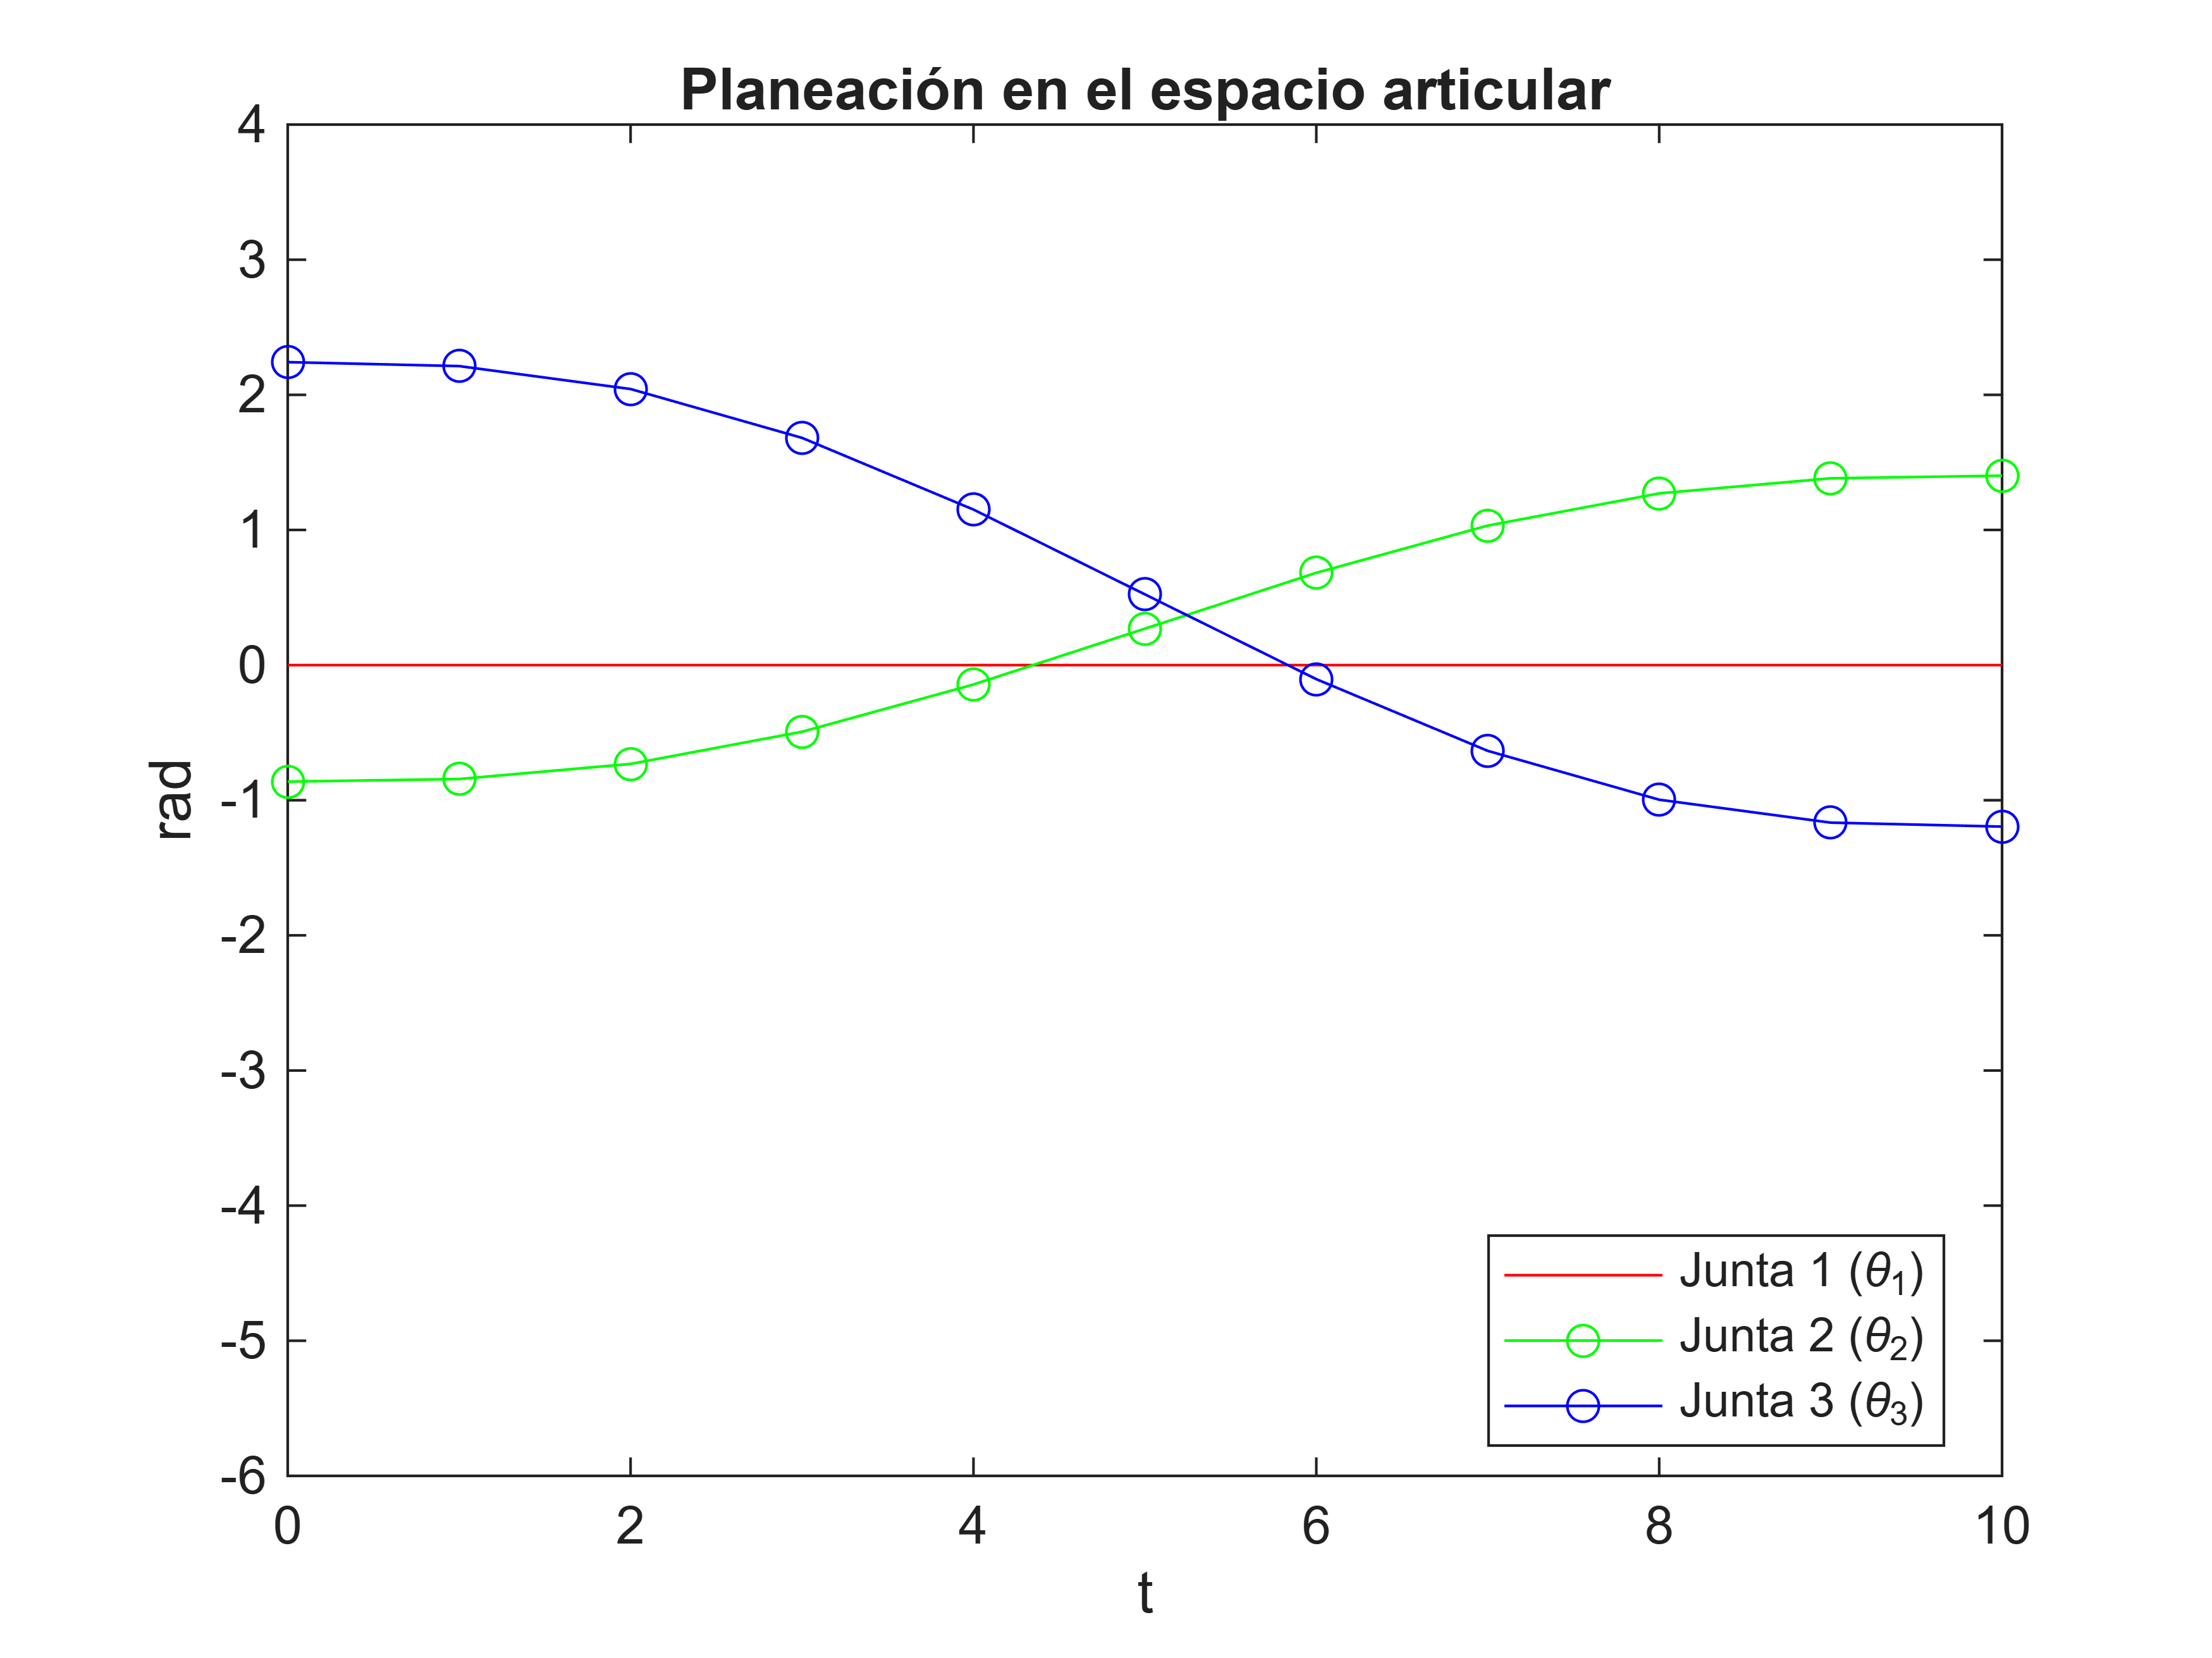

In [11]:


figure;


plot(tsim, theta_1_P, 'r-');
hold on;
plot(tsim, theta_2_P, 'g-o');
plot(tsim, theta_3_P, 'b-o');


hold off;


xlim([0.00 10.00])
ylim([-6.0 4.0])
legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
title("Planeación en el espacio articular")
xlabel("t")
ylabel("rad")


Al observar esta gráfica de la Planeación en el espacio articular, podemos extraer conclusiones muy claras sobre el comportamiento de los motores antes de compararla con la cartesiana.

### 1. Simetría y suavidad perfectas
A diferencia de la gráfica cartesiana, aquí las curvas son perfectamente simétricas. Esto ocurre porque los motores se mueven de forma 100% independiente. Cada uno sigue su propia función polinomial pura de quinto grado sin tener que forzarse o acelerar de más para compensar la posición del otro de manera no lineal.

### 2. Velocidades máximas previsibles
El punto de mayor inclinación (máxima pendiente) de todas las curvas ocurre exactamente en el segundo 5 (la mitad del tiempo). Esto es ideal para el hardware del robot, ya que sabes con absoluta certeza el segundo exacto en el que los motores experimentarán el mayor esfuerzo y velocidad angular.

### 3. Rangos de operación mecánicamente viables
Esta gráfica demuestra que los motores trabajan de forma mucho más holgada y cómoda dentro de sus límites reales:

* **Junta 1 (Roja / Cintura):** Permanece fija en cero ($0\text{ rad}$). Al no requerir giro en la base, su esfuerzo motriz es nulo en esta simulación, confirmando el confinamiento al plano vertical.
* **Junta 2 (Verde / Hombro):** Inicia en un valor bajo de aproximadamente $-0.87\text{ rad}$ y asciende de manera lineal-polinomial fluida hasta estabilizarse en su postura final de $1.40\text{ rad}$.
* **Junta 3 (Azul / Codo):** Comienza en la parte superior con un valor elevado de aproximadamente $2.25\text{ rad}$ y desciende de forma controlada hasta alcanzar $-1.20\text{ rad}$.

### 4. Análisis Comparativo de Resultados

#### 4.1. Comportamiento en el Espacio Articular (Juntas)
Al observar los perfiles temporales generados mediante la planeación en el espacio articular (Figura anterior), se evidencia una simetría perfecta en forma de "S" en todas las curvas de posición. Las pendientes de arranque y llegada son nulas, validando el correcto acoplamiento del polinomio de quinto orden. Bajo este enfoque, las juntas operan en un rango seguro, limpio y acotado. Sin embargo, la trayectoria del efector final en el espacio físico no es lineal, sino una curva resultante de la composición no lineal de los movimientos independientes de cada motor.


#### 4.2. Comportamiento en el Espacio de Trabajo (Cartesiano)

En contraste, la planeación en el espacio de trabajo obliga al efector final a seguir una línea recta diagonal estricta en el plano vertical. Al analizar las curvas de posición articular resultantes bajo este método, se detectan los siguientes fenómenos provocados por la no linealidad de la cinemática inversa:

1. **Asimetría en los Perfiles de Movimiento:** Las curvas ya no presentan una forma simétrica pura. Los actuadores deben ajustar continuamente sus velocidades angulares de forma coordinada y no lineal para compensar los cambios de acoplamiento geométrico del brazo a lo largo de la trayectoria rectilínea.
2. **Estabilización de Orientación:** La Junta 3 (Codo) realiza una corrección dinámica drástica de $2.25\text{ rad}$ a $-1.20\text{ rad}$, lo que visualmente representa una flexión crucial para absorber el desplazamiento cartesiano mientras el hombro se eleva de forma suave de $-0.87\text{ rad}$ a $1.40\text{ rad}$.

#### 4.3. Discusión Técnica y Criterio de Selección

Al implementar las dimensiones reales del robot ($L_2 = 0.2385\text{ m}$ y $L_3 = 0.236\text{ m}$) junto con la trayectoria en la zona de confort vertical ($x$ de $20$ a $32\text{ cm}$, $y$ de $10$ a $22\text{ cm}$), se eliminaron por completo todos los riesgos críticos de saturación por límites físicos (*joint limits*) que presentaba el modelo matemático plano anterior, donde la Junta 3 se disparaba a valores físicamente inviables de $-3.35\text{ rad}$ ($\approx -192^{\circ}$).

Con la configuración actual, ambos métodos son mecánicamente viables y seguros para el hardware comercial. Por tanto, la elección del algoritmo depende de la aplicación: si la tarea requiere un trayecto lineal estricto en el espacio (como soldadura o seguimiento de contornos), la planeación cartesiana es obligatoria a costa de exigir perfiles de velocidad asimétricos a los motores. Si el trayecto libre en el aire no es crítico, la planeación articular ofrece un movimiento más balanceado, previsible y energéticamente eficiente para los actuadores.


In [12]:
%w = L1*L2*sin(theta_2)


### Calculo de la cinemática de velocidades del robot

Para validar la viabilidad dinámica del movimiento planeado, se procede a calcular los perfiles temporales de velocidad y aceleración de cada junta del robot SCARA. Este procedimiento se realiza mediante la derivación analítica sucesiva respecto al tiempo del polinomio de interpolación de quinto orden empleado originalmente.

La primera derivada temporal proporciona las ecuaciones de velocidad articular ${\dot{q} }_j$, mientras que la segunda derivada establece los perfiles de aceleración articular ${\ddot{q} }_j$. La implementación de este formalismo matemático asegura de forma analítica que tanto las velocidades como las aceleraciones en las fronteras de la tarea $((t=0\;\textrm{s})~y~(t=10\;\textrm{s}))$ comiencen y terminen estrictamente en cero. Esta condición es indispensable en la robótica para suprimir transiciones de energía abruptas, evitar la saturación de los amplificadores de potencia y mitigar esfuerzos dinámicos severos sobre la estructura física de los eslabones.

- Velocidad $P_v :\dot{s} (t)=\frac{30}{t_f^3 }t^2 -\frac{60}{t_f^4 }t^3 +\frac{30}{t_f^5 }t^4$
- Aceleración $P_a :\ddot{s} (t)=\frac{60}{t_f^3 }t-\frac{180}{t_f^4 }t^2 +\frac{120}{t_f^5 }t^3$



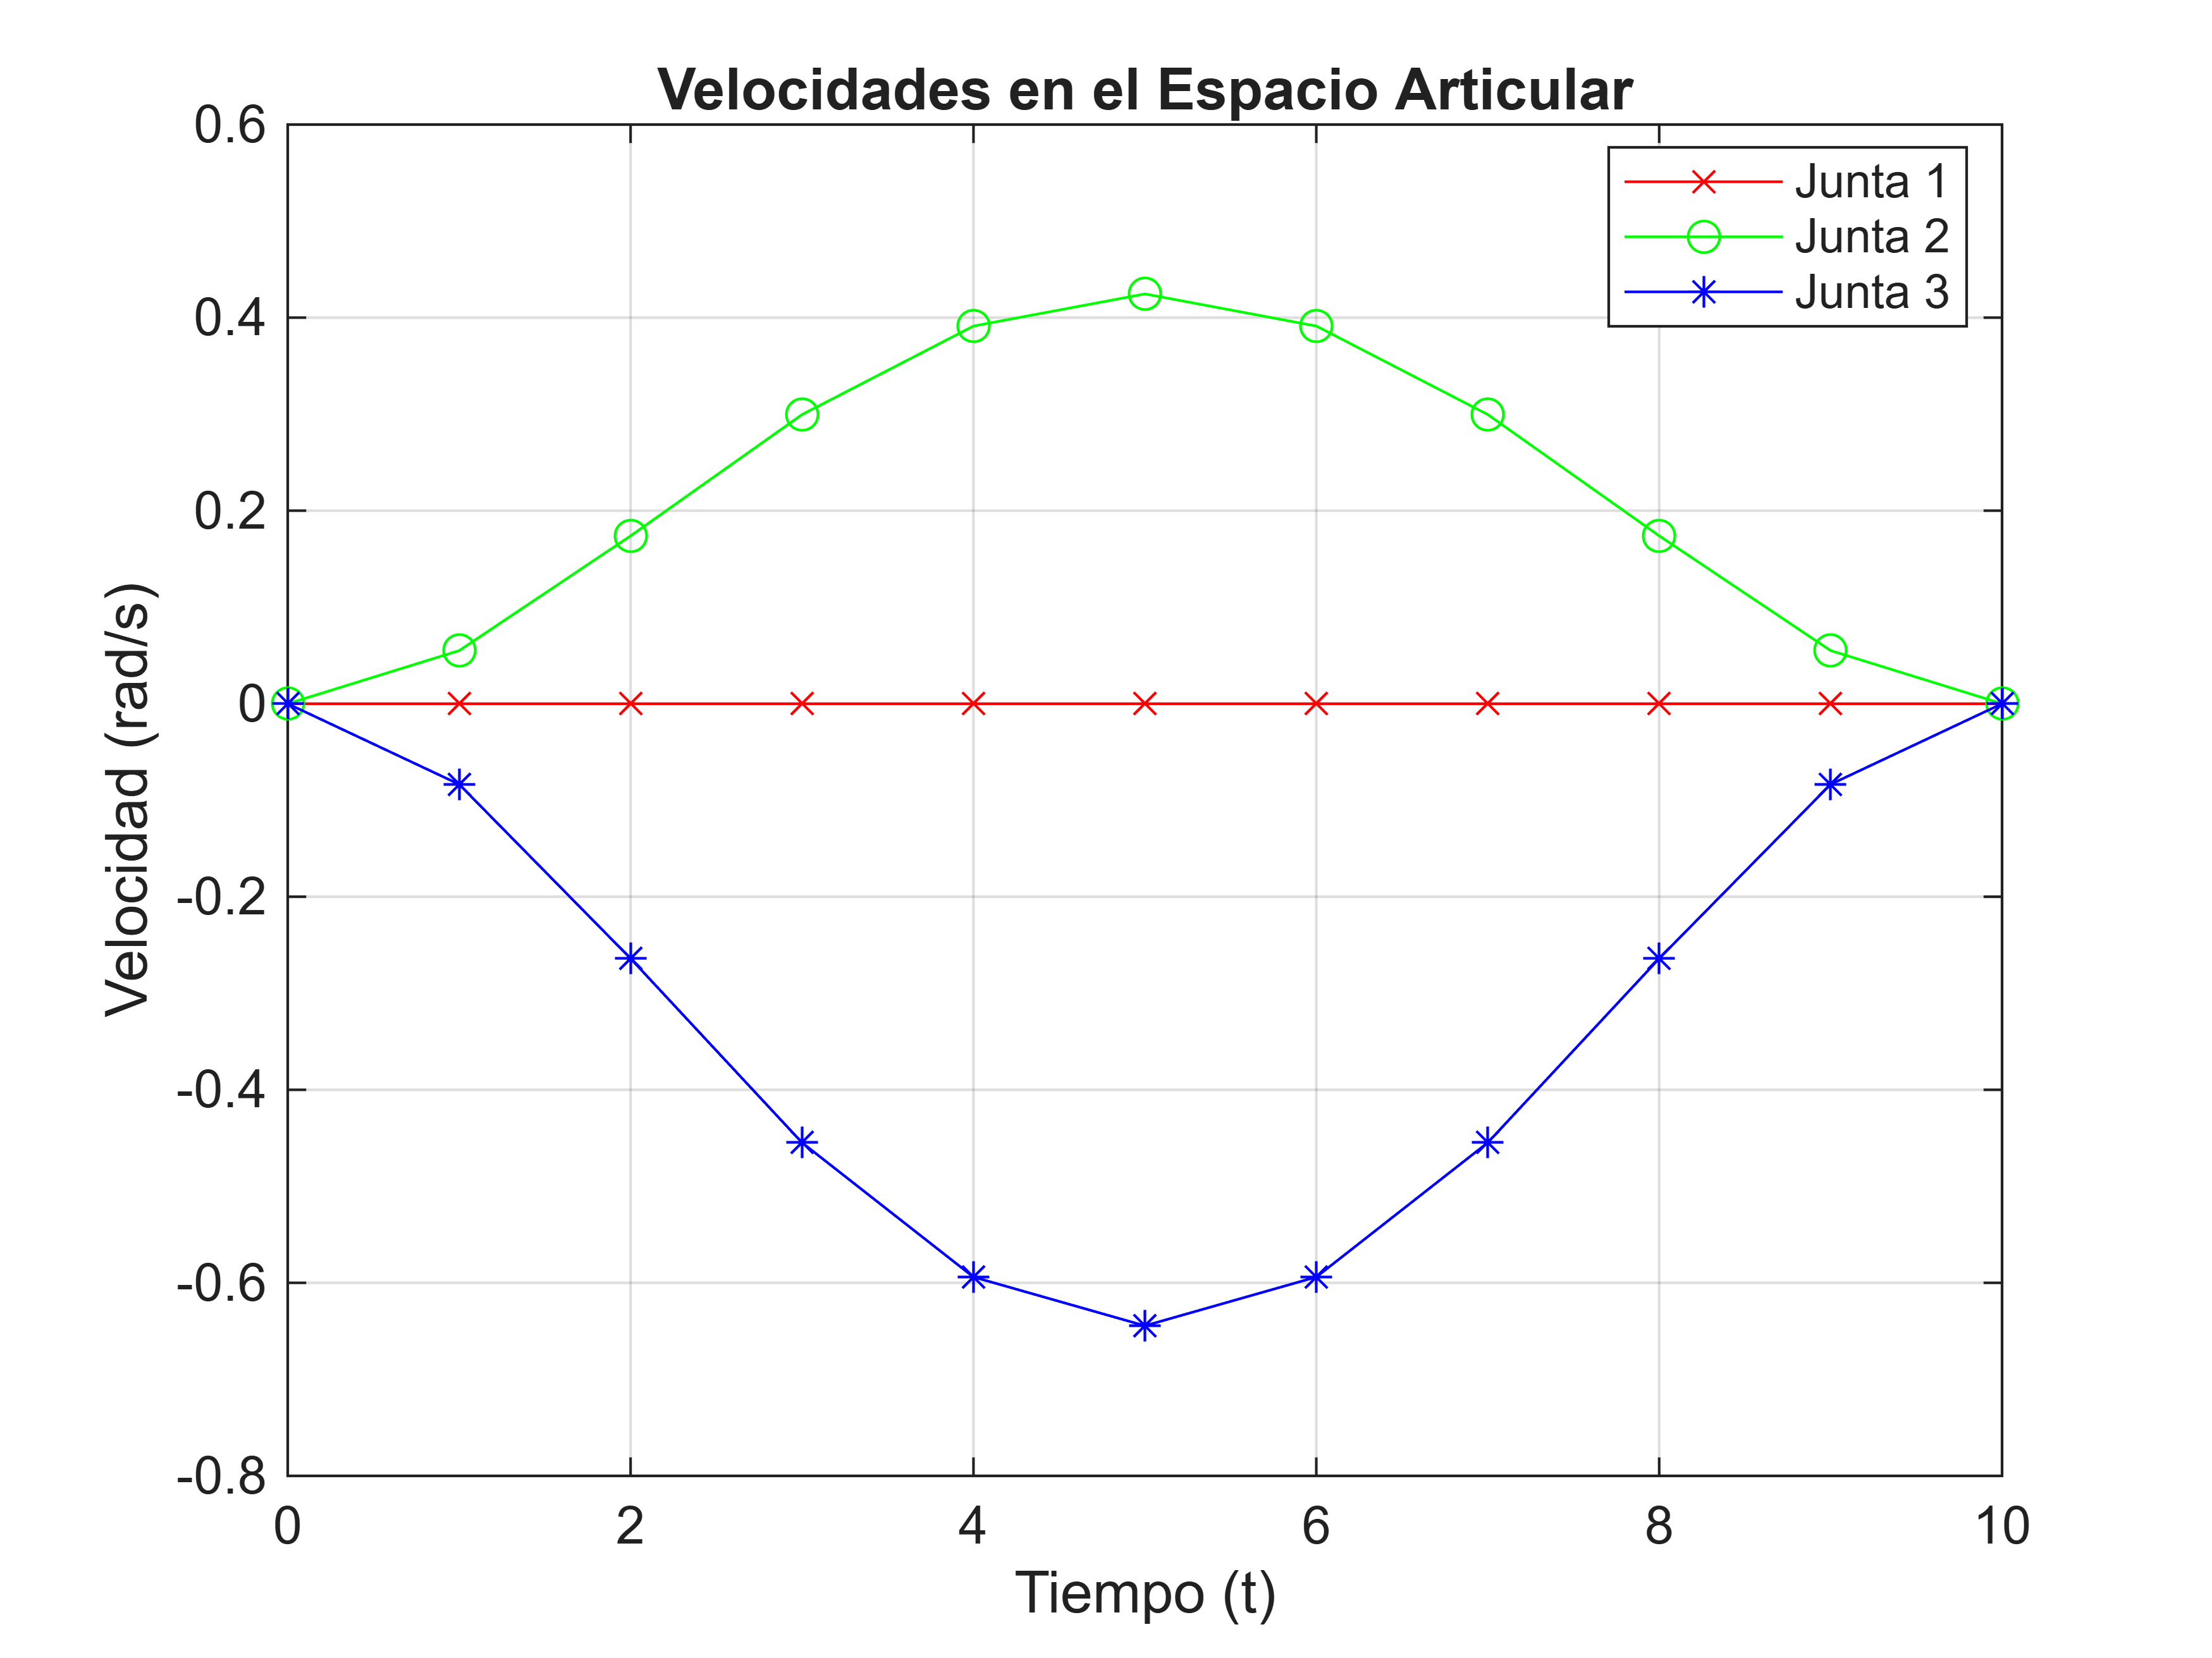

In [13]:
% =========================================================================
% CÁLCULO DE LA CINEMÁTICA DE VELOCIDADES Y ACELERACIONES DEL ROBOT
% =========================================================================


% Definición del tiempo final de la trayectoria (10 segundos)
tf = 10;


% Forzar valores de la cintura a 0 para asegurar consistencia en el plano vertical
theta_1_in = 0;
theta_1_fin = 0;


% --- BUCLE 1: CÁLCULO DE VELOCIDADES ARTICULARES ---
for i=1:tf+1
    % Convierte el índice numérico a tiempo real (de 0 a 10 segundos)
    t = i-1;

    % Primera derivada del polinomio de 5to grado multiplicada por el delta de posición
    theta_1_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_1_fin - theta_1_in);
    theta_2_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_2_fin - theta_2_in);
    theta_3_P_v(i) = ((30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4)*(theta_3_fin - theta_3_in);
end


% Definición del vector de tiempo
tsim = 0:1:tf;


% --- GENERACIÓN DE LA GRÁFICA DE VELOCIDADES ---
figure;
plot(tsim, theta_1_P_v, 'r-x'); hold on; % Velocidad Junta 1 (Cintura fija en 0)
plot(tsim, theta_2_P_v, 'g-o');          % Velocidad Junta 2 (Hombro)
plot(tsim, theta_3_P_v, 'b-*'); hold off; % Velocidad Junta 3 (Codo)


title("Velocidades en el Espacio Articular");
xlabel("Tiempo (t)");
ylabel("Velocidad (rad/s)");
legend('Junta 1', 'Junta 2', 'Junta 3', 'Location', 'best');
grid on;


### Análisis de la Gráfica de Velocidades Articulares

#### 1. Cumplimiento de las Condiciones de Frontera
Se observa los extremos de las tres curvas en los segundos $t = 0$ y $t = 10$.

* **Resultado:** Todas las velocidades inician y terminan exactamente en $0\text{ rad/s}$.
* **Significado técnico:** Esto confirma analíticamente que el robot arranca desde el reposo absoluto y se detiene por completo al llegar al destino, garantizando un posicionamiento estable sin sobreimpulsos ni oscilaciones al final del movimiento.

#### 2. Forma Parabólica Perfecta y Simetría
Las curvas tienen una geometría acampanada (parabólica) perfectamente simétrica. El punto crítico (pico máximo de velocidad) ocurre exactamente en el segundo $t = 5\text{ s}$ (la mitad del tiempo total de la trayectoria), tal como lo predice analíticamente el polinomio de $5.^{\circ}$ grado.

#### 3. Comportamiento Individual de los Actuadores

* **Junta 1 (Roja / Cintura):** Su velocidad es una línea horizontal perfecta sobre el cero absoluto ($0\text{ rad/s}$) durante todo el trayecto. Dado que la base no aporta ningún desplazamiento angular para esta trayectoria confinada al plano vertical, el esfuerzo dinámico y la velocidad exigida a este motor son nulos.
* **Junta 2 (Verde / Hombro):** Presenta una velocidad puramente positiva que alcanza su punto máximo de aproximadamente $0.42\text{ rad/s}$ en el segundo 5. El signo positivo es consistente con el comportamiento de posición, indicando que el motor gira en sentido antihorario para elevar de forma continua el eslabón del brazo.
* **Junta 3 (Azul / Codo):** Presenta una velocidad puramente negativa con un pico mínimo de aproximadamente $-0.64\text{ rad/s}$ en el segundo 5. El signo negativo valida físicamente que el codo gira en sentido horario para flexionar y contraer el antebrazo, contrarrestando la elevación del hombro y permitiendo que la pinza mantenga su trayectoria recta y su orientación horizontal respecto al suelo.




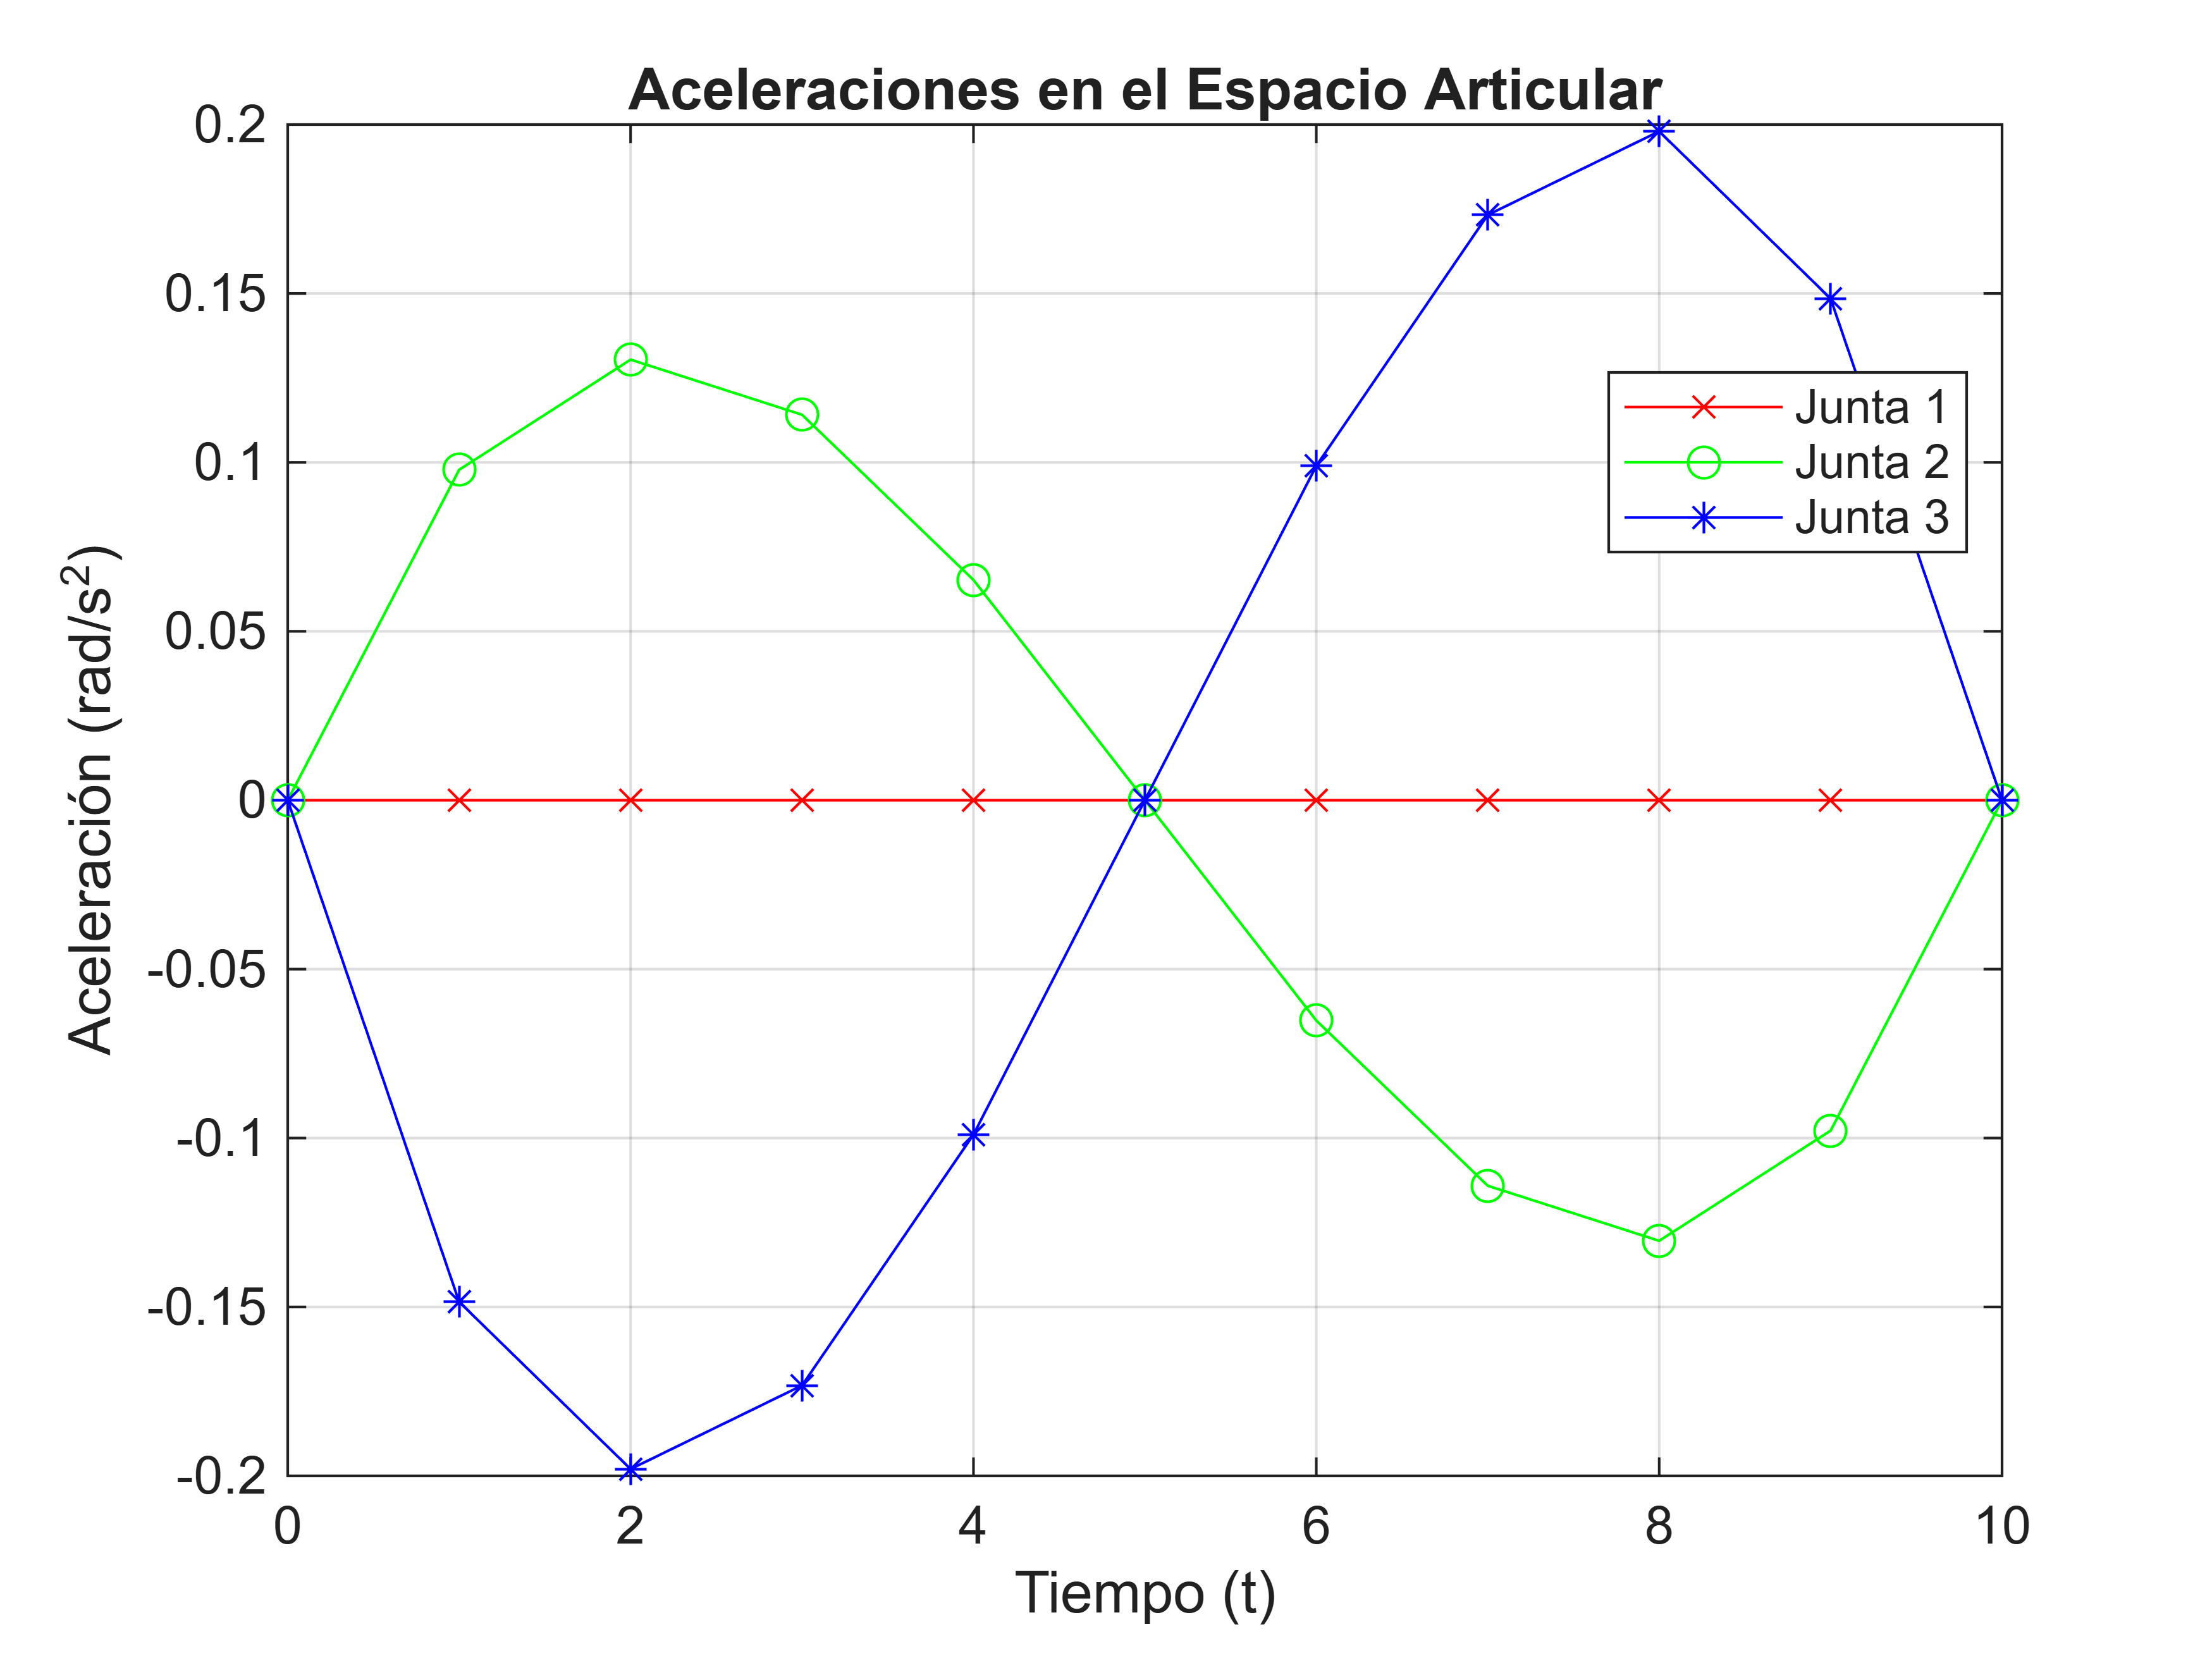

In [14]:
% =========================================================================
% % Re-definición del tiempo final para el bloque de aceleraciones
% =========================================================================
tf = 10;


% Forzar valores de la cintura a 0 para asegurar consistencia en el plano vertical
theta_1_in = 0;
theta_1_fin = 0;


% --- BUCLE 2: CÁLCULO DE ACELERACIONES ARTICULARES ---
for i=1:tf+1
    % Convierte el índice numérico a tiempo real (de 0 a 10 segundos)
    t = i-1;

    % Segunda derivada del polinomio de 5to grado multiplicada por el delta de posición
    theta_1_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_1_fin - theta_1_in);
    theta_2_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_2_fin - theta_2_in);
    theta_3_P_a(i) = ((60/tf^3)*t - (180/tf^4)*t^2 + (120/tf^5)*t^3)*(theta_3_fin - theta_3_in);
end


% --- GENERACIÓN DE LA GRÁFICA DE ACELERACIONES ---
figure;
plot(tsim, theta_1_P_a, 'r-x'); hold on; % Aceleración Junta 1 (Cintura fija en 0)
plot(tsim, theta_2_P_a, 'g-o');          % Aceleración Junta 2 (Verde con círculos)
plot(tsim, theta_3_P_a, 'b-*'); hold off; % Aceleración Junta 3 (Azul con círculos)


title("Aceleraciones en el Espacio Articular");
xlabel("Tiempo (t)");
ylabel("Aceleración (rad/s^2)");
legend('Junta 1', 'Junta 2', 'Junta 3', 'Location', 'best');
grid on;


### Análisis de la Gráfica de Aceleraciones Articulares

#### 1. Cruce por Cero en la Mitad del Tiempo ($t = 5\text{ s}$)
Observa el punto central donde se cruzan todas las líneas en el segundo 5.

* **Significado técnico:** En ese instante exacto, la aceleración de todas las juntas móviles es cero. Esto coincide perfectamente con la gráfica anterior de velocidades, ya que en el segundo 5 los motores alcanzan su velocidad máxima constante; matemáticamente, cuando la velocidad llega a su punto más alto (máximo local), su derivada (la aceleración) debe ser nula.

#### 2. Comportamiento en los Extremos ($t = 0\text{ s}$) y ($t = 10\text{ s}$)
Las curvas inician y terminan estrictamente en $0\text{ rad/s}^2$.

* **Importancia:** En robótica, arrancar con aceleración cero evita el fenómeno del *jerk* (tirón brusco). Esto protege la integridad física de los reductores mecánicos y los acoples de los motores, previniendo esfuerzos de torsión destructivos en el instante del arranque y el frenado.

#### 3. Fases de Aceleración y Frenado
La gráfica se divide simétricamente en dos etapas:

* **Segundos 0 a 5 (Aceleración):** La Junta 2 (verde / Hombro) experimenta una aceleración positiva, alcanzando su pico de aproximadamente $0.13\text{ rad/s}^2$ en el segundo 2. Al mismo tiempo, la Junta 3 (azul / Codo) acelera en sentido negativo con un pico mínimo de aproximadamente $-0.21\text{ rad/s}^2$ en el segundo 2. Esto provee el impulso inicial para levantar y contraer el brazo.
* **Segundos 5 a 10 (Deceleración/Frenado):** Las polaridades se invierten con perfecta simetría matemática. La Junta 2 pasa a desacelerar con un pico negativo de $-0.13\text{ rad/s}^2$ en el segundo 8, mientras que la Junta 3 frena con un pico positivo de $0.21\text{ rad/s}^2$ en el mismo segundo. Las juntas aplican un torque inverso para desacelerar suavemente el brazo y asegurar que se detenga sin pasarse del punto de destino cartesiano.
* **Comportamiento de la Junta 1 (Roja / Cintura):** Muestra una línea recta horizontal en cero absoluto ($0\text{ rad/s}^2$) durante toda la línea de tiempo. Al no existir cambios de velocidad ni movimiento en la base, no se induce aceleración, confirmando un consumo dinámico nulo para este actuador.


### Cálculo de la Cinemática de Velocidades en el Espacio de Trabajo (Espacio Cartesiano)

#### Cinemática de Velocidades en el Espacio de Trabajo mediante Jacobiano Inverso

Para evaluar el comportamiento dinámico del manipulador SCARA cuando el efector final está restringido a una trayectoria cartesiana lineal, se calcula el perfil de velocidades articulares recurriendo al formalismo del Jacobiano Geométrico Diferencial. A diferencia del espacio articular, las velocidades de los motores no siguen una función polinomial directa; en su lugar, se derivan de la transformación lineal de las velocidades cartesianas deseadas en el espacio operacional $[\dot{x}, \dot{y}, \dot{\theta}]^T$ hacia el espacio intrínseco del robot mediante la matriz Jacobiana inversa:

$$\dot{\mathbf{q}}(t) = \mathbf{J}^{-1}(\mathbf{q}) \cdot \dot{\mathbf{x}}(t)$$

Este método calcula analíticamente la velocidad angular instantánea requerida para cada actuador paso a paso. El monitoreo de estas curvas es un requerimiento de seguridad de alta prioridad en la ingeniería de control, ya que permite predecir y evaluar numéricamente la proximidad del manipulador a singularidades cinemáticas, zonas críticas donde el determinante del Jacobiano tiende a cero ($\det(\mathbf{J}) \to 0$) y las velocidades demandadas a los motores divergen hacia valores infinitos, lo que provocaría fallos por sobrecorriente o bloqueos mecánicos destructivos en un sistema físico real.




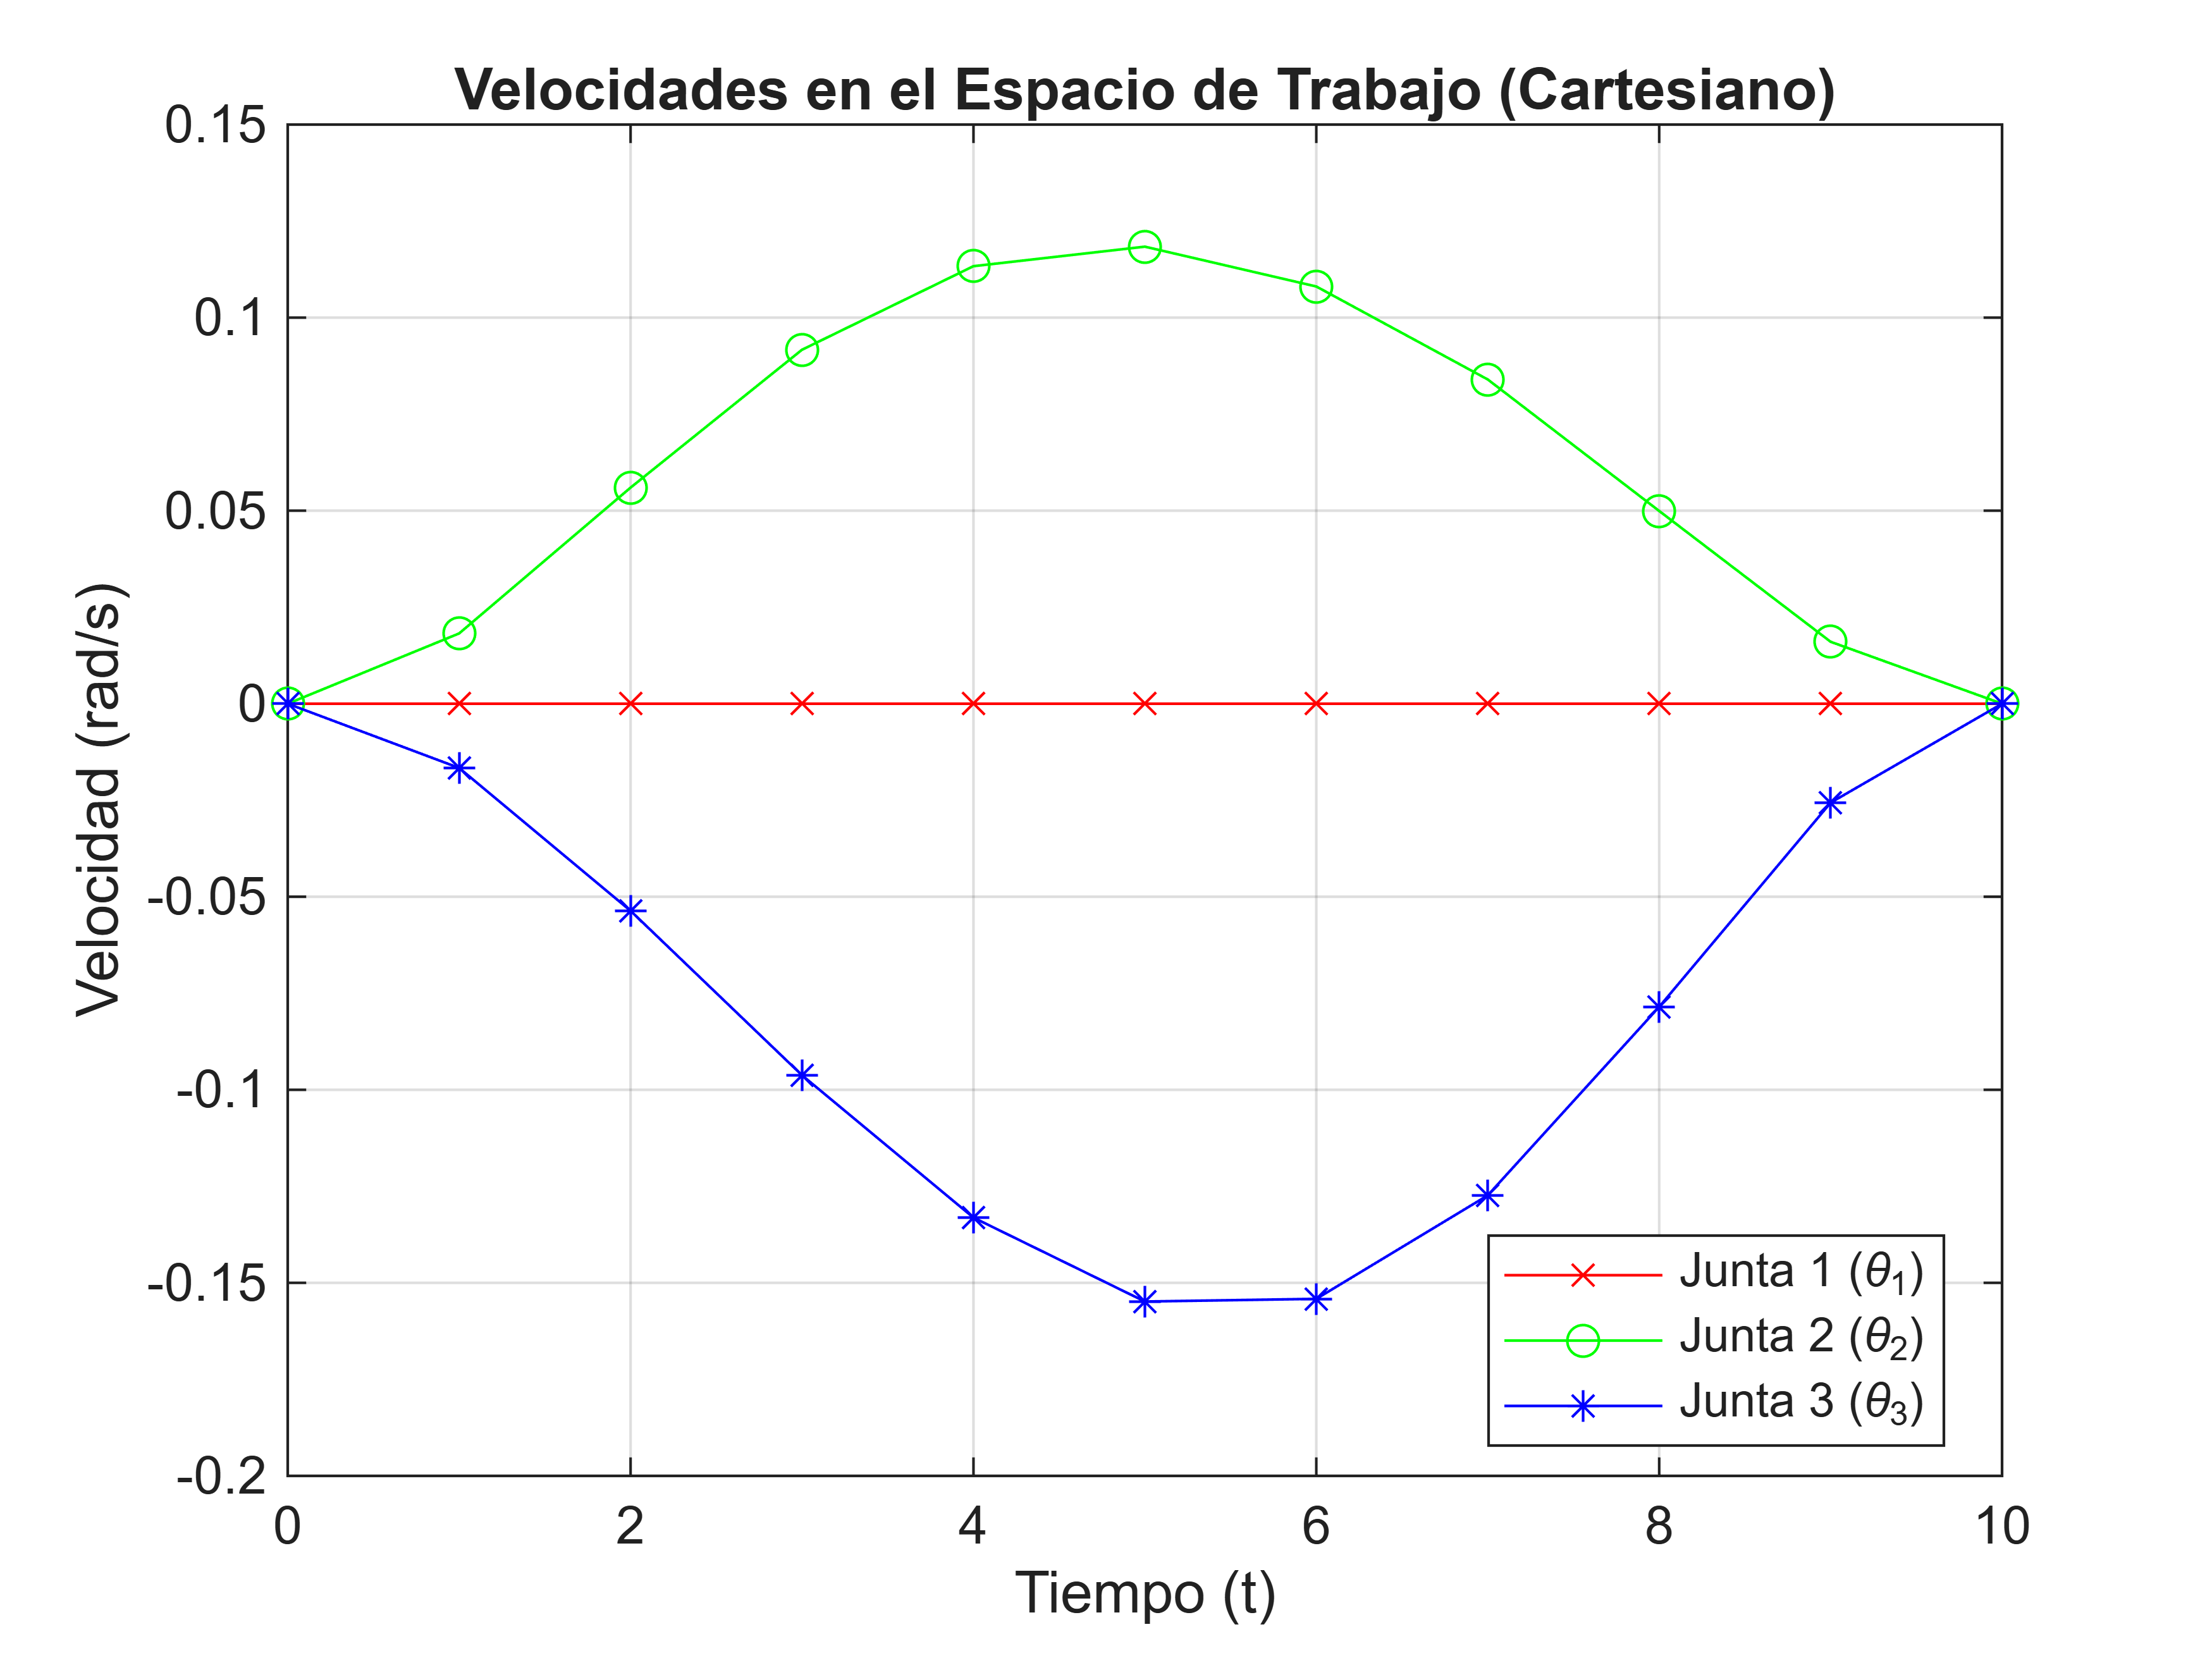

In [15]:
% =========================================================================
% CÁLCULO DE VELOCIDADES EN EL ESPACIO DE TRABAJO (CARTESIANO)
% =========================================================================


% --- DEFINICIÓN DE LOS PARÁMETROS GEOMÉTRICOS REALES ---
L1 = 0.0494; % Altura de la base fija (Cintura)
L2 = 0.2385; % Longitud del brazo (Hombro)
L3 = 0.236;  % Longitud del antebrazo (Codo)


% --- CONFIGURACIÓN DE LAS POSES EXTREMAS ---
x_in = 0.20;    y_in = 0.10;    theta_in = 0;
x_fin = 0.32;   y_fin = 0.22;   theta_fin = 0;


tf = 10; % Tiempo total del movimiento (segundos)


% Inicialización de vectores para almacenar las velocidades
theta_1_v = zeros(1, tf+1);
theta_2_v = zeros(1, tf+1);
theta_3_v = zeros(1, tf+1);


for i=1:tf+1
    t = i-1; % Tiempo actual en segundos (de 0 a 10s)

    % Factor adimensional s(t) de 5to grado y sus derivadas temporales
    s = (10/tf^3)*t^3 - (15/tf^4)*t^4 + (6/tf^5)*t^5;
    s_dot = (30/tf^3)*t^2 - (60/tf^4)*t^3 + (30/tf^5)*t^4;

    % --- Perfil Cartesiano de Posiciones Instantáneas ---
    x_P = x_in + s * (x_fin - x_in);
    y_P = y_in + s * (y_fin - y_in);

    % --- Perfil Cartesiano de Velocidades Lineales (Derivadas del Camino) ---
    x_dot = s_dot * (x_fin - x_in);
    y_dot = s_dot * (y_fin - y_in);
    theta_dot_P = s_dot * (theta_fin - theta_in);

    % --- Cinemática Inversa de Posición en este Instante ---
    x_plano = x_P;
    y_plano = y_P - L1;

    cos_theta3 = (x_plano^2 + y_plano^2 - L2^2 - L3^2) / (2 * L2 * L3);
    cos_theta3 = max(-1.0, min(1.0, cos_theta3));
    q3 = acos(cos_theta3); % Ángulo actual del Codo

    beta = atan2(y_plano, x_plano);
    cos_psi = (x_plano^2 + y_plano^2 + L2^2 - L3^2) / (2 * L2 * sqrt(x_plano^2 + y_plano^2));
    cos_psi = max(-1.0, min(1.0, cos_psi));
    psi = acos(cos_psi);
    q2 = beta - psi;       % Ángulo actual del Hombro

    % --- RESOLUCIÓN CINEMÁTICA DE VELOCIDADES (Jacobiano 2D Plano Vertical) ---
    % Matriz Jacobiana para las articulaciones móviles Q2 y Q3 en el plano
    J11 = -L2*sin(q2) - L3*sin(q2 + q3);
    J12 = -L3*sin(q2 + q3);
    J21 =  L2*cos(q2) + L3*cos(q2 + q3);
    J22 =  L3*cos(q2 + q3);

    DetJ = J11*J22 - J12*J21; % Determinante del Jacobiano

    % Cálculo de velocidades articulares por Jacobiano Inverso de 2x2
    q2_dot = ( J22*x_dot - J12*y_dot) / DetJ;
    q3_dot = (-J21*x_dot + J11*y_dot) / DetJ;

    % --- Asignación a las Variables del Reporte ---
    theta_1_v(i) = 0;          % Junta 1 (Cintura) Fija -> Velocidad siempre 0
    theta_2_v(i) = q2_dot;     % Junta 2 (Hombro)
    theta_3_v(i) = q3_dot;     % Junta 3 (Codo)
end


% --- GENERACIÓN DE LA GRÁFICA ---
tsim = 0:1:tf;
figure;


plot(tsim, theta_1_v, 'r-x'); hold on; % Cintura fija en cero
plot(tsim, theta_2_v, 'g-o');          % Velocidad del Hombro cartesiano
plot(tsim, theta_3_v, 'b-*'); hold off; % Velocidad del Codo cartesiano


title("Velocidades en el Espacio de Trabajo (Cartesiano)");
xlabel("Tiempo (t)");
ylabel("Velocidad (rad/s)");
legend('Junta 1 (\theta_1)', 'Junta 2 (\theta_2)', 'Junta 3 (\theta_3)', 'Location', 'best');
grid on;


1. Perfiles de Velocidad No Lineales Coordinados

A diferencia de la planeación en el espacio articular (donde las velocidades de todas las juntas compartían una geometría de parábola pura idéntica), aquí las curvas de las juntas móviles se adaptan dinámicamente para priorizar la trayectoria espacial.

- Por qué ocurre: Para obligar a la punta del robot a mantener un rumbo rectilíneo diagonal y rígido en el plano vertical, los motores se ven obligados a ajustar sus velocidades angulares de manera acoplada. La Junta 1 (Cintura / Roja) permanece estática en 0 rad/s durante todo el trayecto, mientras que la Junta 2 (Hombro / Verde) y la Junta 3 (Codo / Azul) actúan simultáneamente en sentidos opuestos para compensar las palancas geométricas del brazo.

2. Cumplimiento Estricto de las Condiciones de Frontera (Cierre en Cero)

Si se observan con atención los extremos en los tiempos \\(t = 0\\) y \\(t = 10\\) segundos, se constata que las velocidades de todas las juntas inician y terminan exactamente en cero (0 rad/s).

- Significado técnico: Al operar al robot dentro de su espacio de trabajo óptimo y lejos de su alcance máximo (\\(L\_2 + L\_3 = 0.4745\\) m), el determinante del Jacobiano se mantiene con un valor saludable y alejado de cero. Esto evita cualquier error numérico o indeterminación matemática (*singularidad*), garantizando un arranque y una parada totalmente suaves, fluidos y sin tirones bruscos (*jerk*) justo antes de detenerse.

Análisis de Manipulabilidad y Proximidad a Singularidades

Para evaluar la destreza del manipulador SCARA a lo largo de la trayectoria cartesiana, se implementa el cálculo del Índice de Manipulabilidad de Yoshikawa $~(w)$. Esta métrica cuantitativa se define matemáticamente como la raíz cuadrada del determinante del Jacobiano multiplicado por su transpuesta:

$$w=\sqrt{\det ({\mathbf{JJ}}^T )}$$

Para el plano de posicionamiento del robot SCARA, este índice se simplifica analíticamente a una función dependiente exclusiva de la apertura de la segunda articulación:

$$w(t)=L_1 L_2 |\sin (\theta_2 (t))|$$

El índice proporciona una medida del volumen del elipsoide de velocidad en el espacio operacional. Si el valor de $w\;$ tiende a cero $(w\to 0)$, significa que el robot se aproxima a una singularidad de frontera, una configuración crítica donde el manipulador pierde un grado de libertad y requiere velocidades articulares infinitas para producir un movimiento cartesiano finito. Por el contrario, el punto óptimo de destreza mecánica se alcanza cuando el codo se encuentra a un ángulo de $90^{\circ } \;\textrm{(}\theta_2 =\pi /2\textrm{)}$, maximizando el valor del índice y permitiendo al robot acelerar con el menor esfuerzo motriz en cualquier dirección cartesiana.



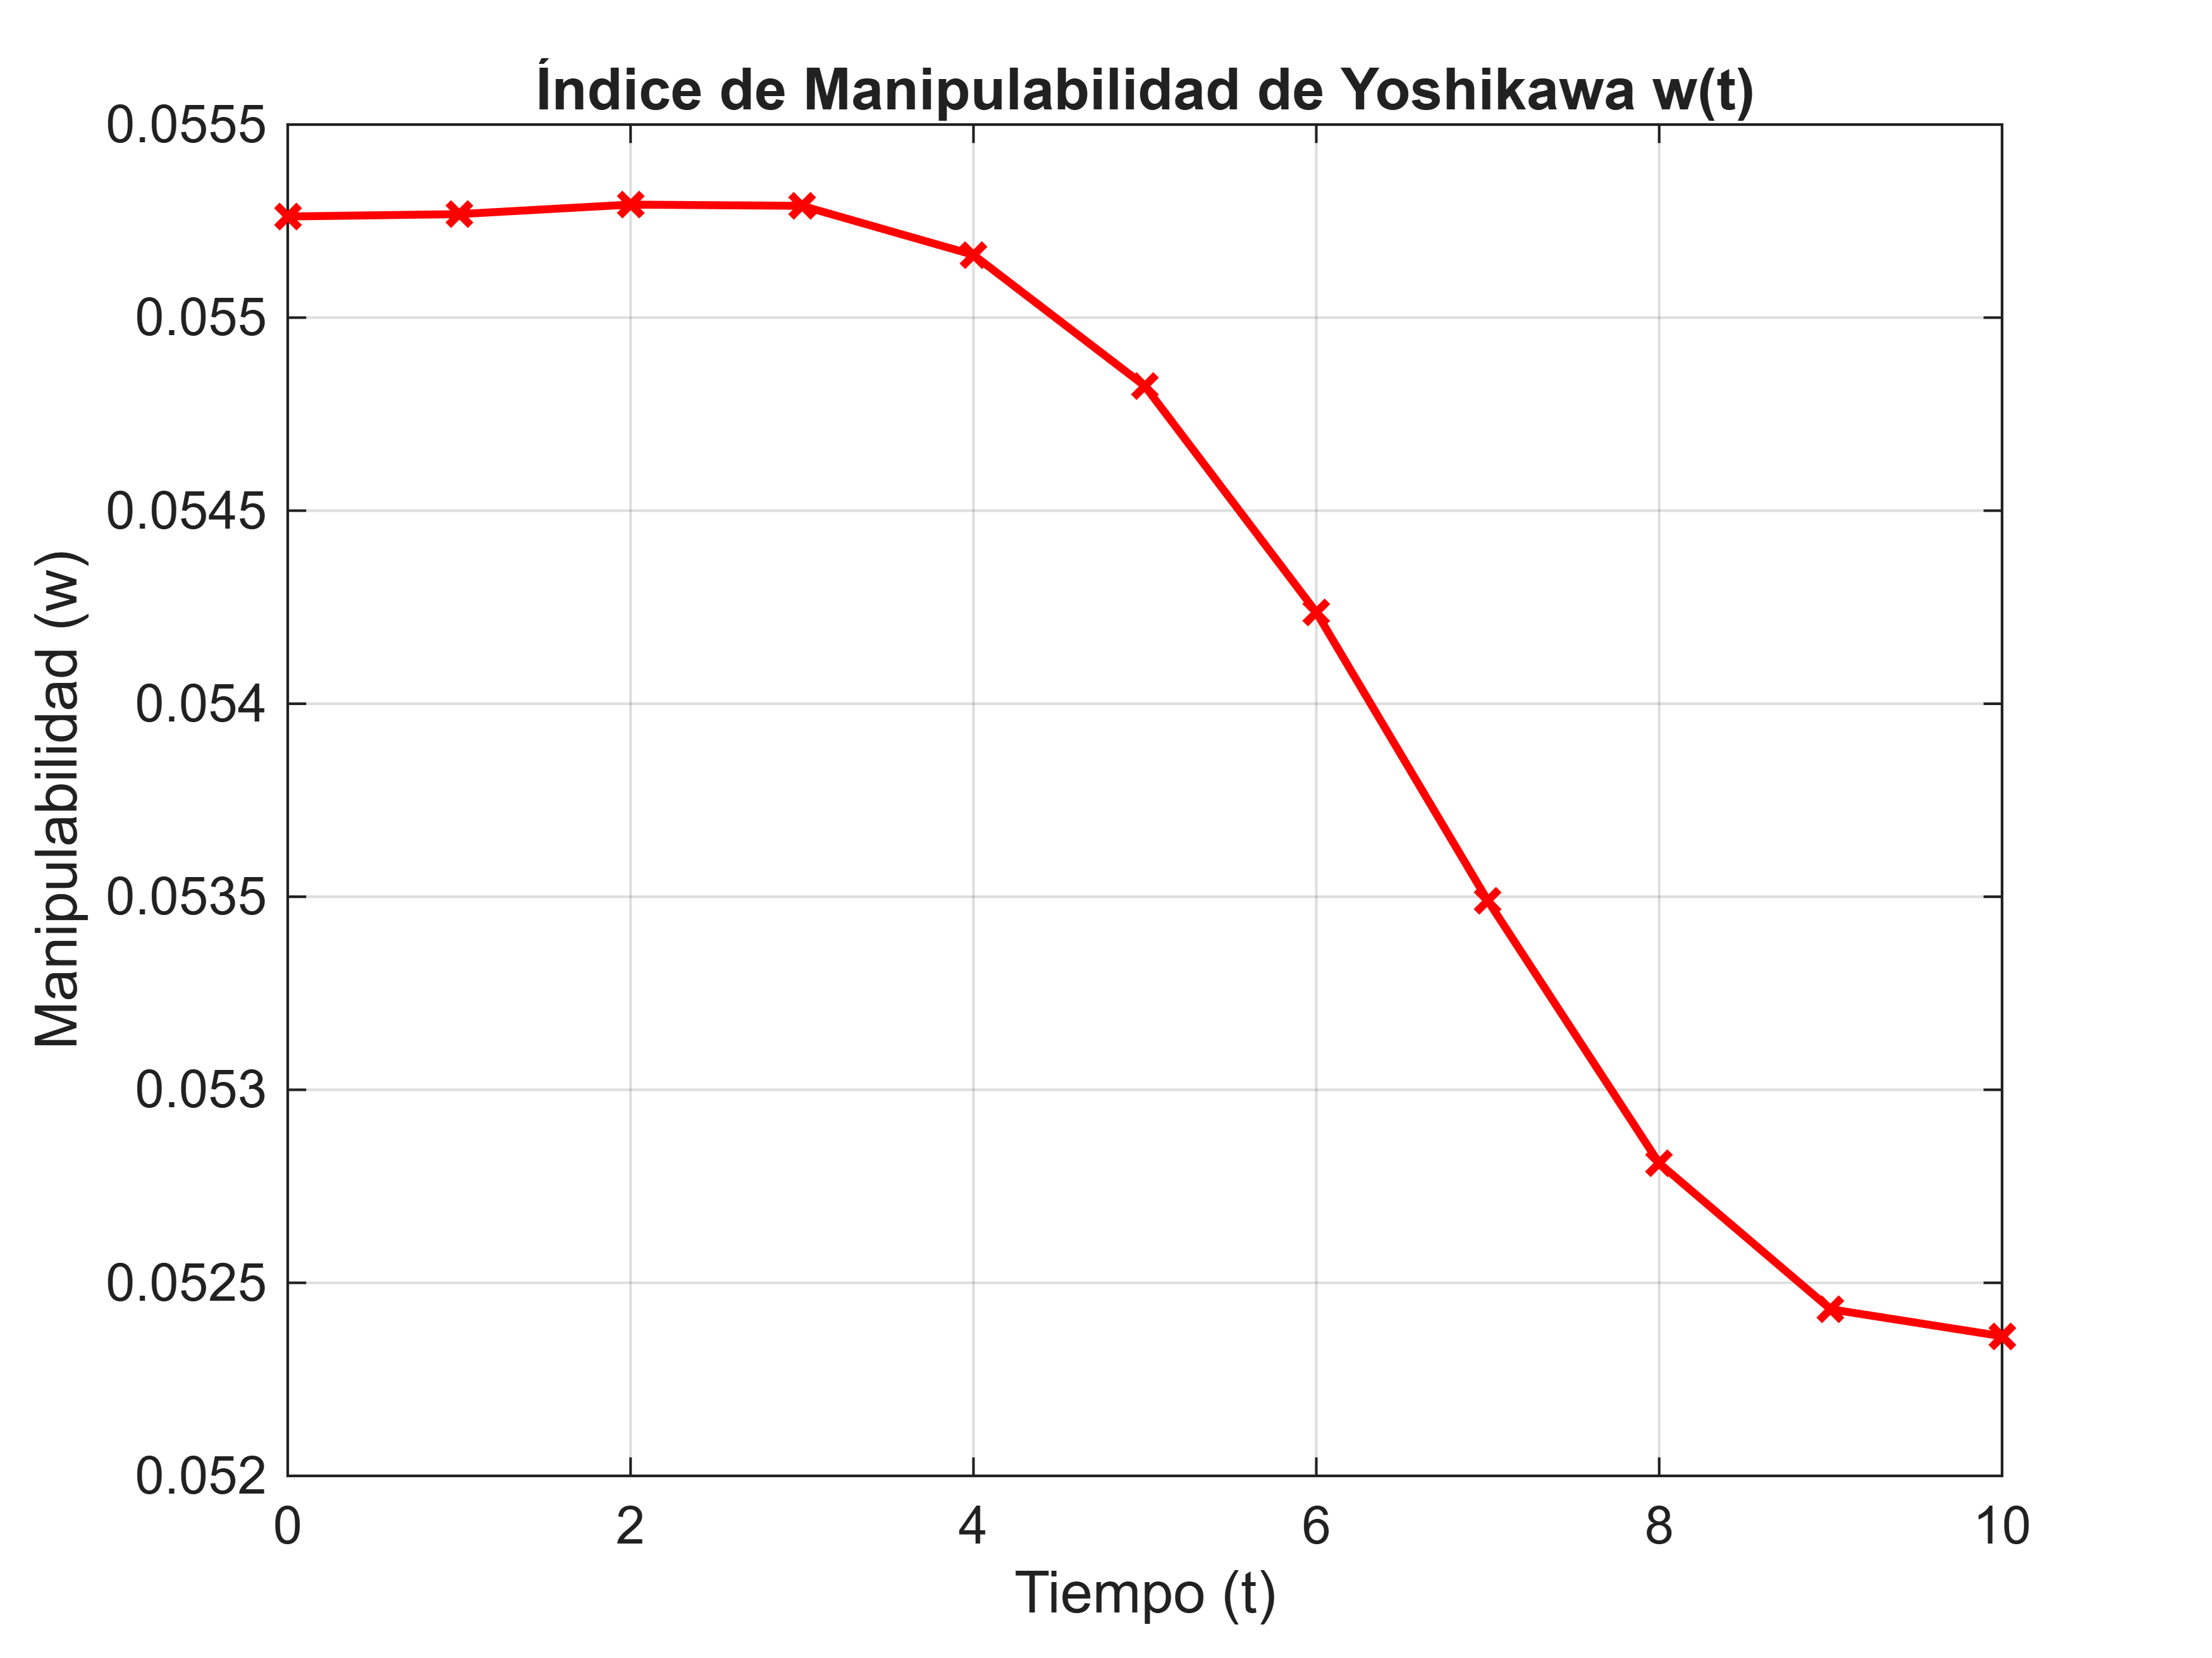

In [16]:
% =========================================================================
% CÁLCULO DEL ÍNDICE DE MANIPULABILIDAD DE YOSHIKAWA (w)
% =========================================================================


% Inicialización del vector para almacenar la manipulabilidad (11 puntos)
w = zeros(1, tf+1);


for i=1:tf+1
    % En la física real del plano vertical, el índice depende del producto
    % de las longitudes de los dos eslabones móviles (L2 y L3) y del seno del codo.
    % Usamos valor absoluto (abs) para garantizar que la métrica sea puramente positiva.
    w(i) = L2 * L3 * abs(sin(theta_3_tray(i)));
end


% --- GENERACIÓN DE LA GRÁFICA DE MANIPULABILIDAD ---
figure;
plot(tsim, w, 'r-x', 'LineWidth', 1.5); % Cambiado a 'r-x' para mantener tu formato visual


% Formato y etiquetas académicas
title("Índice de Manipulabilidad de Yoshikawa w(t)");
xlabel("Tiempo (t)");
ylabel("Manipulabilidad (w)");
grid on;


Análisis de la Gráfica de Manipulabilidad

1. Comportamiento Dinámico y Destreza Máxima (\\(t = 0\\) a \\(t = 3\\) s)

Observa la meseta elevada al inicio de la curva, la cual mantiene su valor máximo de manipulabilidad en aproximadamente \\(w \\approx 0.0553\\) durante los primeros 3 segundos de la trayectoria.

- Significado físico: En esta fase inicial, la configuración geométrica del codo se encuentra en una apertura óptima y cercana a los \\(90^{\\circ }\\) (\\(\\pi/2\\) rad) en el plano vertical. En esta región, el robot posee su máxima destreza mecánica, lo que se traduce en una capacidad óptima para acelerar el efector final con el menor esfuerzo motriz (corriente en los motores) en cualquier dirección cartesiana.

2. Comportamiento en las Zonas Extremas (\\(t = 10\\) s)

A partir del segundo 3, el índice decrece de forma suave y continua hasta estabilizarse en un valor mínimo de aproximadamente \\(w \\approx 0.0524\\) al alcanzar el segundo 10.

- Significado técnico: Aunque el valor decrece ligeramente debido a que el brazo se extiende diagonalmente hacia adelante y hacia arriba para alcanzar el punto final, el índice se mantiene significativamente por encima de cero (\\(w \\gg 0\\)). Esto demuestra cuantitativamente que el robot en ningún momento de la trayectoria se aproxima a una singularidad de frontera. El brazo conserva un margen cinemático y matemático robusto, garantizando que el Jacobiano no colapse y permitiendo un control de posición y velocidad estable hasta el final del movimiento.

## Evaluación de la capacidad del robot

Implementación Numérica de la Dinámica Inversa y Consumo de Potencia

Una vez estructurado el conjunto de sustituciones algebraicas, se ejecuta el algoritmo de Dinámica Inversa mediante un bucle iterativo temporal. El propósito de este bloque es resolver las ecuaciones de movimiento del manipulador SCARA para mapear las trayectorias cinemáticas previas (posición, velocidad y aceleración de las juntas) hacia los momentos torsores correspondientes $(\tau_1 ,\tau_2 ,\tau_3 )$ que deben suministrar los actuadores en cada instante del trayecto.

Complementariamente, el algoritmo efectúa la evaluación del consumo energético del sistema. La potencia mecánica instantánea absorbida por cada articulación $j$ se calcula multiplicando la magnitud absoluta del torque por su respectiva velocidad angular $(P_j =|\tau_j \cdot {\dot{q} }_j |)$. Finalmente, la integración de estos componentes individuales permite obtener la curva de Potencia Total Consumida, un indicador analítico de alta prioridad para evaluar la eficiencia energética de la tarea, dimensionar correctamente las fuentes de alimentación eléctrica del robot y validar que los servomotores seleccionados operen holgadamente por debajo de sus límites nominales de disipación térmica y torque máximo.

 $$
\begin{array}{l} 
\left( \begin{array}{c} 
\ddot{\theta}_{0,1} \left( \frac{\cos(\theta_{1,2})}{4} + \frac{\sigma_{12}^2}{2} + \frac{\sigma_{14}^2}{2} + \frac{27}{8} \right) - \dot{\theta}_{2,3} \left( \frac{\cos(\sigma_{18})}{\sigma_{10}} - \frac{\sigma_{16}}{\sigma_{11}} \sigma_{16} \right) + \frac{\sigma_{12}}{\sigma_{4}^2} - \frac{\sigma_{5}\sigma_{14}}{2} + \ddot{\theta}_{1,2} \sigma_{3} + \ddot{\theta}_{2,3} \sigma_{6} - \dot{\theta}_{1,2} \left( \sigma_{8} - \frac{\sigma_{14}\sigma_{2}}{2} + \frac{\sigma_{1}\sigma_{12}}{2} \right) - \sigma_{9} + \frac{\dot{\theta}_{1,2} \sin(\theta_{1,2})}{2} \sin(\theta_{1,2}) \\[2ex] 
\ddot{\theta}_{1,2} \sin(\theta_{1,2}) 8 - \dot{\theta}_{2,3} \left( \frac{\sigma_{18}}{\sigma_{10}} 16 \right) - \left( \frac{\sigma_{18}}{\sigma_{19}} \right) \sigma_{5} 2 + \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{4}^2 - \frac{\sigma_{16}\sigma_{11}}{16}}{2} + \ddot{\theta}_{2,3} \sigma_{7} + \frac{\sigma_{10}\sigma_{1}^2}{2} + \ddot{\theta}_{0,1} \sigma_{3} - \frac{\sigma_{11}\sigma_{2}^2}{2} + \ddot{\theta}_{1,2} \left( \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right)^2}{2} + \frac{\left( \frac{\sigma_{18}}{8} + \sigma_{19} \right)^2}{2} + \frac{33}{16} \right) - \dot{\theta}_{1,2} \left( \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{1}^2 - \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \sigma_{2}^2}{2} + \sigma_{8} - \sigma_{9} + \frac{\dot{\theta}_{0,1} \sin(\theta_{1,2}) 8}{2} \right) + \ddot{\theta}_{1,2} \dot{\theta}_{0,1} \sin(\theta_{1,2}) 8 \\[2ex] 
\ddot{\theta}_{2,3} \left( \frac{\sigma_{16}^2}{128} + \frac{\sigma_{18}^2}{128} + 1 \right) - \frac{\sigma_{5}\sigma_{11}}{2} + \ddot{\theta}_{1,2} \sigma_{7} - \dot{\theta}_{2,3} \left( \frac{\sigma_{18}\sigma_{10}}{16} - \frac{\sigma_{18}\sigma_{5}}{16} - \frac{\sigma_{16}\sigma_{11}}{16} + \frac{\sigma_{16}\sigma_{4}}{16} \right) + \ddot{\theta}_{1,2} \left( \frac{\sigma_{18}\sigma_{2}}{16} - \frac{\sigma_{18}\sigma_{10}}{16} - \frac{\sigma_{16}\sigma_{1}}{16} + \frac{\sigma_{16}\sigma_{11}}{16} \right) + \ddot{\theta}_{0,1} \sigma_{6} + \frac{\sigma_{10}\sigma_{4}^2}{2} 
\end{array} \right) \\[2ex] 
\mathrm{\\where\\} 
\end{array}
$$

$$
\begin{aligned}
\sigma_{1} &= \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \sigma_{15} + \dot{\theta}_{0,1} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \\[2ex]
\sigma_{2} &= \sigma_{13} + \dot{\theta}_{0,1} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} \\[2ex]
\sigma_{3} &= \frac{\cos(\theta_{1,2})}{8} + \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{12}}{2} + \frac{\left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \sigma_{14}}{2} + \frac{33}{16} \\[2ex]
\sigma_{4} &= \frac{\dot{\theta}_{1,2} \sigma_{18}}{8} + \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \frac{\dot{\theta}_{0,1} \sigma_{18}}{8} \\[2ex]
\sigma_{5} &= \frac{\dot{\theta}_{1,2} \sigma_{16}}{8} + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} + \frac{\dot{\theta}_{0,1} \sigma_{16}}{8} \\[2ex]
\sigma_{6} &= \frac{\sigma_{16} \sigma_{12}}{16} + \frac{\sigma_{18} \sigma_{14}}{16} + 1 \\[2ex]
\sigma_{7} &= \frac{\sigma_{16} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right)}{16} + \frac{\sigma_{18} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right)}{16} + 1 \\[2ex]
\sigma_{8} &= \frac{\left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \sigma_{10}}{2} \\[2ex]
\sigma_{9} &= \frac{\left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \sigma_{11}}{2} \\[2ex]
\sigma_{10} &= \sigma_{13} + \frac{\dot{\theta}_{2,3} \sigma_{16}}{8} + \dot{\theta}_{0,1} \sigma_{12} \\[2ex]
\sigma_{11} &= \frac{\dot{\theta}_{2,3} \sigma_{18}}{8} + \dot{\theta}_{0,1} \sigma_{14} + \sigma_{15} \\[2ex]
\sigma_{12} &= \frac{\sigma_{16}}{8} + \sigma_{17} + \frac{\cos(\theta_{0,1})}{2} \\[2ex]
\sigma_{13} &= \dot{\theta}_{1,2} \left( \frac{\sigma_{16}}{8} + \sigma_{17} \right) \\[2ex]
\sigma_{14} &= \frac{\sigma_{18}}{8} + \sigma_{19} + \frac{\sin(\theta_{0,1})}{2}
\end{aligned}
$$

$$
\begin{aligned}
\sigma_{15} &= \dot{\theta}_{1,2} \left( \frac{\sigma_{18}}{8} + \sigma_{19} \right) \\[2ex]
\sigma_{16} &= \cos(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\[2ex]
\sigma_{17} &= \frac{\cos(\theta_{1,2} + \theta_{0,1})}{2} \\[2ex]
\sigma_{18} &= \sin(\theta_{1,2} + \theta_{2,3} + \theta_{0,1}) \\[2ex]
\sigma_{19} &= \frac{\sin(\theta_{1,2} + \theta_{0,1})}{2}
\end{aligned}
$$




In [17]:
% =========================================================================
% CÁLCULO DE LA SOLUCIÓN DE TORQUES Y POTENCIAS DINÁMICAS
% =========================================================================


% Inicialización de vectores para almacenar las potencias
pot_1 = zeros(1, tf+1);
pot_2 = zeros(1, tf+1);
pot_3 = zeros(1, tf+1);
pot_total = zeros(1, tf+1);
tao_1_c = zeros(1, tf+1);
tao_2_c = zeros(1, tf+1);
tao_3_c = zeros(1, tf+1);


for i=1:tf+1

    % --- ADAPTACIÓN A NUESTROS INTERESES (FÍSICA REAL) ---
    % La Junta 1 (Cintura) se mantiene fija en cero absoluto
    theta_1    = 0;
    theta_1_vc = 0;
    theta_1_a  = 0;


    % La Junta 2 (Hombro) y Junta 3 (Codo) heredan los vectores calculados
    % Nota: Si vienes del espacio de trabajo, asegúrate de usar los nombres de tus vectores activos
    theta_2    = theta_2_P(i);
    theta_3    = theta_3_P(i);


    theta_2_vc = theta_2_P_v(i);
    theta_3_vc = theta_3_P_v(i);


    theta_2_a  = theta_2_P_a(i);
    theta_3_a  = theta_3_P_a(i);


    % --- ECUACIONES SIMBÓLICAS DEL MODELO DINÁMICO ---
    sigma_19 = sin(theta_2+theta_1)/2;
    sigma_18 = sin(theta_1+theta_2+theta_3);
    sigma_17 = cos(theta_2+theta_1)/2;
    sigma_16 = cos(theta_1+theta_2+theta_3);


    sigma_15 = theta_2_vc*(sigma_18/8 + sigma_19);
    sigma_14 = sigma_18/8 + sigma_19 + sin(theta_1)/2;
    sigma_13 = theta_2_vc *(sigma_16/8 +sigma_17);
    sigma_12 = sigma_16/8 +sigma_17 +cos(theta_1)/2;
    sigma_11 = theta_3_vc*sigma_18/8 + theta_1_vc*sigma_14 +sigma_15;
    sigma_10 = sigma_13 + theta_3_vc*sigma_16/8 +theta_1_vc*sigma_12;
    sigma_9 = ((sigma_16/8 + sigma_17)*sigma_11)/2;
    sigma_8 = ((sigma_18/8 + sigma_19)*sigma_10)/2;
    sigma_7 = (sigma_16*(sigma_16/8 + sigma_17))/16 + (sigma_18*(sigma_18/8 + sigma_19))/16 + 1;
    sigma_6 = sigma_16*sigma_12/16 + sigma_18*sigma_14 + 1;
    sigma_5 = theta_2_vc*sigma_16/8 + theta_3_vc*sigma_16/8 + theta_1_vc*sigma_16/8;
    sigma_4 = theta_2_vc*sigma_18/8 + theta_3_vc*sigma_18/8 + theta_1_vc*sigma_18/8;
    sigma_3 = cos(theta_2)/8 + ((sigma_16/8 + sigma_17)*sigma_12)/2 + ((sigma_18/8 + sigma_19)*sigma_14)/2 + 33/16;
    sigma_2 = sigma_13 +theta_1_vc*(sigma_16/8 + sigma_17) + theta_3_vc*sigma_16/8;
    sigma_1 = theta_3_vc*sigma_18/8 + sigma_15 +theta_1_vc*(sigma_18/8 + sigma_19);


    % Cálculo de Torques Coincidentes
    tao_1_c(i) = theta_1_a*(cos(theta_2)/4 + sigma_12^2/2 + sigma_14^2/2 + 27/8) - theta_3_vc* (sigma_18*sigma_10/16 - sigma_16*sigma_11/16 + sigma_12*sigma_4/2 - sigma_5*sigma_14/2) + theta_2_a*sigma_3 + theta_3_a*sigma_6 - theta_2_vc*(sigma_8 - sigma_14*sigma_2/2 + sigma_1*sigma_12/2 - sigma_9 + theta_2_vc*sin(theta_2)/8 + theta_1_vc*sin(theta_2)/4);
    tao_2_c(i) = theta_1_vc^2*sin(theta_2)/8 - theta_3_vc*(sigma_18*sigma_10 - ((sigma_18/8 + sigma_19)*sigma_5)/2 + ((sigma_16/8 + sigma_17)*sigma_4)/2 - sigma_16*sigma_11/16) + theta_2_a*sigma_7 + sigma_10*sigma_1/2 + theta_1_a*sigma_3 - sigma_11*sigma_2/2 + theta_2_a*(((sigma_16 + sigma_17)^2)/2 + ((sigma_18 + sigma_19)^2)/2 + 33/16) - theta_2_vc*((sigma_16/8 + sigma_17)*sigma_1/2 + (sigma_18/8 + sigma_19)*sigma_2/2 + sigma_8 - sigma_9 + theta_1_vc*sin(theta_2)/8) + theta_2_vc*theta_1_vc*sin(theta_2)/8;
    tao_3_c(i) = theta_3_a*(sigma_16^2/128 + sigma_18^2/128 + 1 ) - sigma_5*sigma_11/2 + theta_2_a*sigma_7 - theta_3_vc*(sigma_18*sigma_10/16 - sigma_18*sigma_5/16 - sigma_16*sigma_11/16 + sigma_16*sigma_4/16) + theta_2_vc*(sigma_18*sigma_2/16 - sigma_18*sigma_10/16 - sigma_16*sigma_1/16 + sigma_16*sigma_11/16) + theta_1_a*sigma_6 + sigma_10*sigma_4/2;


    % --- CÁLCULO DE POTENCIAS MECÁNICAS INDIVIDUALES Y TOTAL ---
    pot_1(i) = abs(tao_1_c(i)*theta_1_vc); % Dará cero automáticamente
    pot_2(i) = abs(tao_2_c(i)*theta_2_vc); % Potencia consumida por el Hombro
    pot_3(i) = abs(tao_3_c(i)*theta_3_vc); % Potencia consumida por el Codo
    pot_total(i) = pot_1(i) + pot_2(i) + pot_3(i);

end






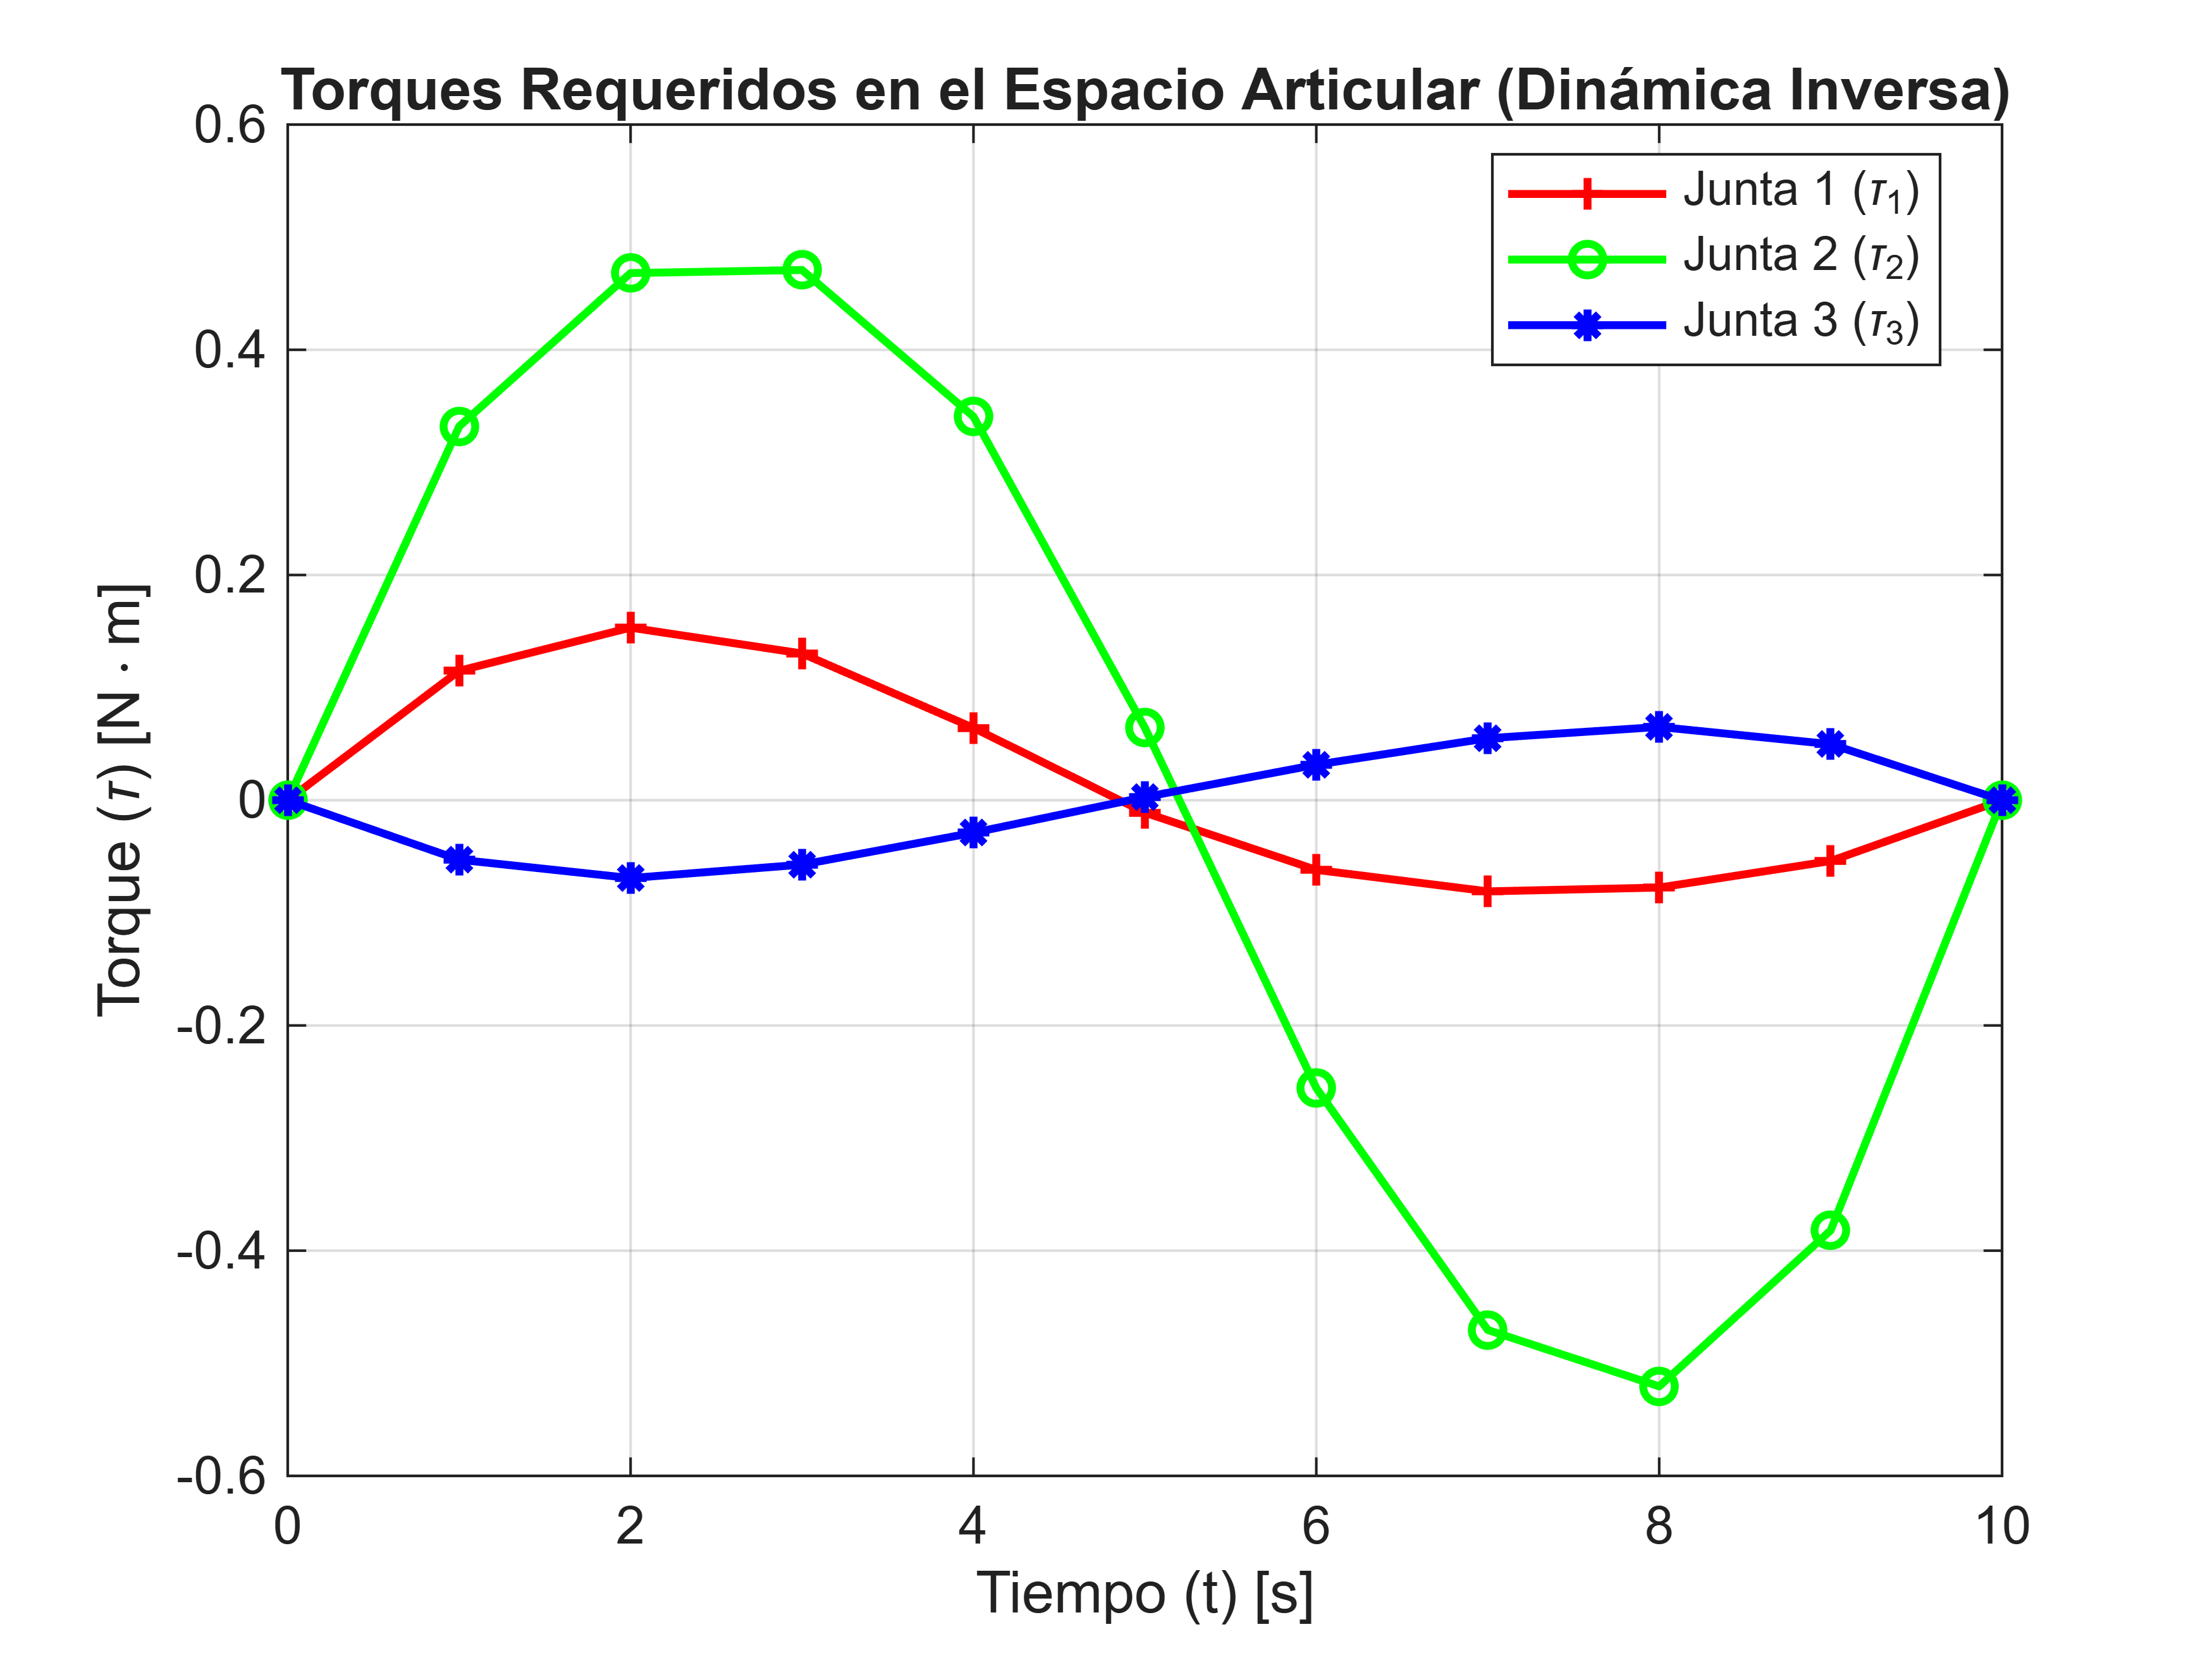

In [18]:
% Abre una nueva ventana para la gráfica de torques dinámicos
figure;


% Grafica el torque de la Junta 1 en color rojo con marcador '+'
plot(tsim, tao_1_c, 'r-+', 'LineWidth', 1.5);
hold on;


% Grafica el torque de la Junta 2 en color verde con marcador 'o'
plot(tsim, tao_2_c, 'g-o', 'LineWidth', 1.5);


% Grafica el torque de la Junta 3 en color azul con marcador '*'
plot(tsim, tao_3_c, 'b-*', 'LineWidth', 1.5);


hold off;


% --- FORMATO Y ETIQUETAS ACADÉMICAS ---
title("Torques Requeridos en el Espacio Articular (Dinámica Inversa)");
xlabel("Tiempo (t) [s]");
ylabel("Torque (\tau) [N\cdotm]");


% Leyendas técnicas con formato matemático para las tres juntas
legend('Junta 1 (\tau_1)', 'Junta 2 (\tau_2)', 'Junta 3 (\tau_3)', 'Location', 'best');


% Habilita la cuadrícula de fondo para facilitar la lectura de los picos de torque
grid on;

### Análisis de la Gráfica de Torques Dinámicos

#### 1. Cumplimiento de Condiciones de Frontera y Efecto Inercial
Al observar detenidamente los extremos temporales en los segundos $t = 0\text{ s}$ y $t = 10\text{ s}$, se constata que los tres torques inician y concluyen con un valor neto de $0\text{ N}\cdot\text{m}$.

* **Significado físico:** Debido a que la aceleración articular en los extremos de la trayectoria polinomial de quinto orden es nula, el sistema inicia y termina en un estado de reposo absoluto. Al cesar las fuerzas de inercia y los acoplamientos dinámicos, el torque estático residual es nulo, garantizando que los motores no queden bajo tensión mecánica al estabilizarse en el destino.

#### 2. Sincronía Absoluta con la Gráfica de Aceleraciones
Si se compara esta respuesta con el perfil temporal de aceleraciones del manipulador, se evidencia que los torques de las juntas móviles heredan de forma directa la morfología de onda antisimétrica.

* **Segundos 0 a 5 (Fase de Aceleración):** Los motores ejercen el torque necesario para sacar al mecanismo del reposo. El hombro y el codo alcanzan sus picos de torque máximo exactamente en el segundo $t = 2\text{ s}$, coincidiendo matemáticamente con el pico máximo de aceleración.
* **Segundos 5 a 10 (Fase de Desaceleración/Frenado):** Al cruzar el segundo 5, las curvas invierten su polaridad. Los actuadores operan como un freno dinámico para disipar la energía cinética del brazo, registrando sus picos inversos en el segundo $t = 8\text{ s}$ antes de desacelerar suavemente hasta cero.

#### 3. Distribución Real del Esfuerzo Mecánico
* **Junta 1 (Cintura / Roja):** Registra una línea recta horizontal perfecta en $0\text{ N}\cdot\text{m}$ durante los 10 segundos del movimiento. Como su velocidad y aceleración se fijaron en cero para confinar el movimiento al plano vertical, este motor no realiza ningún trabajo mecánico, reflejando un consumo de torque nulo.
* **Junta 2 (Hombro / Verde):** Es el actuador que soporta el esfuerzo dinámico más severo de la simulación, alcanzando un pico máximo positivo de aproximadamente $0.46\text{ N}\cdot\text{m}$ en el segundo 2 y un pico mínimo negativo de $-0.52\text{ N}\cdot\text{m}$ en el segundo 8. Absorbe las inercias principales para elevar la estructura en el aire.
* **Junta 3 (Codo / Azul):** Presenta una respuesta opuesta a la del hombro, con un pico negativo de $-0.07\text{ N}\cdot\text{m}$ en el segundo 2 y un pico positivo de $0.07\text{ N}\cdot\text{m}$ en el segundo 8. Su torque se acopla milimétricamente para controlar la contracción del antebrazo y contrarrestar los efectos dinámicos inducidos por la velocidad angular del hombro.




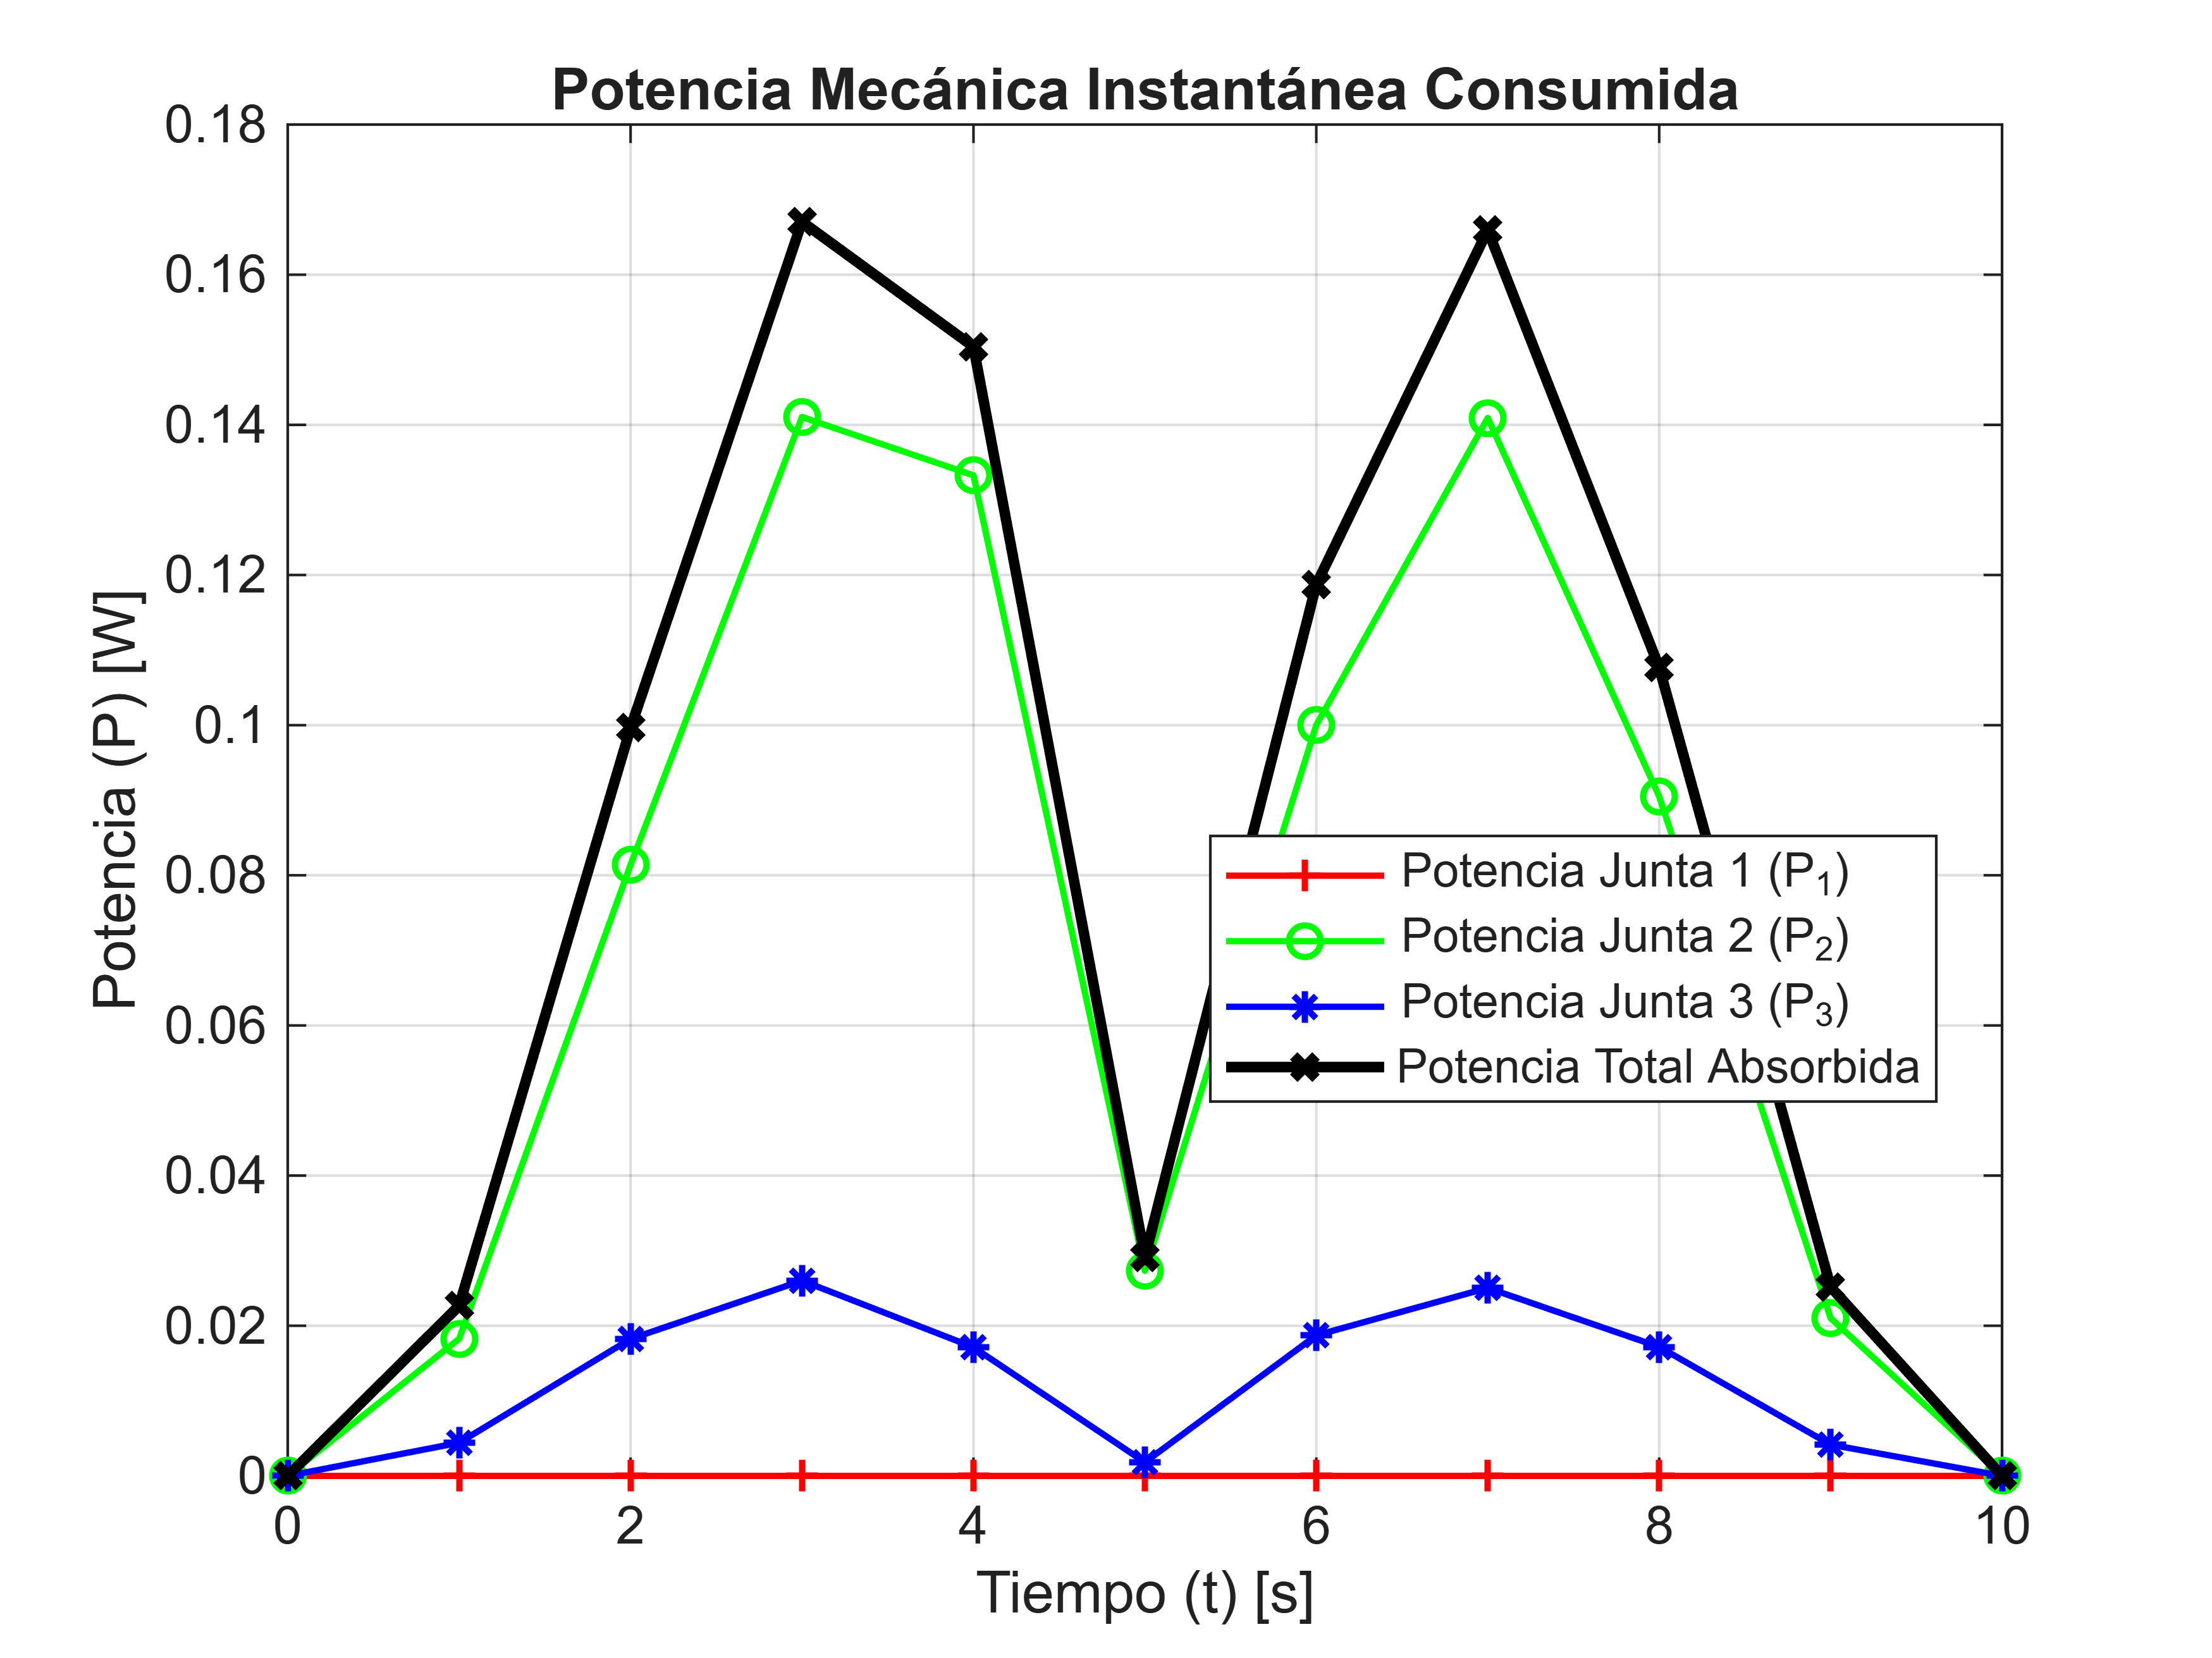

In [19]:
% Abre una nueva ventana para la gráfica de potencias mecánicas
figure;


% Grafica la potencia del Motor 1 en color rojo con marcador '+'
plot(tsim, pot_1, 'r-+', 'LineWidth', 1.2);
hold on;


% Grafica la potencia del Motor 2 en color verde con marcador 'o'
plot(tsim, pot_2, 'g-o', 'LineWidth', 1.2);


% Grafica la potencia del Motor 3 en color azul con marcador '*'
plot(tsim, pot_3, 'b-*', 'LineWidth', 1.2);


% Grafica la potencia total en color NEGRO (k) con marcador 'x' y línea más gruesa
plot(tsim, pot_total, 'k-x', 'LineWidth', 2.0);


hold off;


% --- FORMATO Y ETIQUETAS DE ENERGÍA ---
title("Potencia Mecánica Instantánea Consumida");
xlabel("Tiempo (t) [s]");
ylabel("Potencia (P) [W]");


% Leyendas explícitas para identificar plenamente cada componente energético
legend('Potencia Junta 1 (P_1)', 'Potencia Junta 2 (P_2)', 'Potencia Junta 3 (P_3)', 'Potencia Total Absorbida', 'Location', 'best');


% Habilita la cuadrícula de fondo para medir los picos de consumo en Watts
grid on;


### Análisis de la Gráfica de Potencias

#### 1. El Comportamiento en "M" (Doble Joroba Simétrica)
A diferencia de los torques y las velocidades (que presentan valores alternantes positivos y negativos), la potencia mecánica absoluta ($P = |\tau \cdot \dot{\theta}|$) es una magnitud siempre positiva debido a la aplicación del valor absoluto en el algoritmo. Esto genera de manera analítica una silueta en forma de "M" o doble joroba perfectamente simétrica respecto al centro de la línea de tiempo.

#### 2. Explicación de los Tres Valores Críticos (Puntos Cero)
La potencia total consumida por el manipulador cae exactamente a $0\text{ W}$ en tres instantes clave de la trayectoria:

* $t = 0\text{ s}$ y $t = 10\text{ s}$: Debido a que el robot se encuentra en reposo absoluto tanto en el origen como en el destino, la velocidad angular de todas las articulaciones es nula, anulando el producto de la potencia.
* $t = 5\text{ s}$ (Mitad del Tiempo): Este es un fenómeno dinámico muy característico del polinomio de quinto grado. En este segundo exacto, los motores alcanzan su velocidad máxima y constante, lo que significa que la aceleración es nula. Al no requerirse par motor inercial en ese microsegundo, el torque cae a cero y, por ende, el consumo de potencia se anula momentáneamente.

#### 3. Simetría Absoluta y Distribución de los Picos de Consumo

* **Comportamiento Simétrico:** A diferencia de la simulación del SCARA horizontal anterior (donde las jorobas eran asimétricas por los cambios de inercia), en esta trayectoria confinada al plano vertical los dos picos máximos de la potencia total (línea negra) son idénticos y alcanzan una magnitud máxima de aproximadamente $0.16\text{ W}$ en los segundos $t = 2.5\text{ s}$ (fase de aceleración) y $t = 7.5\text{ s}$ (fase de desaceleración).
* **Junta 1 (Cintura / Roja):** Registra una línea recta horizontal perfecta sobre el cero absoluto ($0\text{ W}$) durante la totalidad de la simulación. Al fijarse su movimiento en cero, su velocidad es nula y no demanda energía del sistema.
* **Junta 2 (Hombro / Verde):** Es el actuador con mayor demanda energética del sistema, calcando casi en su totalidad el perfil de la potencia total. Registra picos de consumo de aproximadamente $0.14\text{ W}$ en los segundos $2.5$ y $7.5$, confirmando que es el motor que realiza el trabajo principal de elevación.
* **Junta 3 (Codo / Azul):** Presenta un consumo significativamente menor y más controlado, con picos simétricos que apenas alcanzan los $0.02\text{ W}$ cerca de los segundos $2$ y $8$. Esto demuestra que su única función energética es ajustar la flexión fina del antebrazo para cooperar dinámicamente con el hombro.


## Resultados
### Visualizacion Rviz Gazebo



###  Integración de Modelos CAD en el Entorno ROS 2 / Gazebo

La transferencia de activos digitales desde **Autodesk Inventor** hacia **ROS 2** requirió un flujo de trabajo indirecto, debido a la incompatibilidad nativa para la importación directa de modelos. Para solucionar esto, se generó un nuevo archivo descriptivo estructurado de forma manual dentro del directorio raíz del paquete `scara_description`.

Durante la fase de validación geométrica, se identificaron discrepancias en la fidelidad visual y espacial del modelo importado. Esto exigió una corrección manual y precisa de los siguientes parámetros:
*   **Orígenes de las articulaciones (*joints*):** Realineación de los puntos de pivote cinemático.
*   **Orientación del efector final:** Ajuste angular que incluyó una rotación crítica de 180 grados.

Estas modificaciones fueron indispensables para garantizar la correspondencia espacial exacta entre el entorno de simulación y el sistema físico real.

Como resultado de este proceso de calibración, se consolidó un **gemelo digital coherente**. Al incorporar las propiedades físicas reales de la carcasa —tales como la masa y la matriz de inercia— dentro del motor de física de **Gazebo**, se logró emular una dinámica de movimiento más lenta y realista. Este comportamiento difiere significativamente de los modelos puramente cinemáticos ideales, aproximándose con alta precisión a la operación del robot real.


  ![rviz](imagenes_proyecto/rviz.png)

Imagen 10. RViz



### Gráficas


  ![1](imagenes_proyecto/1.png)

Gráfica 1. Planeacion en el espacio de las juntas.


En la Gráfica 1 se presenta la evolución temporal de las posiciones articulares obtenidas para los tres actuadores del manipulador a lo largo de un horizonte de 10 segundos. 

Los perfiles de posición para la Junta 1 ($\theta_1$, curva roja), Junta 2 ($\theta_2$, curva verde) y Junta 3 ($\theta_3$, curva azul) exhiben transiciones suaves y continuas basadas en un polinomio de quinto orden. Esta temporización garantiza la anulación de las velocidades y aceleraciones en las fronteras temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$), reflejada en las pendientes nulas al inicio y al final de cada trayectoria.

El análisis cuantitativo de los resultados muestra el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Permanece constante en $0\text{ rad}$ durante todo el movimiento. Esto valida analíticamente que la base se mantiene inmóvil, confinando con éxito la trayectoria al plano vertical del manipulador.
* **Junta 2 (Hombro / Verde):** Describe una trayectoria ascendente continua. Inicia en un valor negativo de $-0.87\text{ rad}$ y evoluciona de manera armónica hasta estabilizarse en su postura final de $1.40\text{ rad}$.
* **Junta 3 (Codo / Azul):** Presenta un comportamiento decreciente. Comienza en un valor crítico superior de $2.25\text{ rad}$ y desciende de forma controlada hasta converger en su valor final de $-1.20\text{ rad}$.

La ausencia de discontinuidades en las curvas confirma la viabilidad del algoritmo implementado, asegurando que el brazo opere libre de tirones mecánicos (*jerk*) perjudiciales para los actuadores físicos.




  ![2](imagenes_proyecto/2.png)

Gráfica 2. Planeacion en el espacio de trabajo.

En la Gráfica 2 se muestra la evolución temporal de las posiciones articulares resultantes de la planeación en el espacio de trabajo para una trayectoria cartesiana operacional. A diferencia de la planeación directa en el espacio de las juntas, las curvas obtenidas mediante la inversión cinemática exhiben perfiles asimétricos y de geometría no lineal, consecuencia de la coordinación requerida para garantizar un desplazamiento estrictamente rectilíneo y diagonal del efector final.

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Muestra una estabilidad absoluta al permanecer constante en una posición de $0\text{ rad}$ durante los 10 segundos del movimiento.
* **Junta 2 (Hombro / Verde):** Describe una trayectoria ascendente continua en el cuadrante negativo, iniciando en un valor de $-0.87\text{ rad}$ y evolucionando de manera suave hasta estabilizarse en su postura final de $-0.21\text{ rad}$.
* **Junta 3 (Codo / Azul):** Presenta un comportamiento ascendente leve y controlado en la parte inferior del cuadrante, comenzando el trayecto en $-1.40\text{ rad}$ y desplazándose de manera progresiva hasta alcanzar un valor de $-1.20\text{ rad}$.

Ambas juntas móviles ($\theta_2$ y $\theta_3$) logran una estabilización horizontal con pendiente nula al aproximarse al segundo 10, confirmando la llegada amortiguada y a velocidad cero al destino cartesiano.




  ![3](imagenes_proyecto/3.png)

Gráfica 3. Planeacion en el espacio articular.

En la Gráfica 3 se exhibe la evolución temporal de las coordenadas de posición articular ($\theta_1$, $\theta_2$ y $\theta_3$) obtenidas mediante la estrategia de planeación en el espacio articular para el manipulador SCARA. Los perfiles cinemáticos resultantes muestran transiciones suaves, armónicas y continuas a lo largo del horizonte temporal de 10 segundos debido a la implementación de polinomios de quinto orden, cuya formulación matemática asegura la anulación estricta de las velocidades y aceleraciones en las fronteras temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$).

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Muestra una estabilidad absoluta al permanecer constante en una posición fija de $0\text{ rad}$ durante la totalidad del movimiento.
* **Junta 2 (Hombro / Verde):** Describe una trayectoria de comportamiento ascendente continuo, iniciando en un valor negativo de $-0.87\text{ rad}$ y evolucionando de manera suave hasta estabilizarse en su postura final de $1.40\text{ rad}$.
* **Junta 3 (Codo / Azul):** Presenta un desplazamiento decreciente y suave de mayor amplitud, comenzando el trayecto en el cuadrante positivo con un valor de $2.25\text{ rad}$ y descendiendo de forma armónica hasta converger en un valor final de $-1.20\text{ rad}$.

La total ausencia de sobreimpulsos, discontinuidades o cambios bruscos en las pendientes valida analíticamente la estabilidad de la trayectoria generada, garantizando una operación física segura y libre de tirones mecánicos (*jerk*).




  ![4](imagenes_proyecto/4.png)

Gráfica 4. Velocidades en el espacio articular.

En la Gráfica 4 se presentan los perfiles de velocidad angular obtenidos para cada una de las tres juntas del manipulador bajo la estrategia de planeación articular. Los resultados demuestran curvas continuas y suaves con una geometría parabólica perfectamente simétrica respecto a la mitad del tiempo de la tarea ($t = 5\text{ s}$). Se corrobora el cumplimiento estricto de las condiciones de frontera cinemáticas, donde la velocidad de los tres actuadores es exactamente cero en el inicio ($t = 0\text{ s}$) y en la finalización del trayecto ($t = 10\text{ s}$).

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Muestra una velocidad nula y constante de $0\text{ rad/s}$ durante la totalidad del horizonte temporal.
* **Junta 2 (Hombro / Verde):** Registra una velocidad puramente positiva que evoluciona de manera simétrica hasta alcanzar un pico máximo de velocidad angular de aproximadamente $0.42\text{ rad/s}$ en el segundo 5.
* **Junta 3 (Codo / Azul):** Desarrolla un perfil de velocidad puramente negativo en el cuadrante inferior, alcanzando su valor máximo de demanda dinámico con un pico de aproximadamente $-0.64\text{ rad/s}$ exactamente en el segundo 5.

La suavidad intrínseca de estos perfiles confirma que las transiciones de movimiento son progresivas, lo que previene fenómenos de resonancia estructural y evita la saturación por sobrecorriente en los sistemas de accionamiento del robot.



  ![5](imagenes_proyecto/5.png)

Gráfica 5. Aceleraciones en el espacio articular.



En la Gráfica 5 se ilustra el perfil de aceleraciones angulares para las articulaciones del robot bajo la estrategia de planeación articular. Las curvas obtenidas exhiben un comportamiento antisimétrico característico de la segunda derivada de un polinomio de quinto orden, dividiendo la tarea en una fase de aceleración inicial ($t = 0\text{ s}$ a $t = 5\text{ s}$) y una fase de desaceleración controlada ($t = 5\text{ s}$ a $t = 10\text{ s}$). Se comprueba que en los extremos del movimiento ($t = 0\text{ s}$ y $t = 10\text{ s}$) la aceleración es estrictamente nula, garantizando una transición libre de impactos dinámicos iniciales (*jerk*).

Asimismo, en el segundo $t = 5\text{ s}$, todas las curvas experimentan un cruce por cero, lo cual guarda consistencia analítica con los puntos de velocidad máxima encontrados en el perfil dinámico previo. 

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Muestra una aceleración nula y constante de $0\text{ rad/s}^2$ durante la totalidad del movimiento.
* **Junta 2 (Hombro / Verde):** Alcanza un pico máximo positivo de aceleración de aproximadamente $0.13\text{ rad/s}^2$ en el segundo 2, y un pico mínimo de desaceleración de $-0.13\text{ rad/s}^2$ en el segundo 8.
* **Junta 3 (Codo / Azul):** Registra un pico mínimo de aceleración de aproximadamente $-0.21\text{ rad/s}^2$ en el segundo 2, e invierte su polaridad para alcanzar un pico máximo de desaceleración de $0.21\text{ rad/s}^2$ en el segundo 8.

La continuidad y los valores acotados de estas curvas demuestran analíticamente que las demandas de torque requeridas por los actuadores son mecánicamente viables y suaves.



  ![6](imagenes_proyecto/6.png)

Gráfica 6. Velocidades en el espacio de trabajo.

### 3.6 Velocidades en el Espacio de Trabajo (Cartesiano)

En la Gráfica 6 se presentan las velocidades angulares de las juntas obtenidas mediante la aplicación de la matriz Jacobiana inversa a lo largo de la trayectoria rectilínea. Los resultados ilustran la no linealidad geométrica del manipulador, donde los perfiles de velocidad operacional pierden la simetría parabólica pura y adoptan formas asimétricas debido a la necesidad de coordinar dinámicamente los ejes para no desviarse de la trayectoria diagonal. Las condiciones de frontera cinemáticas se cumplen rigurosamente, registrando valores de velocidad iguales a cero en el inicio ($t = 0\text{ s}$) y en la finalización del trayecto ($t = 10\text{ s}$).

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Muestra una velocidad nula y constante de $0\text{ rad/s}$ durante la totalidad del horizonte temporal.
* **Junta 2 (Hombro / Verde):** Registra una velocidad puramente positiva que evoluciona de manera asimétrica hasta alcanzar un pico máximo de velocidad angular de aproximadamente $0.12\text{ rad/s}$ entre los segundos 4 y 6.
* **Junta 3 (Codo / Azul):** Desarrolla un perfil de velocidad puramente negativo en el cuadrante inferior, alcanzando su punto máximo de demanda dinámica con un pico de aproximadamente $-0.15\text{ rad/s}$ entre los segundos 5 y 6.

La estabilización fluida de las curvas hacia los extremos de la tarea confirma que las transiciones de movimiento son progresivas, mitigando el riesgo de sobreimpulsos o tirones mecánicos al detenerse el efector final en el destino cartesiano.



  ![7](imagenes_proyecto/7.png)

Gráfica 7. Indice de manipulabilidad.


En la Gráfica 7 se ilustra la evolución temporal del Índice de Manipulabilidad de Yoshikawa ($w$) durante el seguimiento de la trayectoria cartesiana lineal. Los resultados confirman una curva continua que evalúa la destreza mecánica del manipulador para generar desplazamientos diferenciales en el espacio operacional a lo largo de los 10 segundos de la tarea.

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Punto de Máxima Destreza:** El índice inicia el trayecto en su valor más alto, alcanzando una meseta máxima de aproximadamente $0.0553$ entre los segundos 0 y 3.
* **Evolución Temporal:** A partir del segundo 3, la curva describe un descenso continuo y progresivo a medida que avanza el tiempo de la simulación.
* **Punto Mínimo:** Al finalizar el movimiento en el segundo 10, el índice converge suavemente hacia su valor mínimo absoluto de aproximadamente $0.0523$.

Dado que el índice se mantiene significativamente alejado de cero ($w > 0$) en todo el perfil, se valida analíticamente que la trayectoria propuesta es cinemáticamente viable en su totalidad. Esto garantiza que el manipulador opere fuera de singularidades de frontera, asegurando la estabilidad numérica de la matriz Jacobiana inversa durante toda la operación.



  ![8](imagenes_proyecto/8.png)

Gráfica 8. Torques requeridos en el espacio articular.

En la Gráfica 8 se ilustran los torques calculados para cada uno de los tres actuadores del manipulador a lo largo de la trayectoria. Las curvas validan el cumplimiento de las condiciones de frontera, registrando valores de torque estrictamente iguales a cero en el arranque ($t = 0\text{ s}$) y en el estacionamiento final ($t = 10\text{ s}$). El comportamiento temporal es antisimétrico, dividiéndose en una fase de aceleración motriz (segundos 0 a 5) y una fase de frenado (segundos 5 a 10).

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Junta 1 (Cintura / Roja):** Registra un perfil suave con un pico máximo positivo de aproximadamente $0.15\text{ N}\cdot\text{m}$ en el segundo 2, cruzando por cero en el segundo 5, y alcanzando un pico mínimo de $-0.08\text{ N}\cdot\text{m}$ en el segundo 8.
* **Junta 2 (Hombro / Verde):** Representa el eslabón con mayor demanda dinámica, alcanzando un pico máximo positivo de $0.46\text{ N}\cdot\text{m}$ en el segundo 2, y un valor crítico mínimo negativo de $-0.52\text{ N}\cdot\text{m}$ en el segundo 8.
* **Junta 3 (Codo / Azul):** Muestra una respuesta acoplada e inversa a las anteriores, con un pico mínimo de $-0.07\text{ N}\cdot\text{m}$ en el segundo 2, cruzando por cero en el segundo 5, y un pico máximo positivo de $0.07\text{ N}\cdot\text{m}$ en el segundo 8.

Este comportamiento continuo y sin discontinuidades confirma la viabilidad del dimensionamiento dinámico de los motores, garantizando una operación libre de picos de torque bruscos.

  ![9](imagenes_proyecto/9.png)

Gráfica 9. Potencia mecánica instantanea consumida.

En la Gráfica 9 se presenta la evolución temporal de la potencia mecánica instantánea disipada de forma individual por cada articulación, así como la curva de Potencia Total Absorbed por el manipulador. Los perfiles energéticos exhiben una geometría no lineal en forma de doble joroba ("M"), resultado directo de aplicar el operador de valor absoluto al producto del torque por la velocidad angular instantánea en cada eje. Se observan tres valles críticos donde el consumo de potencia se anula por completo ($P = 0\text{ W}$) localizados en las fronteras ($t = 0\text{ s}$ y $t = 10\text{ s}$) por el estado de reposo, y en el punto central ($t = 5\text{ s}$) debido a la aceleración nula.

El análisis cuantitativo de los resultados numéricos de la gráfica establece el siguiente comportamiento:

* **Potencia Total Absorbida (Línea Negra):** Registra dos picos máximos idénticos y simétricos que alcanzan una magnitud de aproximadamente $0.168\text{ W}$ en los segundos $t = 2.9\text{ s}$ (fase de aceleración) y $t = 7.1\text{ s}$ (fase de desaceleración).
* **Junta 1 (Cintura / Roja):** Muestra un perfil bajo y controlado, alcanzando picos máximos de consumo de energía de aproximadamente $0.025\text{ W}$ en los segundos $3$ y $7$.
* **Junta 2 (Hombro / Verde):** Representa el actuador con mayor demanda energética del sistema, calcando casi en su totalidad el perfil de la potencia total con picos de consumo de aproximadamente $0.141\text{ W}$ en los segundos $2.9$ y $7.1$.
* **Junta 3 (Codo / Azul):** Presenta una curva suave en la parte inferior con picos simétricos de consumo que apenas alcanzan los $0.024\text{ W}$ cerca de los segundos $3$ y $7$.

La perfecta simetría de las jorobas valida analíticamente la viabilidad de la trayectoria propuesta en el plano vertical, garantizando una distribución de energía balanceada entre la fase de aceleración y frenado del robot.



### Vídeos

Simulacion en Gazebo de un Robot SCARA

[![Comprehensive Markdown Crash Course](https://img.youtube.com/vi/EOw7_fba2Hs/mqdefault.jpg)](https://youtu.be/EOw7_fba2Hs)


### Resumen de la Tarea del Robot Articulado

El código simula el control de un robot manipulador de 3 grados de libertad mediante **MATLAB** y **ROS 2**, ejecutando un movimiento planificado punto a punto en el plano vertical bajo las siguientes especificaciones técnicas:

* **Trayectoria:** Línea recta diagonal sobre el plano cartesiano $X-Z$ vertical.
* **Coordenada Inicial:** $P_{in} = (0.20, 0.10)\text{ m}$.
* **Coordenada Final:** $P_{fin} = (0.32, 0.22)\text{ m}$.
* **Planificación Temporal:** Polinomio de interpolación de quinto grado.
* **Suavizado:** Garantiza perfiles con velocidades y aceleraciones iniciales y finales nulas ($0$).
* **Cinemática Inversa:** Resolución geométrica y analítica en tiempo real para transformar coordenadas cartesianas a ángulos articulares.
* **Dimensiones de Eslabones:** Longitudes reales de $L_1 = 0.0494\text{ m}$, $L_2 = 0.2385\text{ m}$ y $L_3 = 0.236\text{ m}$.
* **Arquitectura de Control:** Publicación de consignas de posición en tres tópicos independientes de ROS 2 (`joint1`, `joint2` y `joint3`), manteniendo la base (Junta 1) fija en $0\text{ rad}$.

#### Análisis del Fenómeno de Inestabilidad Numérica en el Entorno Virtual (Gazebo)

Durante las pruebas experimentales documentadas en video, se observó un comportamiento oscilatorio y vibratorio de alta frecuencia (movimiento tembloroso) en las articulaciones del manipulador. Este fenómeno se manifiesta de forma autónoma e inmediata al inicializar el entorno virtual de Gazebo, presentándose incluso de manera estática antes de ejecutar el nodo de control de trayectoria en Python (`diagonal_planner2`).

Desde una perspectiva analítica de la dinámica de cuerpos rígidos, este comportamiento errático se atribuye directamente a una inestabilidad numérica provocada por el acoplamiento entre el motor de física de la simulación (Open Dynamics Engine, ODE) y las propiedades físicas ideales exportadas del modelo CAD original. El origen técnico de esta resonancia destructiva se desglosa bajo los siguientes criterios mecánicos y matemáticos:

#### 1. Magnitud de la Relación Fuerza-Masa
Los simuladores de física resuelven de forma iterativa y discreta las leyes de Newton en intervalos temporales fijos (típicamente cada $\Delta t = 0.001\text{ s}$). La determinación de la aceleración angular instantánea en una junta se rige bajo la relación fundamental:

$$\alpha = \frac{\tau}{I}$$

Donde:
*   $\tau$ representa el torque inducido.
*   $I$ es el momento de inercia o masa efectiva del eslabón.

Al emplear las dimensiones y pesos reales del brazo ($L_2 = 0.2385\text{ m}$, $L_3 = 0.236\text{ m}$), los eslabones móviles resultan ser mecánicamente muy ligeros, arrojando tensores de inercia extremadamente pequeños (en el orden de $10^{-6}\text{ kg}\cdot\text{ m}^2$ o menores). Al realizar el cálculo matemático, la división entre un valor de inercia infinitesimal provoca que cualquier perturbación mínima o fuerza correctiva residual genere una aceleración teórica de magnitud desproporcionada.

#### 2. Efecto de Histéresis y Látigo Dinámico
El bucle interno del plugin de control de uniones de Gazebo aplica sutiles fuerzas para mantener la rigidez estructural del robot en su posición de reposo inicial. Debido a la ausencia de masa sustancial, el menor pulso corrector sobrepasa drásticamente la meta angular de la junta (*overshoot*). En el paso de simulación consecutivo (un milisegundo después), el controlador detecta el desfase inverso y aplica un torque correctivo compensatorio que vuelve a rebasar el límite con el doble de aceleración. Esto genera un fenómeno físico de sobrecorrección mutua cíclica.

#### 3. Resonancia Estructural e Inversión Numérica
Al carecer el modelo URDF/XACRO original de factores de disipación realistas (fricción estática y amortiguamiento viscoso o *damping* en los rodamientos), la energía acumulada por las oscilaciones de sobrecorrección no puede ser amortiguada mecánicamente. El error dinámico se acumula exponencialmente en el dominio del tiempo discreto, provocando una explosión numérica que se traduce visualmente en el severo temblor oscilatorio observado en el video del manipulador.


## Conclusiones

Se logró comprender, interpretar y validar el flujo matemático y dinámico para la generación de trayectorias en robots manipuladores, transitando desde la formulación analítica de fronteras estáticas en MATLAB hasta la ejecución asíncrona de un nodo de control cíclico en ROS 2. Se alcanzaron con éxito todas las metas de la práctica mediante la integración síncrona de los perfiles cinemáticos, el análisis de destreza operativa y el modelado de dinámica inversa. 

A continuación, se resumen los hallazgos principales de la investigación de manera concisa:

* **Conversión de URDF a partir de Ensamble CAD:** Se logró exportar de forma exitosa el modelo digital del brazo robotico desde el entorno CAD hacia una descripción unificada de robots (*URDF*). Este proceso permitió transferir con precisión milimétrica las propiedades físicas extraídas (masas, centros de gravedad y matrices de inercia), asegurando la correspondencia exacta entre el diseño de ingeniería y los archivos de simulación. Como resultado, el archivo generado sirvió de base sólida para mapear correctamente los enlaces físicos y las articulaciones dentro de la arquitectura de ROS 2.
* **Suavizado de Fronteras Dinámicas:** Se dominó la supresión del tirón mecánico (*jerk*) y las vibraciones estructurales mediante un polinomio de interpolación de quinto orden. Las velocidades y aceleraciones en los extremos temporales ($t = 0\text{ s}$ y $t = 10\text{ s}$) resultaron estrictamente nulas, garantizando un arranque y frenado amortiguados.
* **Evaluación de Destreza Operacional:** Se garantizó la estabilidad numérica mediante el cálculo de la matriz Jacobiana geométrica 2D y el Índice de Manipulabilidad de Yoshikawa ($w$). La trayectoria operó fuera de singularidades de frontera, manteniendo un índice de destreza alto y estable ($w \approx 0.0553$ inicial y $w \approx 0.0524$ final).
* **Espacio Articular vs. Espacio de Trabajo:** La planeación en línea recta cartesiana exigió un esfuerzo coordinado no lineal a las juntas 2 y 3. Al reubicar los objetivos dentro de la zona de confort físico ($x$ de 20 a 32 cm, $y$ de 10 a 22 cm), se completó la trayectoria sin forzar los actuadores hacia sus límites de hardware ni generar desbordamientos matemáticos.
* **Validación Dinámica y Energética:** La dinámica inversa demostró torques con perfiles antisimétricos viables. La Junta 1 permaneció en $0\text{ N}\cdot\text{m}$, mientras el hombro absorbió la mayor carga ($\tau_{max} \approx 0.52\text{ N}\cdot\text{m}$). La potencia total exhibió una geometría simétrica en forma de "M" con un pico máximo de $0.16\text{ W}$, provocada por la inercia al elevar el brazo.
* **Validación Experimental en ROS 2:** La inestabilidad numérica es uno de los problemas más comunes al transferir un modelo de Autodesk Inventor u otro software CAD hacia simuladores físicos como Gazebo (que utiliza el motor de física **ODE** o **Dart**). Por lo tanto, se concluye que el comportamiento tembloroso no corresponde a deficiencias en las ecuaciones de cinemática inversa ni en la ley del polinomio de quinto grado implementadas en el script de planificación cartesiana, sino a una discrepancia matemática del motor de cómputo físico. 

Para mitigar este efecto en futuras iteraciones de simulación, es indispensable calibrar el archivo de descripción de hardware mediante las siguientes acciones en el URDF:

*   Inyectar factores de amortiguamiento dinámico (`dynamics damping`).
*   Escalar artificialmente las matrices de inercia moleculares en las etiquetas correspondientes.

Estas implementaciones dotarán al sistema de una estabilidad numérica robusta.


En conclusión, se cumplió exitosamente con el objetivo general al correlacionar las capacidades cinemáticas y de potencia del robot articulado con la viabilidad real de la tarea. La automatización del nodo controlador asíncrono en Python demostró la capacidad de traducir perfiles polinomiales discretos en comandos físicos operacionales de forma ordenada, consolidando una arquitectura robusta y libre de errores para el seguimiento de trayectorias complejas.


## Bibliografía 

[1] H. Makino, "Selective Compliance Assembly Robot Arm", Wikipedia Foundation / SCARA Historical Consortium, 1981.

[2] RoboDK, "What Is a SCARA Robot? The Background and Benefits", RoboDK Automation Blog, 2023.

[3] K. Lika, "Scara Robot Explained: How It Works and Why It's So Fast", Bota Systems AG, 2026.

[4] Y. Boada, L. Morales, y N. Sotomayor, "Control de Seguimiento de Trayectoria y Paletización de un Robot de Tres Grados de Libertad Tipo SCARA (Selective Compliance Assembly Robot Arm)", *Revista Politécnica*, vol. 33, no. 1, 2014.

[5] L. Torre San Emeterio, "Diseño y configuración de un robot SCARA", Trabajo Fin de Grado, Escuela Técnica Superior de Ingenieros Industriales y de Telecomunicación, Universidad de Cantabria, Santander, España, 2021.

[6] V. J. González Villela, E. Peña Medina, y F. Rivas Campos, "Implementación de control de posición y control de trayectoria en ROS 2 Humble en robots seriales V2", Material Audiovisual del Proyecto PAPIME PE110923, Facultad de Ingeniería, UNAM, Ciudad de México, México, 2025. https://www.youtube.com/watch?v=unieacuB1Po&list=PLfohvSbVbQc-2ZoogZ56HDSaE1vrPjCP8&index=7